In [1]:
# [Cell 1 REPLACEMENT] — Notebook overview, imports, device setup, global config, and cache paths
# -----------------------------------------------------------------------------
# PURPOSE
# This notebook builds a notebook-first scientific forecasting workflow for the
# The Well dataset: MHD_64.
#
# The goal is NOT just generic tensor forecasting. The goal is to compare:
#
#   1. A classical data-driven forecaster
#   2. A hybrid physics-informed MHD forecaster
#
# on a physically meaningful magnetohydrodynamics system with named fields:
#
#   channel 0 = density
#   channel 1 = magnetic_field_x
#   channel 2 = magnetic_field_y
#   channel 3 = magnetic_field_z
#   channel 4 = velocity_x
#   channel 5 = velocity_y
#   channel 6 = velocity_z
#
# and constant scalars:
#   Ma = Alfvenic Mach number
#   Ms = sonic Mach number
#
# DESIGN GOALS
# ------------
# 1. Preserve physical field semantics at every stage.
# 2. Use Hugging Face / The Well official loading path.
# 3. Visualize source-style field evolution and one-step forecasting targets.
# 4. Support extensive debugging and plotting in notebook form.
# 5. Compare classical and hybrid physics-aware forecasting.
# 6. Cache expensive streamed artifacts to survive notebook restarts.
# 7. Produce agent-facing summaries and report snapshots.
# 8. For the hybrid model, move from a monolithic "all channels equal" predictor
#    to a transport–induction–projection decomposition that better matches MHD.
# -----------------------------------------------------------------------------

import os
import gc
import math
import json
import time
import random
import warnings
import hashlib
from copy import deepcopy
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Any, Dict, List, Tuple, Optional

import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from IPython.display import display, Markdown, clear_output

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# Reproducibility and device
# -----------------------------------------------------------------------------
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cpu"
)

print(f"[BOOT] device={DEVICE}, seed={SEED}")

# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
DATA_ROOT = Path("./data")
RAW_H5_ROOT = DATA_ROOT / "train"
META_YAML_PATH = None

RUN_DIR = Path("/home/b/bl/bluetopazzz/HybridNets/notebooks_mhd64")
PLOTS_DIR = RUN_DIR / "plots"
LOG_DIR = RUN_DIR / "logs"
CACHE_DIR = RUN_DIR / "cache"
STREAM_CACHE_DIR = CACHE_DIR / "streamed"
BATCH_CACHE_DIR = CACHE_DIR / "batches"
DATASET_CACHE_DIR = CACHE_DIR / "dataset"
CKPT_DIR = RUN_DIR / "checkpoints"

RUN_DIR.mkdir(exist_ok=True, parents=True)
PLOTS_DIR.mkdir(exist_ok=True, parents=True)
LOG_DIR.mkdir(exist_ok=True, parents=True)
CACHE_DIR.mkdir(exist_ok=True, parents=True)
STREAM_CACHE_DIR.mkdir(exist_ok=True, parents=True)
BATCH_CACHE_DIR.mkdir(exist_ok=True, parents=True)
DATASET_CACHE_DIR.mkdir(exist_ok=True, parents=True)
CKPT_DIR.mkdir(exist_ok=True, parents=True)

# -----------------------------------------------------------------------------
# Plotting defaults
# -----------------------------------------------------------------------------
PLOT_DPI = 180
SAVE_FIGURES = False

plt.rcParams["figure.dpi"] = PLOT_DPI
plt.rcParams["savefig.dpi"] = PLOT_DPI
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

# -----------------------------------------------------------------------------
# Training / debug config
# -----------------------------------------------------------------------------
BATCH_SIZE = 2
NUM_WORKERS = 0
PIN_MEMORY = False

FAST_MODE = True
EPOCHS_FAST = 120
EPOCHS_FULL = 1000
LR = 1e-3
PRINT_EVERY = 1

# 3D crop to keep notebook experimentation feasible
USE_RANDOM_CROP = True
CROP_SIZE = 32

# cache controls
CACHE_FIRST_BATCH = True
CACHE_SAMPLE0 = True
CACHE_CANONICAL_DATASET = True
CANONICAL_DATASET_SIZE = 24 if FAST_MODE else 64
FORCE_REBUILD_CANONICAL_DATASET = False

# -----------------------------------------------------------------------------
# High-level experiment controls
# -----------------------------------------------------------------------------
RUN_CLASSICAL = True
RUN_HYBRID = True

RESUME_CLASSICAL = False
RESUME_HYBRID = False

# Classical checkpoints
CLASSICAL_BEST_CKPT_PATH = CKPT_DIR / "best_mhd_classical_model.pt"
CLASSICAL_LATEST_CKPT_PATH = CKPT_DIR / "latest_mhd_classical_model.pt"

# Hybrid checkpoints
HYBRID_BEST_CKPT_PATH = CKPT_DIR / "best_mhd_hybrid_model.pt"
HYBRID_LATEST_CKPT_PATH = CKPT_DIR / "latest_mhd_hybrid_model.pt"

# Hybrid staged schedule
PHASE_A_EPOCHS = 30 if FAST_MODE else 120   # transport phase
PHASE_B_EPOCHS = 20 if FAST_MODE else 80    # induction phase
PHASE_C_EPOCHS = 40 if FAST_MODE else 160   # joint phase

# -----------------------------------------------------------------------------
# Field schema
# -----------------------------------------------------------------------------
FIELD_NAMES = [
    "density",
    "magnetic_field_x",
    "magnetic_field_y",
    "magnetic_field_z",
    "velocity_x",
    "velocity_y",
    "velocity_z",
]

SCALAR_FIELD_NAMES = ["density"]
MAGNETIC_FIELD_NAMES = ["magnetic_field_x", "magnetic_field_y", "magnetic_field_z"]
VELOCITY_FIELD_NAMES = ["velocity_x", "velocity_y", "velocity_z"]

VECTOR_FIELD_NAMES = MAGNETIC_FIELD_NAMES + VELOCITY_FIELD_NAMES
FIELD_TO_INDEX = {name: i for i, name in enumerate(FIELD_NAMES)}

CONSTANT_NAMES = ["Ma", "Ms"]

DEFAULT_TARGET_FIELDS = FIELD_NAMES[:]

print("[CONFIG READY]")
print("FIELD_NAMES =", FIELD_NAMES)
print("CONSTANT_NAMES =", CONSTANT_NAMES)
print("CLASSICAL_BEST_CKPT_PATH =", CLASSICAL_BEST_CKPT_PATH)
print("HYBRID_BEST_CKPT_PATH    =", HYBRID_BEST_CKPT_PATH)

[BOOT] device=cuda, seed=1337
[CONFIG READY]
FIELD_NAMES = ['density', 'magnetic_field_x', 'magnetic_field_y', 'magnetic_field_z', 'velocity_x', 'velocity_y', 'velocity_z']
CONSTANT_NAMES = ['Ma', 'Ms']
CLASSICAL_BEST_CKPT_PATH = /home/b/bl/bluetopazzz/HybridNets/notebooks_mhd64/checkpoints/best_mhd_classical_model.pt
HYBRID_BEST_CKPT_PATH    = /home/b/bl/bluetopazzz/HybridNets/notebooks_mhd64/checkpoints/best_mhd_hybrid_model.pt


In [2]:
# [Cell 2] — Robust metadata discovery and schema confirmation
# -----------------------------------------------------------------------------

from pathlib import Path
import yaml
import json
from IPython.display import display, Markdown

def find_metadata_yaml(
    filename: str = "MHD_64.yaml",
    search_roots=None,
) -> Path:
    if search_roots is None:
        search_roots = [
            Path.cwd(),
            Path.cwd() / "data",
            Path.cwd() / "datasets",
            Path.cwd() / "metadata",
            Path.cwd() / "notebooks",
            Path.cwd().parent,
            Path.cwd().parent / "data",
            Path.cwd().parent / "datasets",
            Path.cwd().parent / "metadata",
            Path.cwd().parent / "notebooks",
        ]

    checked = []
    for root in search_roots:
        candidate = root / filename
        checked.append(str(candidate))
        if candidate.exists():
            return candidate.resolve()

    recursive_roots = []
    for root in search_roots:
        if root.exists() and root.is_dir():
            recursive_roots.append(root)

    for root in recursive_roots:
        for candidate in root.rglob(filename):
            return candidate.resolve()

    msg = (
        f"Could not find metadata file: {filename}\n\n"
        f"Current working directory:\n  {Path.cwd()}\n\n"
        f"Checked direct locations:\n  - " + "\n  - ".join(checked) + "\n\n"
        f"Tip:\n"
        f"  Move the YAML into your project root, data/, metadata/, or notebooks/,\n"
        f"  or set META_YAML_PATH manually to the absolute path."
    )
    raise FileNotFoundError(msg)

META_YAML_PATH = find_metadata_yaml("MHD_64.yaml")
print(f"[FOUND META YAML] {META_YAML_PATH}")

with open(META_YAML_PATH, "r") as f:
    META = yaml.safe_load(f)

display(Markdown("## Confirmed dataset metadata"))
print(json.dumps(META, indent=2))

assert META["dataset_name"] == "MHD_64"
assert META["n_spatial_dims"] == 3
assert META["spatial_resolution"] == [64, 64, 64]
assert META["boundary_condition_types"] == ["PERIODIC"]
assert META["grid_type"] == "cartesian"

FIELD_NAMES = [
    "density",
    "magnetic_field_x",
    "magnetic_field_y",
    "magnetic_field_z",
    "velocity_x",
    "velocity_y",
    "velocity_z",
]
FIELD_TO_INDEX = {name: i for i, name in enumerate(FIELD_NAMES)}

print("\n[SCHEMA CHECK PASSED]")
for i, name in enumerate(FIELD_NAMES):
    print(f"  channel {i}: {name}")

print("\n[CONSTANT SCALARS]")
print("  Ma = Alfvenic Mach number")
print("  Ms = sonic Mach number")

[FOUND META YAML] /home/b/bl/bluetopazzz/HybridNets/notebooks/MHD_64.yaml


## Confirmed dataset metadata

{
  "dataset_name": "MHD_64",
  "n_spatial_dims": 3,
  "spatial_resolution": [
    64,
    64,
    64
  ],
  "scalar_names": [],
  "constant_scalar_names": [
    "Ma",
    "Ms"
  ],
  "field_names": {
    "0": [
      "density"
    ],
    "1": [
      "magnetic_field_x",
      "magnetic_field_y",
      "magnetic_field_z",
      "velocity_x",
      "velocity_y",
      "velocity_z"
    ],
    "2": []
  },
  "constant_field_names": {
    "0": [],
    "1": [],
    "2": []
  },
  "boundary_condition_types": [
    "PERIODIC"
  ],
  "n_files": 10,
  "n_trajectories_per_file": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "n_steps_per_trajectory": [
    100,
    100,
    100,
    100,
    100,
    100,
    100,
    100,
    100,
    100
  ],
  "grid_type": "cartesian"
}

[SCHEMA CHECK PASSED]
  channel 0: density
  channel 1: magnetic_field_x
  channel 2: magnetic_field_y
  channel 3: magnetic_field_z
  channel 4: velocity_x
  channel 5: velocity_y
  channel 6: 

In [3]:
# [Cell 3 REPLACEMENT] — Utility helpers, stats, unpacking, cropping,
# raw-file discovery, cache helpers, and periodic spectral numerics
# -----------------------------------------------------------------------------
# WHY THIS CELL CHANGES
# ---------------------
# The original utility layer was adequate for basic tensor manipulation, but it
# was not strong enough for MHD-specific numerics.
#
# Since MHD_64 uses PERIODIC boundary conditions, this refactor introduces:
#
#   1. Periodic spectral derivatives
#   2. Periodic divergence / curl operators
#   3. Divergence-cleaning projection for magnetic field
#   4. Current-density and vorticity proxies
#
# These are mathematically better aligned with periodic turbulence than purely
# low-order local finite differences. The divergence-cleaning projection is
# especially important because ideal MHD requires:
#
#   div(B) = 0
#
# and this is better respected structurally than by a penalty alone.
# -----------------------------------------------------------------------------

def to_device(x: torch.Tensor) -> torch.Tensor:
    return x.to(DEVICE, non_blocking=False)

def ensure_float32(x: torch.Tensor) -> torch.Tensor:
    return x.float() if x.dtype != torch.float32 else x

def unpack_fields(x: torch.Tensor) -> Dict[str, torch.Tensor]:
    """
    x can be:
      [C, D, H, W]
      [B, C, D, H, W]
    """
    assert x.ndim in (4, 5), f"Expected 4D or 5D tensor, got shape {tuple(x.shape)}"
    if x.ndim == 4:
        return {name: x[i] for i, name in enumerate(FIELD_NAMES)}
    return {name: x[:, i] for i, name in enumerate(FIELD_NAMES)}

def magnetic_magnitude(x: torch.Tensor) -> torch.Tensor:
    f = unpack_fields(x)
    bx = f["magnetic_field_x"]
    by = f["magnetic_field_y"]
    bz = f["magnetic_field_z"]
    return torch.sqrt(bx**2 + by**2 + bz**2 + 1e-12)

def velocity_magnitude(x: torch.Tensor) -> torch.Tensor:
    f = unpack_fields(x)
    vx = f["velocity_x"]
    vy = f["velocity_y"]
    vz = f["velocity_z"]
    return torch.sqrt(vx**2 + vy**2 + vz**2 + 1e-12)

def maybe_crop_pair(
    x_in: torch.Tensor,
    x_out: torch.Tensor,
    crop_size: Optional[int] = None,
    random_crop: bool = True,
) -> Tuple[torch.Tensor, torch.Tensor]:
    if crop_size is None:
        return x_in, x_out

    _, D, H, W = x_in.shape
    assert crop_size <= D and crop_size <= H and crop_size <= W

    if random_crop:
        d0 = random.randint(0, D - crop_size)
        h0 = random.randint(0, H - crop_size)
        w0 = random.randint(0, W - crop_size)
    else:
        d0 = (D - crop_size) // 2
        h0 = (H - crop_size) // 2
        w0 = (W - crop_size) // 2

    sl = (
        slice(None),
        slice(d0, d0 + crop_size),
        slice(h0, h0 + crop_size),
        slice(w0, w0 + crop_size),
    )
    return x_in[sl], x_out[sl]

def tensor_stats(x: torch.Tensor) -> Dict[str, float]:
    x = x.detach().float()
    return {
        "mean": float(x.mean().item()),
        "std": float(x.std().item()),
        "min": float(x.min().item()),
        "max": float(x.max().item()),
    }

def describe_named_fields(x: torch.Tensor) -> Dict[str, Dict[str, float]]:
    out = {}
    for name, t in unpack_fields(x).items():
        out[name] = tensor_stats(t)
    out["magnetic_magnitude"] = tensor_stats(magnetic_magnitude(x))
    out["velocity_magnitude"] = tensor_stats(velocity_magnitude(x))
    return out

def pretty_print_stats(title: str, stats: Dict[str, Dict[str, float]]) -> None:
    print("=" * 100)
    print(title)
    print("=" * 100)
    print(json.dumps(stats, indent=2))

# -----------------------------------------------------------------------------
# Raw HDF5 discovery
# -----------------------------------------------------------------------------
def discover_raw_h5_files(root: Path) -> List[Path]:
    if not root.exists():
        return []
    return sorted(list(root.rglob("*.h5")) + list(root.rglob("*.hdf5")))

RAW_FILES = discover_raw_h5_files(RAW_H5_ROOT)
if len(RAW_FILES) > 0:
    print(f"[RAW HDF5] Found {len(RAW_FILES)} files under {RAW_H5_ROOT}")
else:
    print(f"[RAW HDF5] None found under {RAW_H5_ROOT}")

# -----------------------------------------------------------------------------
# Cache helpers
# -----------------------------------------------------------------------------
def _stable_float_str(x: float) -> str:
    return f"{float(x):.12g}"

def _sample_signature(sample: Dict[str, Any]) -> str:
    parts = [
        _stable_float_str(sample["Ma"]),
        _stable_float_str(sample["Ms"]),
        _stable_float_str(sample["input_time"]),
        _stable_float_str(sample["output_time"]),
        str(sample["x"].shape),
        str(sample["y"].shape),
    ]
    return hashlib.md5("|".join(parts).encode()).hexdigest()[:16]

def first_batch_cache_path() -> Path:
    return BATCH_CACHE_DIR / "first_batch.pt"

def sample0_cache_path() -> Path:
    return BATCH_CACHE_DIR / "sample0.pt"

def canonical_dataset_cache_path() -> Path:
    crop_tag = f"crop{CROP_SIZE}" if (USE_RANDOM_CROP and CROP_SIZE is not None) else "nocrop"
    return DATASET_CACHE_DIR / f"canonical_dataset_n{CANONICAL_DATASET_SIZE}_{crop_tag}.pt"

def quartet_cache_path(anchor_sample: Dict[str, Any], field_name: str, max_frames: int = 4) -> Path:
    sig = _sample_signature(anchor_sample)
    return STREAM_CACHE_DIR / f"quartet_{field_name}_{sig}_frames{max_frames}.npz"

def save_npz_quartet(path: Path, traj: np.ndarray, meta: Dict[str, Any]) -> None:
    path.parent.mkdir(exist_ok=True, parents=True)
    np.savez_compressed(
        path,
        traj=traj,
        meta_json=json.dumps(meta),
    )

def load_npz_quartet(path: Path) -> Dict[str, Any]:
    data = np.load(path, allow_pickle=True)
    meta = json.loads(str(data["meta_json"])) if "meta_json" in data else {}
    return {
        "traj": data["traj"],
        "meta": meta,
    }

def torch_save(path: Path, obj: Any) -> None:
    path.parent.mkdir(exist_ok=True, parents=True)
    torch.save(obj, path)

def torch_load(path: Path) -> Any:
    return torch.load(path, map_location="cpu")

# -----------------------------------------------------------------------------
# Periodic spectral numerics
# -----------------------------------------------------------------------------
def _fft_wavenumbers_3d(
    D: int,
    H: int,
    W: int,
    device: torch.device,
    dtype: torch.dtype = torch.float32,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Returns broadcastable Fourier wavenumber tensors for periodic derivatives.

    Shape convention used later:
      kx -> [1, D, 1, 1]
      ky -> [1, 1, H, 1]
      kz -> [1, 1, 1, W]
    """
    kx = 2.0 * math.pi * torch.fft.fftfreq(D, d=1.0, device=device).to(dtype)
    ky = 2.0 * math.pi * torch.fft.fftfreq(H, d=1.0, device=device).to(dtype)
    kz = 2.0 * math.pi * torch.fft.fftfreq(W, d=1.0, device=device).to(dtype)

    kx = kx.view(1, D, 1, 1)
    ky = ky.view(1, 1, H, 1)
    kz = kz.view(1, 1, 1, W)
    return kx, ky, kz

def _maybe_add_batch_dim(x: torch.Tensor) -> Tuple[torch.Tensor, bool]:
    """
    Accepts [D,H,W] or [B,D,H,W]. Returns [B,D,H,W], had_batch_dim flag.
    """
    if x.ndim == 3:
        return x.unsqueeze(0), False
    assert x.ndim == 4, f"Expected [D,H,W] or [B,D,H,W], got {tuple(x.shape)}"
    return x, True

def spectral_derivative_3d(x: torch.Tensor, axis: int) -> torch.Tensor:
    """
    Periodic spectral derivative for a scalar field.
    Input:
      x: [D,H,W] or [B,D,H,W]
    axis:
      0 -> derivative wrt D axis
      1 -> derivative wrt H axis
      2 -> derivative wrt W axis
    """
    x_b, had_batch = _maybe_add_batch_dim(x)
    B, D, H, W = x_b.shape

    x_hat = torch.fft.fftn(x_b, dim=(-3, -2, -1))
    kx, ky, kz = _fft_wavenumbers_3d(D, H, W, x_b.device, x_b.dtype)

    if axis == 0:
        deriv_hat = 1j * kx * x_hat
    elif axis == 1:
        deriv_hat = 1j * ky * x_hat
    elif axis == 2:
        deriv_hat = 1j * kz * x_hat
    else:
        raise ValueError(f"axis must be 0,1,2; got {axis}")

    deriv = torch.fft.ifftn(deriv_hat, dim=(-3, -2, -1)).real
    return deriv if had_batch else deriv[0]

def divergence_3d(fx: torch.Tensor, fy: torch.Tensor, fz: torch.Tensor) -> torch.Tensor:
    """
    Periodic spectral divergence.
    Inputs each shaped [D,H,W] or [B,D,H,W].
    """
    return (
        spectral_derivative_3d(fx, axis=0)
        + spectral_derivative_3d(fy, axis=1)
        + spectral_derivative_3d(fz, axis=2)
    )

def curl_3d(fx: torch.Tensor, fy: torch.Tensor, fz: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Periodic spectral curl of vector field F = (fx, fy, fz).
    """
    curl_x = spectral_derivative_3d(fz, axis=1) - spectral_derivative_3d(fy, axis=2)
    curl_y = spectral_derivative_3d(fx, axis=2) - spectral_derivative_3d(fz, axis=0)
    curl_z = spectral_derivative_3d(fy, axis=0) - spectral_derivative_3d(fx, axis=1)
    return curl_x, curl_y, curl_z

def gradient_magnitude_3d(x: torch.Tensor) -> torch.Tensor:
    gx = spectral_derivative_3d(x, axis=0)
    gy = spectral_derivative_3d(x, axis=1)
    gz = spectral_derivative_3d(x, axis=2)
    return torch.sqrt(gx**2 + gy**2 + gz**2 + 1e-12)

def spectral_divergence_free_projection(
    bx: torch.Tensor,
    by: torch.Tensor,
    bz: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Project a periodic vector field onto the divergence-free subspace in Fourier space.

    Inputs:
      bx, by, bz: [B,D,H,W]

    Returns:
      projected bx, by, bz with div(B) minimized structurally.
    """
    bx_b, _ = _maybe_add_batch_dim(bx)
    by_b, _ = _maybe_add_batch_dim(by)
    bz_b, _ = _maybe_add_batch_dim(bz)

    Bsz, D, H, W = bx_b.shape

    bx_hat = torch.fft.fftn(bx_b, dim=(-3, -2, -1))
    by_hat = torch.fft.fftn(by_b, dim=(-3, -2, -1))
    bz_hat = torch.fft.fftn(bz_b, dim=(-3, -2, -1))

    kx, ky, kz = _fft_wavenumbers_3d(D, H, W, bx_b.device, bx_b.dtype)
    k2 = kx**2 + ky**2 + kz**2

    # Avoid dividing by zero at the zero mode
    k2_safe = torch.where(k2 == 0, torch.ones_like(k2), k2)

    k_dot_b = kx * bx_hat + ky * by_hat + kz * bz_hat

    bx_proj_hat = bx_hat - kx * k_dot_b / k2_safe
    by_proj_hat = by_hat - ky * k_dot_b / k2_safe
    bz_proj_hat = bz_hat - kz * k_dot_b / k2_safe

    # Preserve zero mode exactly
    zero_mask = (k2 == 0)
    bx_proj_hat = torch.where(zero_mask, bx_hat, bx_proj_hat)
    by_proj_hat = torch.where(zero_mask, by_hat, by_proj_hat)
    bz_proj_hat = torch.where(zero_mask, bz_hat, bz_proj_hat)

    bx_proj = torch.fft.ifftn(bx_proj_hat, dim=(-3, -2, -1)).real
    by_proj = torch.fft.ifftn(by_proj_hat, dim=(-3, -2, -1)).real
    bz_proj = torch.fft.ifftn(bz_proj_hat, dim=(-3, -2, -1)).real

    return bx_proj, by_proj, bz_proj

def current_density_magnitude(x: torch.Tensor) -> torch.Tensor:
    """
    Magnitude of J = curl(B).
    Input:
      x: [C,D,H,W] or [B,C,D,H,W]
    """
    f = unpack_fields(x)
    jx, jy, jz = curl_3d(
        f["magnetic_field_x"],
        f["magnetic_field_y"],
        f["magnetic_field_z"],
    )
    return torch.sqrt(jx**2 + jy**2 + jz**2 + 1e-12)

def vorticity_magnitude(x: torch.Tensor) -> torch.Tensor:
    """
    Magnitude of omega = curl(v).
    Input:
      x: [C,D,H,W] or [B,C,D,H,W]
    """
    f = unpack_fields(x)
    wx, wy, wz = curl_3d(
        f["velocity_x"],
        f["velocity_y"],
        f["velocity_z"],
    )
    return torch.sqrt(wx**2 + wy**2 + wz**2 + 1e-12)

def power_spectrum_3d(x: torch.Tensor, nbins: int = 24) -> Tuple[np.ndarray, np.ndarray]:
    """
    Simple isotropic shell-averaged power spectrum for one 3D scalar field.
    Input:
      x: [D,H,W] tensor
    Returns:
      k_bin_centers, shell_power
    """
    x = x.detach().float().cpu()
    D, H, W = x.shape

    x_hat = torch.fft.fftn(x)
    power = (x_hat.real**2 + x_hat.imag**2).numpy()

    kx = np.fft.fftfreq(D) * D
    ky = np.fft.fftfreq(H) * H
    kz = np.fft.fftfreq(W) * W

    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
    kr = np.sqrt(KX**2 + KY**2 + KZ**2)

    kmax = kr.max()
    bins = np.linspace(0, kmax + 1e-8, nbins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    shell_power = np.zeros(nbins, dtype=np.float64)
    shell_count = np.zeros(nbins, dtype=np.float64)

    flat_k = kr.reshape(-1)
    flat_p = power.reshape(-1)

    inds = np.digitize(flat_k, bins) - 1
    valid = (inds >= 0) & (inds < nbins)

    for i, p in zip(inds[valid], flat_p[valid]):
        shell_power[i] += p
        shell_count[i] += 1.0

    shell_power = shell_power / np.maximum(shell_count, 1.0)
    return centers, shell_power

print("[UTILITY + PERIODIC SPECTRAL NUMERICS READY]")

[RAW HDF5] None found under data/train
[UTILITY + PERIODIC SPECTRAL NUMERICS READY]


In [4]:
# [Cell 4] — Official HF loader via WellDataModule
# -----------------------------------------------------------------------------

from the_well.data import WellDataModule

WELL_BASE_PATH = "hf://datasets/polymathic-ai/"
WELL_DATASET = "MHD_64"

print("[LOADING DATAMODULE]")
datamodule = WellDataModule(
    well_base_path=WELL_BASE_PATH,
    well_dataset_name=WELL_DATASET,
    batch_size=BATCH_SIZE,
    n_steps_input=1,
    n_steps_output=1,
    data_workers=NUM_WORKERS,
    use_normalization=False,
)

train_loader = datamodule.train_dataloader()

print("[DATALOADER READY]")
print("type(datamodule):", type(datamodule))
print("type(train_loader):", type(train_loader))

[LOADING DATAMODULE]
[DATALOADER READY]
type(datamodule): <class 'the_well.data.datamodule.WellDataModule'>
type(train_loader): <class 'torch.utils.data.dataloader.DataLoader'>


In [5]:
# [Cell 5] — Canonical batch/sample extraction + persistent cache bootstrap
# -----------------------------------------------------------------------------

import torch

def _to_tensor(x):
    return x if torch.is_tensor(x) else torch.tensor(x)

def canonicalize_mhd_batch(batch: dict) -> dict:
    """
    Standardizes The Well streamed batch into canonical MHD format.
    Expected raw shape pattern:
      input_fields  : [B, 1, D, H, W, C]
      output_fields : [B, 1, D, H, W, C]
    with C = 7 for MHD_64
    """
    assert isinstance(batch, dict), f"Expected dict batch, got {type(batch)}"

    x_in = _to_tensor(batch["input_fields"]).float()
    x_out = _to_tensor(batch["output_fields"]).float()
    constants = _to_tensor(batch["constant_scalars"]).float()
    bcs = _to_tensor(batch["boundary_conditions"]).float()
    grid = _to_tensor(batch["space_grid"]).float()
    t_in = _to_tensor(batch["input_time_grid"]).float()
    t_out = _to_tensor(batch["output_time_grid"]).float()

    if x_in.ndim == 6 and x_in.shape[1] == 1:
        x_in = x_in[:, 0]
    if x_out.ndim == 6 and x_out.shape[1] == 1:
        x_out = x_out[:, 0]

    assert x_in.ndim == 5 and x_in.shape[-1] == 7, f"Unexpected input shape: {tuple(x_in.shape)}"
    assert x_out.ndim == 5 and x_out.shape[-1] == 7, f"Unexpected output shape: {tuple(x_out.shape)}"

    x = x_in.permute(0, 4, 1, 2, 3).contiguous()
    y = x_out.permute(0, 4, 1, 2, 3).contiguous()

    return {
        "x": x,
        "y": y,
        "constants": constants,
        "boundary_conditions": bcs,
        "grid": grid,
        "input_time_grid": t_in,
        "output_time_grid": t_out,
    }

def extract_single_sample_from_batch(
    canon_batch: dict,
    sample_idx: int = 0,
    apply_crop: bool = True,
) -> dict:
    x = canon_batch["x"][sample_idx]
    y = canon_batch["y"][sample_idx]

    if apply_crop and USE_RANDOM_CROP and CROP_SIZE is not None:
        x, y = maybe_crop_pair(x, y, crop_size=CROP_SIZE, random_crop=True)

    constants = canon_batch["constants"][sample_idx]
    t_in = canon_batch["input_time_grid"][sample_idx].reshape(-1)
    t_out = canon_batch["output_time_grid"][sample_idx].reshape(-1)

    sample = {
        "x": x.float(),
        "y": y.float(),
        "x_in": x.float(),
        "x_out": y.float(),
        "constants": constants.float(),
        "Ma": float(constants[0].item()),
        "Ms": float(constants[1].item()),
        "input_time": float(t_in[0].item()),
        "output_time": float(t_out[0].item()),
        "dt": float(t_out[0].item() - t_in[0].item()),
        "boundary_conditions": canon_batch["boundary_conditions"][sample_idx].float(),
        "grid": canon_batch["grid"][sample_idx].float() if canon_batch["grid"].ndim == 5 else canon_batch["grid"].float(),
        "meta": {
            "source": "well_datamodule_batch",
            "sample_idx_in_batch": int(sample_idx),
            "crop_size": CROP_SIZE if (apply_crop and USE_RANDOM_CROP) else None,
        },
    }
    return sample

# -----------------------------------------------------------------------------
# Cache-first bootstrap for first batch and sample0
# -----------------------------------------------------------------------------
first_batch = None
sample0 = None

if CACHE_FIRST_BATCH and first_batch_cache_path().exists():
    first_batch = torch_load(first_batch_cache_path())
    print(f"[CACHE HIT] first_batch <- {first_batch_cache_path()}")
else:
    first_batch_raw = next(iter(train_loader))
    first_batch = canonicalize_mhd_batch(first_batch_raw)
    if CACHE_FIRST_BATCH:
        torch_save(first_batch_cache_path(), first_batch)
        print(f"[CACHE SAVED] first_batch -> {first_batch_cache_path()}")

if CACHE_SAMPLE0 and sample0_cache_path().exists():
    sample0 = torch_load(sample0_cache_path())
    print(f"[CACHE HIT] sample0 <- {sample0_cache_path()}")
else:
    sample0 = extract_single_sample_from_batch(first_batch, sample_idx=0, apply_crop=True)
    if CACHE_SAMPLE0:
        torch_save(sample0_cache_path(), sample0)
        print(f"[CACHE SAVED] sample0 -> {sample0_cache_path()}")

print("[CANONICAL BATCH READY]")
print("x batch shape:", tuple(first_batch["x"].shape))
print("y batch shape:", tuple(first_batch["y"].shape))

print("\n[CANONICAL SAMPLE READY]")
for k, v in sample0.items():
    if torch.is_tensor(v):
        print(f"  {k}: tensor shape={tuple(v.shape)} dtype={v.dtype}")
    else:
        print(f"  {k}: {v}")

pretty_print_stats("Input field stats", describe_named_fields(sample0["x"]))
pretty_print_stats("Target field stats", describe_named_fields(sample0["y"]))

[CACHE HIT] first_batch <- /home/b/bl/bluetopazzz/HybridNets/notebooks_mhd64/cache/batches/first_batch.pt
[CACHE HIT] sample0 <- /home/b/bl/bluetopazzz/HybridNets/notebooks_mhd64/cache/batches/sample0.pt
[CANONICAL BATCH READY]
x batch shape: (2, 7, 64, 64, 64)
y batch shape: (2, 7, 64, 64, 64)

[CANONICAL SAMPLE READY]
  x: tensor shape=(7, 32, 32, 32) dtype=torch.float32
  y: tensor shape=(7, 32, 32, 32) dtype=torch.float32
  x_in: tensor shape=(7, 32, 32, 32) dtype=torch.float32
  x_out: tensor shape=(7, 32, 32, 32) dtype=torch.float32
  constants: tensor shape=(2,) dtype=torch.float32
  Ma: 2.0
  Ms: 7.0
  input_time: 0.0
  output_time: 0.009999990463256836
  dt: 0.009999990463256836
  boundary_conditions: tensor shape=(3, 2) dtype=torch.float32
  grid: tensor shape=(64, 64, 64, 3) dtype=torch.float32
  meta: {'source': 'well_datamodule_batch', 'sample_idx_in_batch': 0, 'crop_size': 32}
Input field stats
{
  "density": {
    "mean": 0.8082742691040039,
    "std": 1.0093694925308228

In [6]:
# [Cell 5B] — Build or load a persistent canonical sample dataset
# -----------------------------------------------------------------------------

class CanonicalSampleDataset(Dataset):
    def __init__(self, samples: List[Dict[str, Any]]):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def collate_canonical_samples(samples: List[Dict[str, Any]]) -> Dict[str, Any]:
    batch = {}
    tensor_keys = ["x", "y", "x_in", "x_out", "constants", "boundary_conditions", "grid"]
    scalar_float_keys = ["Ma", "Ms", "input_time", "output_time", "dt"]

    for key in tensor_keys:
        vals = [s[key] for s in samples]
        if key == "grid":
            try:
                batch[key] = torch.stack(vals, dim=0)
            except Exception:
                batch[key] = vals
        else:
            batch[key] = torch.stack(vals, dim=0)

    for key in scalar_float_keys:
        batch[key] = torch.tensor([float(s[key]) for s in samples], dtype=torch.float32)

    batch["meta"] = [s["meta"] for s in samples]
    return batch

def build_canonical_dataset_from_stream(loader, n_samples: int) -> List[Dict[str, Any]]:
    out = []
    for raw_batch in loader:
        canon = canonicalize_mhd_batch(raw_batch)
        B = canon["x"].shape[0]
        for bi in range(B):
            s = extract_single_sample_from_batch(canon, sample_idx=bi, apply_crop=True)
            out.append(s)
            if len(out) >= n_samples:
                return out
    return out

canonical_dataset_samples = None

if CACHE_CANONICAL_DATASET and canonical_dataset_cache_path().exists() and not FORCE_REBUILD_CANONICAL_DATASET:
    canonical_dataset_samples = torch_load(canonical_dataset_cache_path())
    print(f"[CACHE HIT] canonical_dataset <- {canonical_dataset_cache_path()}")
else:
    print("[BUILD] materializing canonical dataset from stream...")
    canonical_dataset_samples = build_canonical_dataset_from_stream(
        train_loader,
        n_samples=CANONICAL_DATASET_SIZE,
    )
    if CACHE_CANONICAL_DATASET:
        torch_save(canonical_dataset_cache_path(), canonical_dataset_samples)
        print(f"[CACHE SAVED] canonical_dataset -> {canonical_dataset_cache_path()}")

canonical_dataset = CanonicalSampleDataset(canonical_dataset_samples)

canonical_train_loader = DataLoader(
    canonical_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    collate_fn=collate_canonical_samples,
)

canonical_eval_loader = DataLoader(
    canonical_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=collate_canonical_samples,
)

print(f"[CANONICAL DATASET READY] n_samples={len(canonical_dataset)}")

[CACHE HIT] canonical_dataset <- /home/b/bl/bluetopazzz/HybridNets/notebooks_mhd64/cache/dataset/canonical_dataset_n24_crop32.pt
[CANONICAL DATASET READY] n_samples=24


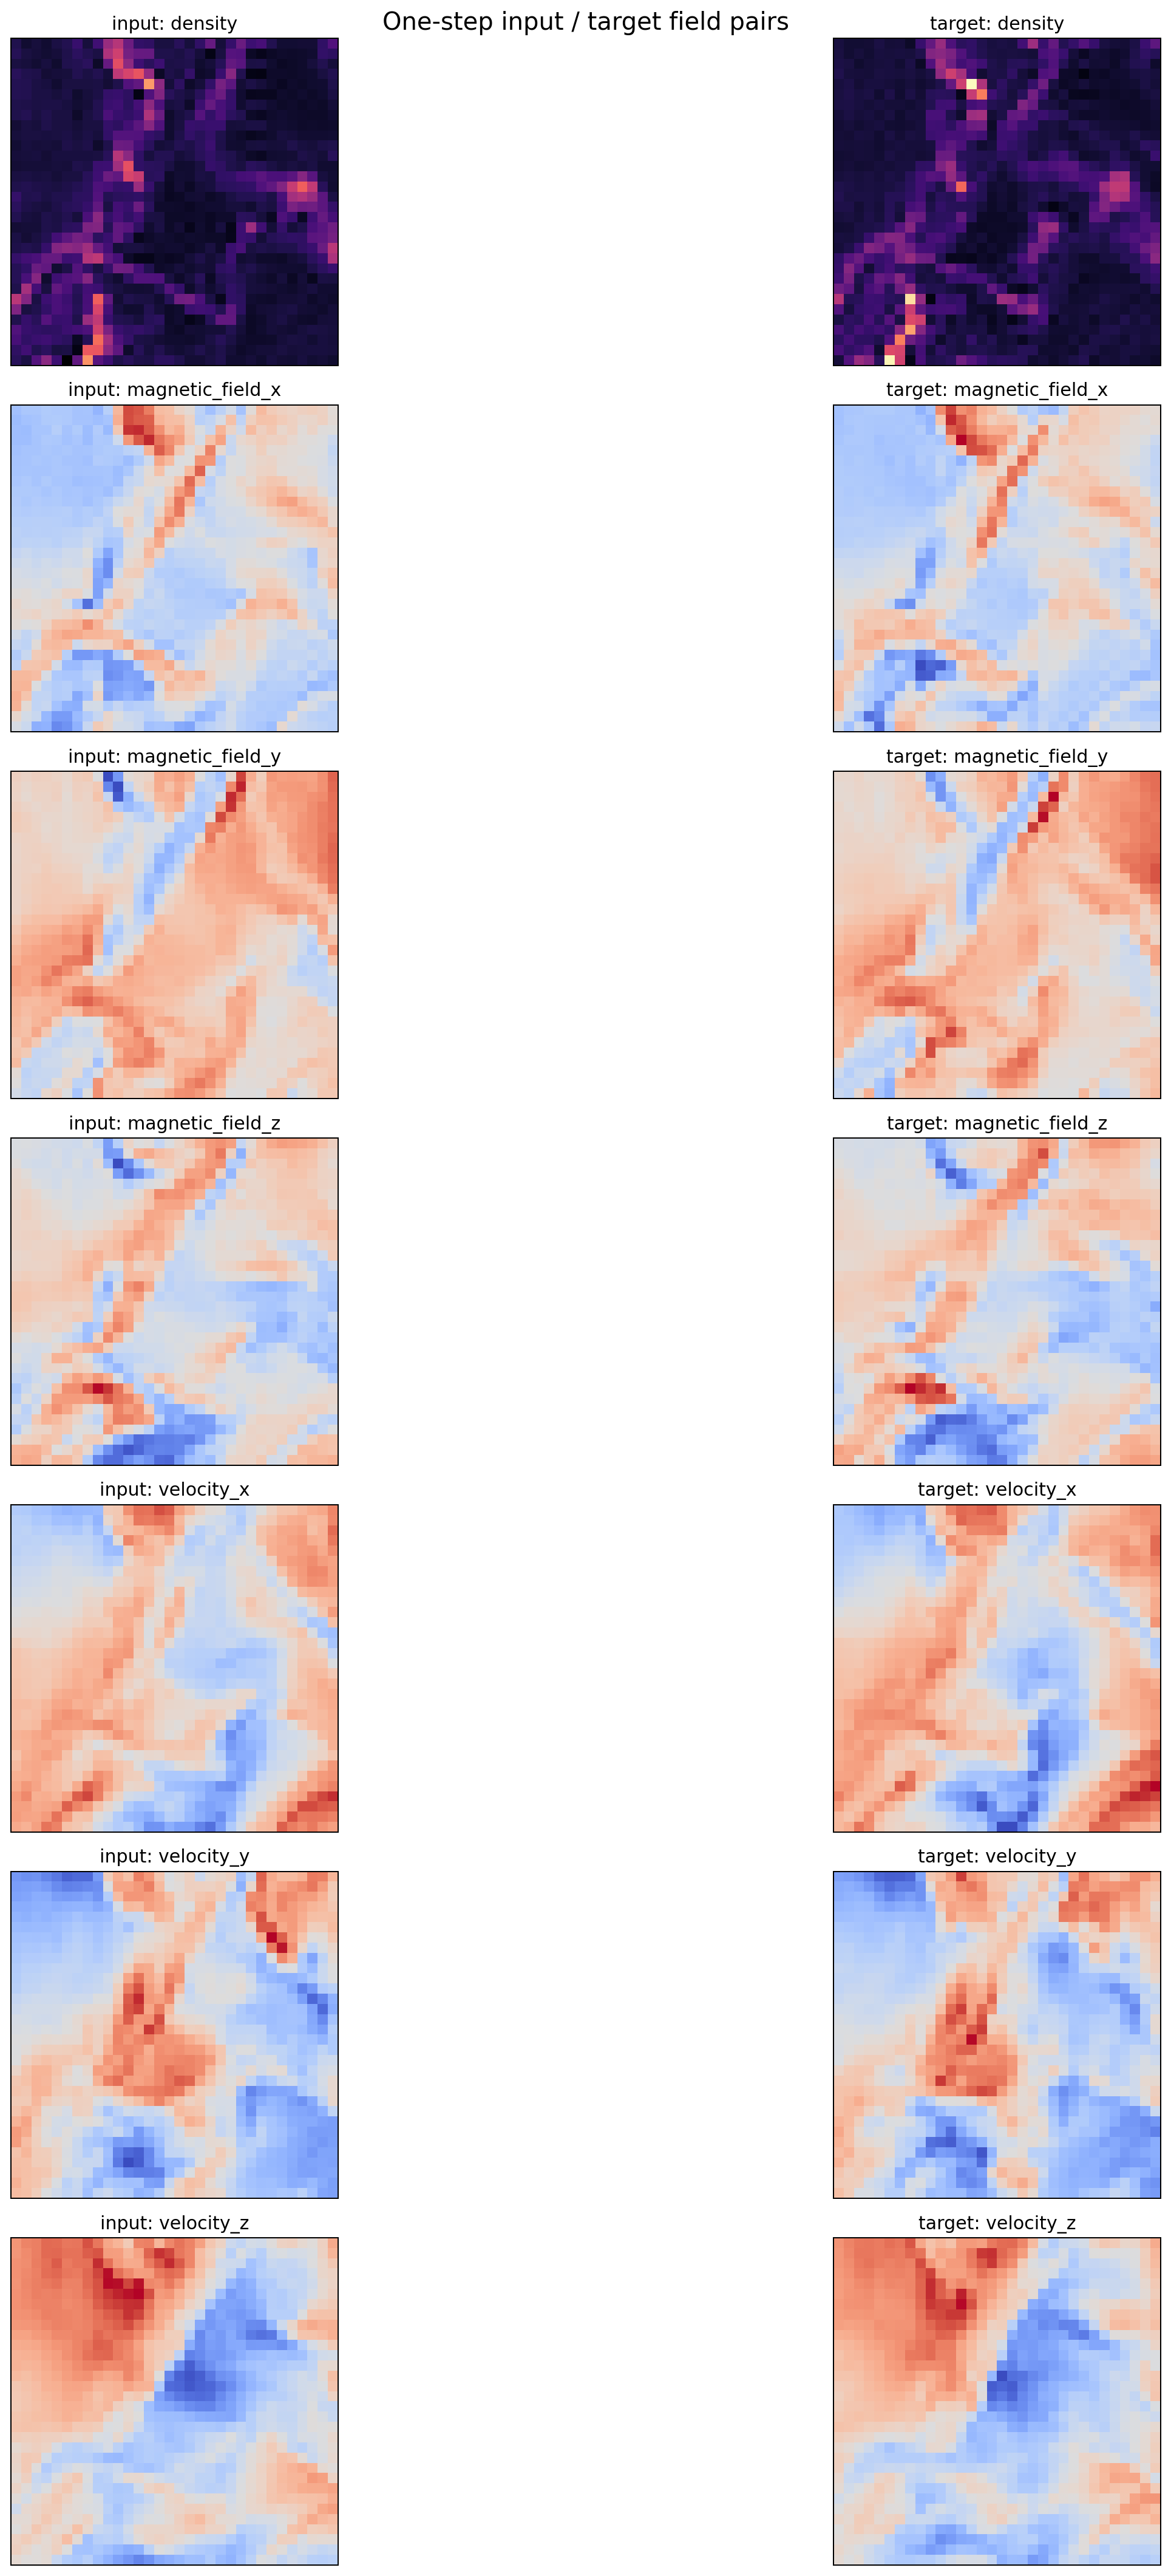

In [7]:
# [Cell 6 REPLACEMENT] — High-resolution one-step input/output visualization
# -----------------------------------------------------------------------------
# WHY THIS CELL CHANGES
# ---------------------
# The earlier visualizations were useful but too coarse for diagnosing MHD
# structure. This replacement:
#
#   1. uses larger figures / higher DPI
#   2. uses field-wise shared normalization between input and target
#   3. supports optional log-density
#   4. is intended to make fine-scale differences easier to see
# -----------------------------------------------------------------------------

def plot_named_field_pair(
    x: torch.Tensor,
    y: torch.Tensor,
    z_slice: Optional[int] = None,
    use_log_for_density: bool = False,
    figsize: Tuple[int, int] = (20, 24),
):
    x = x.detach().cpu()
    y = y.detach().cpu()

    _, D, H, W = x.shape
    z_slice = D // 2 if z_slice is None else z_slice

    fig, axs = plt.subplots(len(FIELD_NAMES), 2, figsize=figsize)

    for i, name in enumerate(FIELD_NAMES):
        xin = x[i, z_slice].clone()
        yout = y[i, z_slice].clone()

        if use_log_for_density and name == "density":
            xin = torch.log(torch.clamp(xin, min=1e-12))
            yout = torch.log(torch.clamp(yout, min=1e-12))

        cmap = "magma" if name == "density" else "coolwarm"

        vmin = float(torch.min(torch.stack([xin.min(), yout.min()])))
        vmax = float(torch.max(torch.stack([xin.max(), yout.max()])))

        axs[i, 0].imshow(xin.numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
        axs[i, 0].set_title(f"input: {name}")
        axs[i, 0].set_xticks([])
        axs[i, 0].set_yticks([])

        axs[i, 1].imshow(yout.numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
        axs[i, 1].set_title(f"target: {name}")
        axs[i, 1].set_xticks([])
        axs[i, 1].set_yticks([])

    fig.suptitle("One-step input / target field pairs", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_named_field_pair(sample0["x"], sample0["y"], use_log_for_density=False)

[CACHE HIT] quartet <- quartet_density_9a9252b69747a6e0_frames4.npz


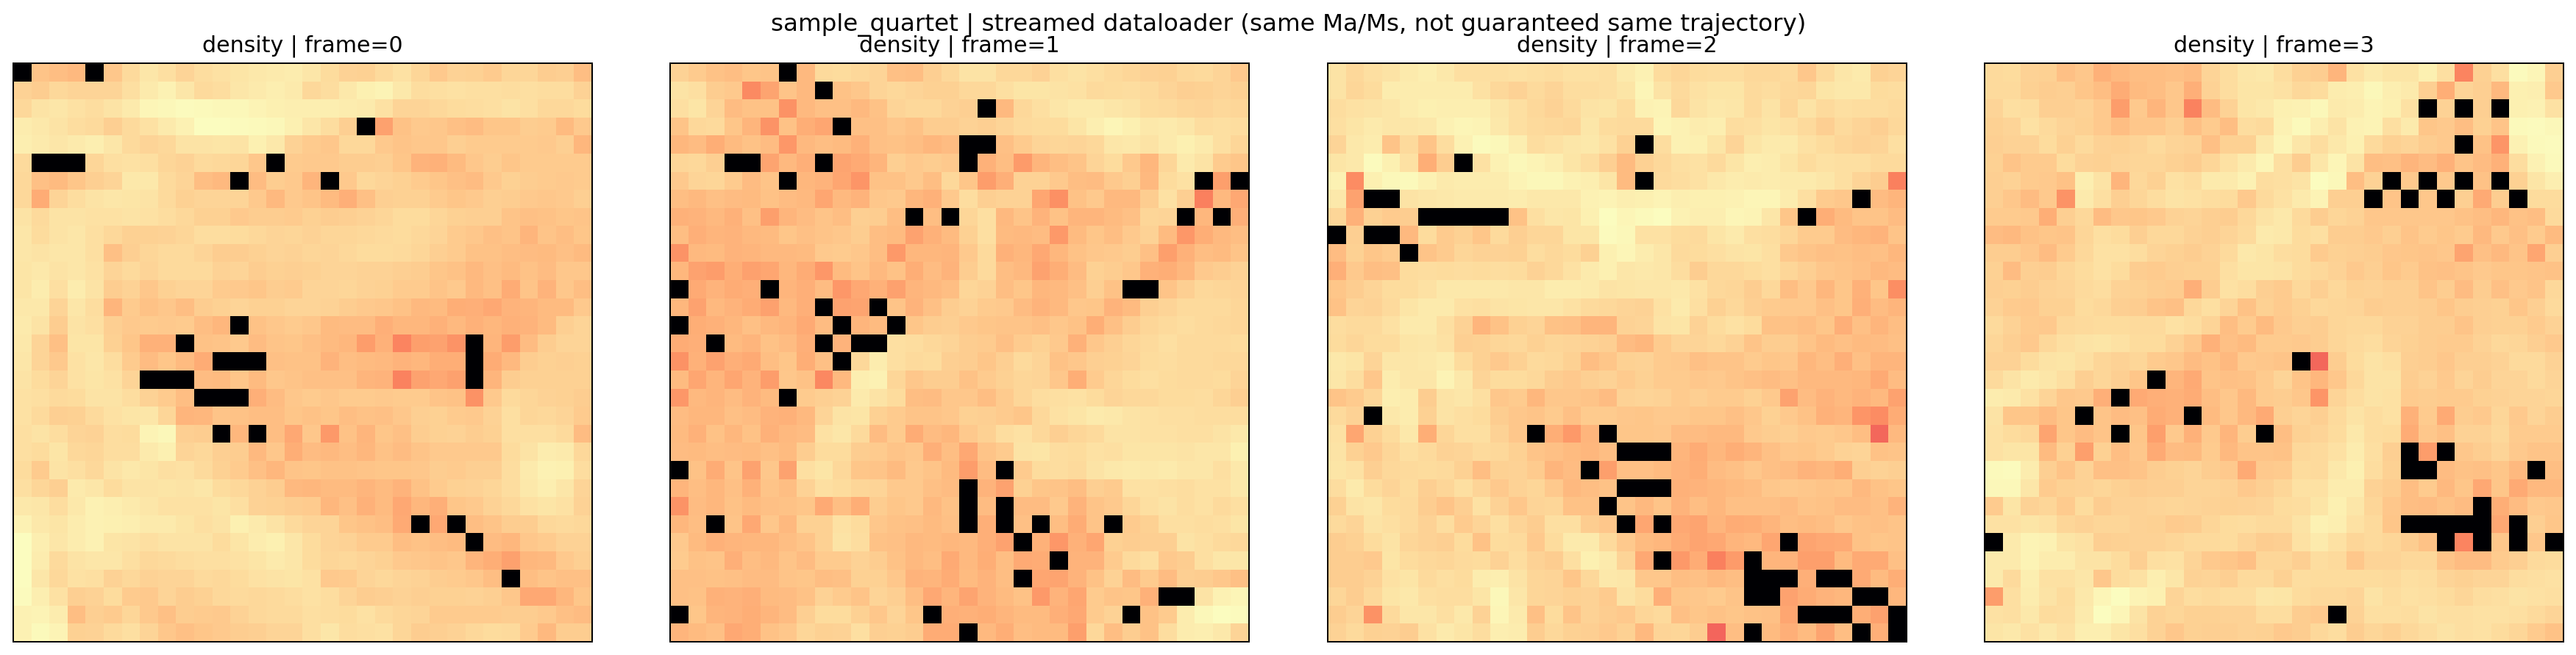

[CACHE HIT] quartet <- quartet_magnetic_magnitude_9a9252b69747a6e0_frames4.npz


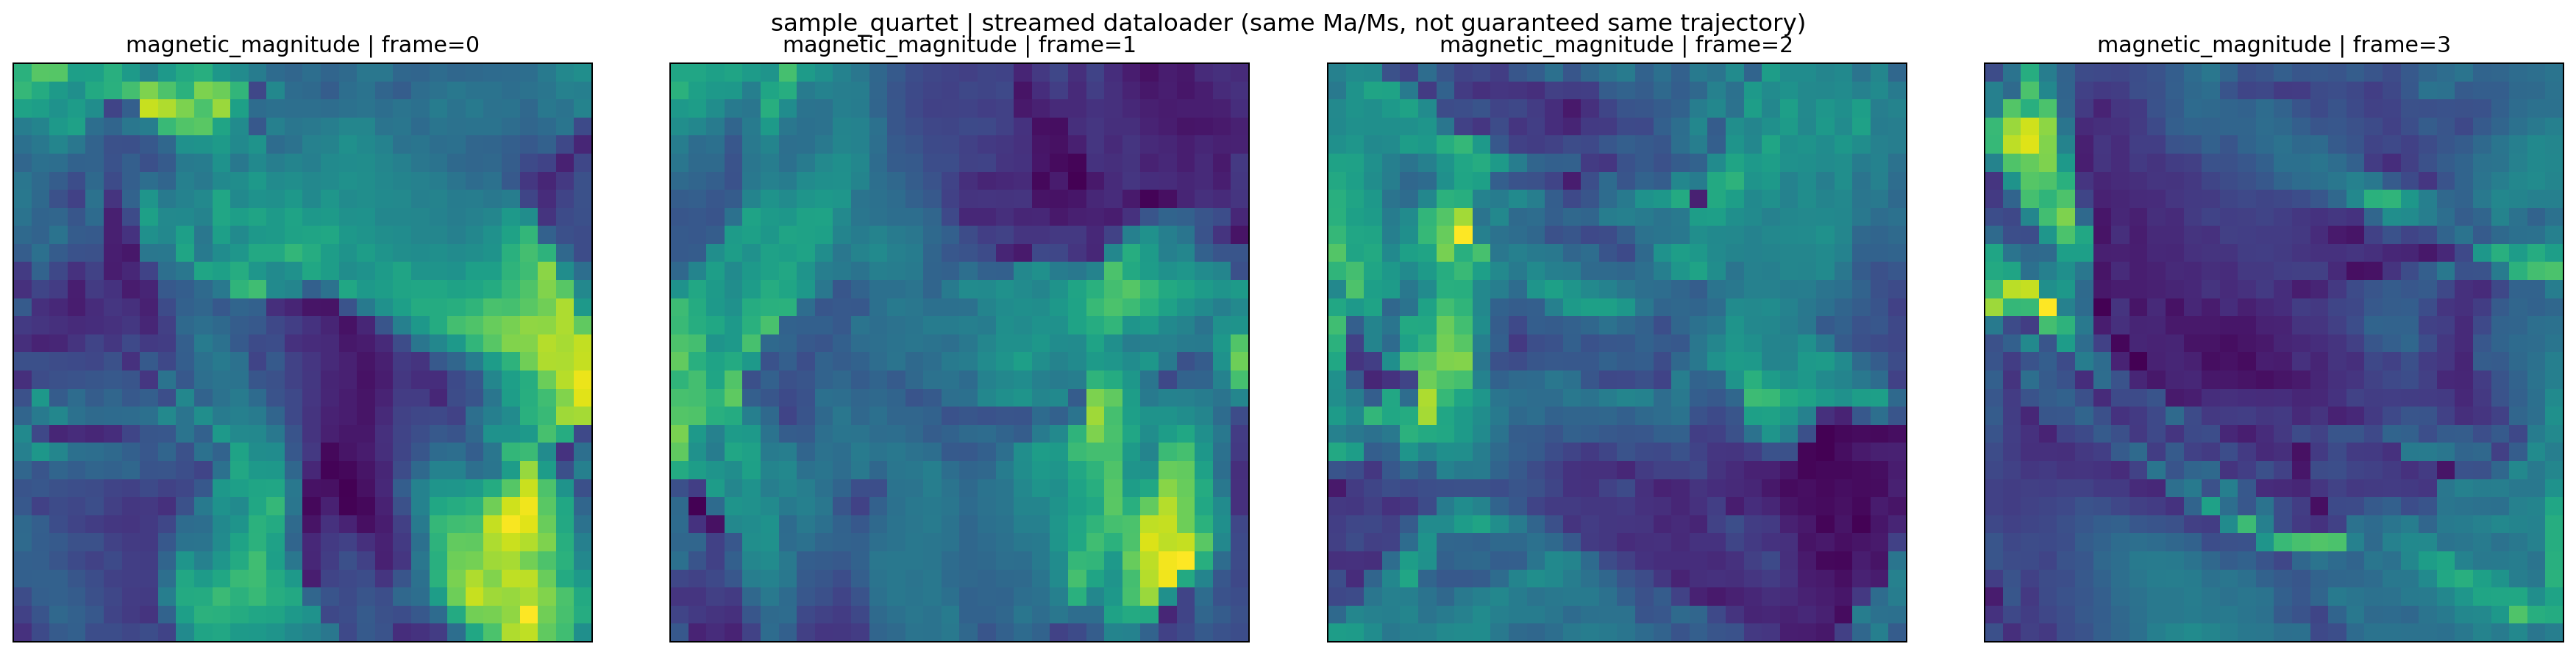

[CACHE HIT] quartet <- quartet_velocity_magnitude_9a9252b69747a6e0_frames4.npz


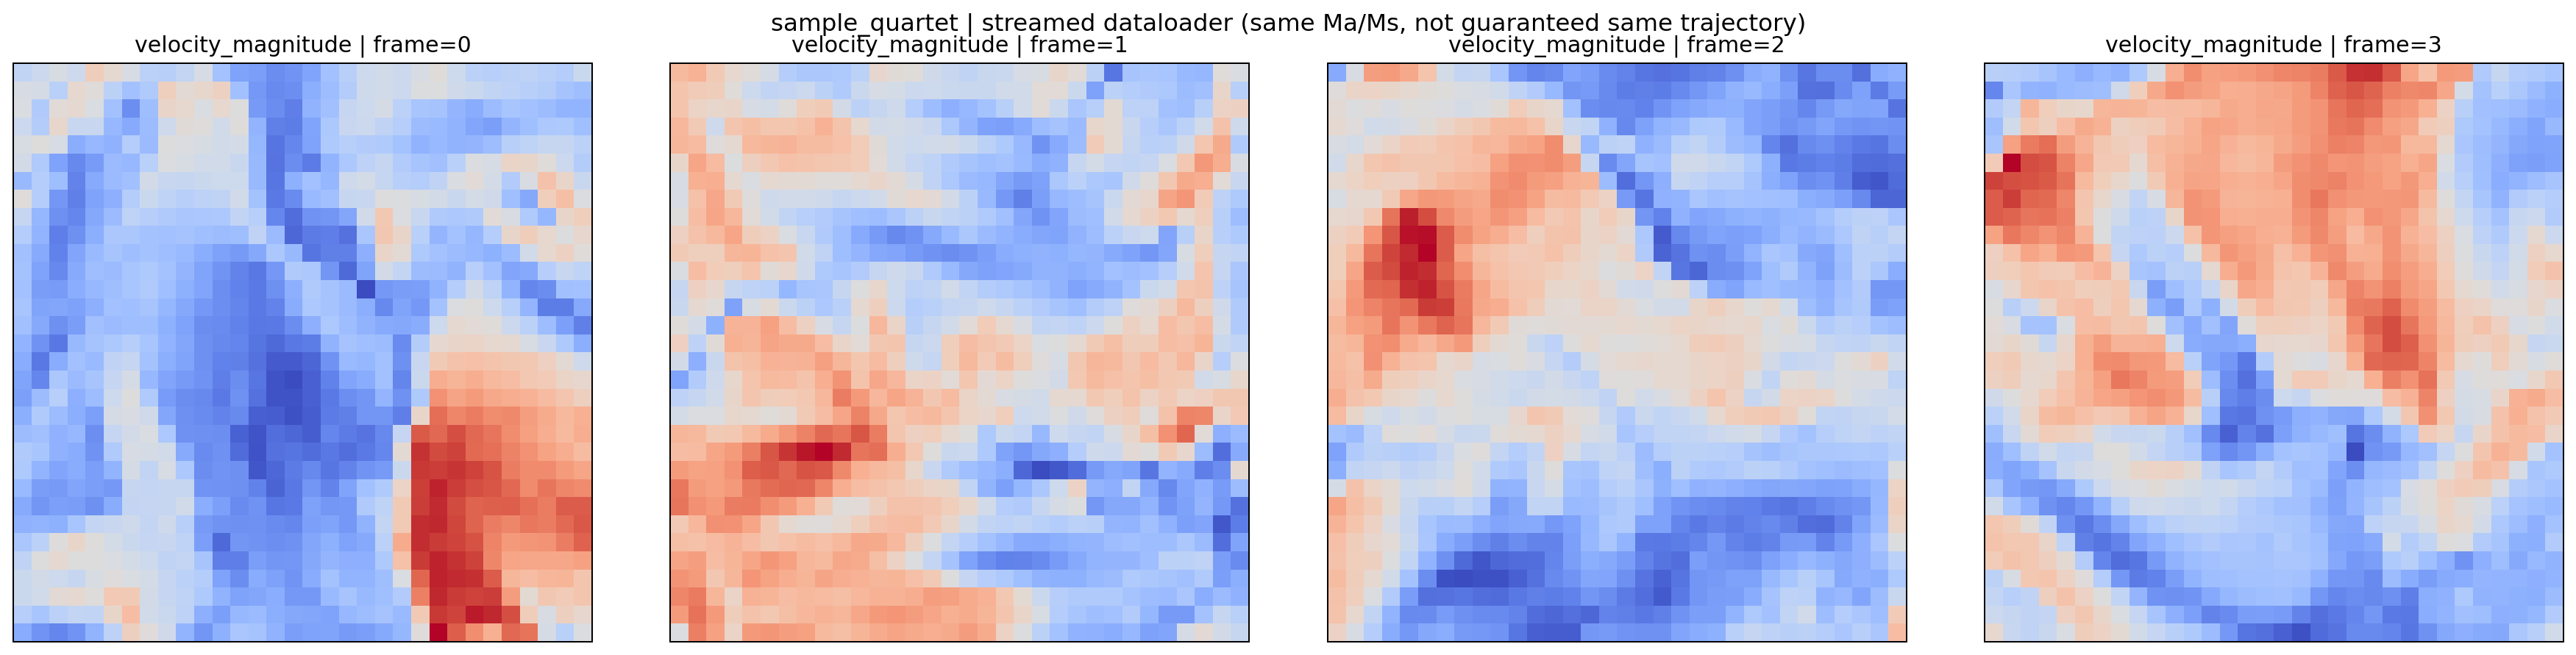

In [8]:
# [Cell 7] — Source-style snapshots with persistent cache
# -----------------------------------------------------------------------------
# POLICY
# 1. If local raw HDF5 exists, use true trajectory directly.
# 2. Else if streamed quartet cache exists, load it and DO NOT stream.
# 3. Else stream once, build quartet, save to disk, and reuse forever after.

import numpy as np

def load_full_field_trajectory_from_h5(
    path: Path,
    field_name: str,
    traj_idx: int = 0,
) -> np.ndarray:
    with h5py.File(path, "r") as f:
        if field_name == "density":
            arr = f["t0_fields"]["density"][traj_idx]
        elif field_name in ["magnetic_field_x", "magnetic_field_y", "magnetic_field_z"]:
            vec = f["t1_fields"]["magnetic_field"][traj_idx]
            comp_idx = {"magnetic_field_x": 0, "magnetic_field_y": 1, "magnetic_field_z": 2}[field_name]
            if vec.ndim == 5 and vec.shape[-1] == 3:
                arr = vec[..., comp_idx]
            else:
                arr = vec[:, comp_idx]
        elif field_name in ["velocity_x", "velocity_y", "velocity_z"]:
            vec = f["t1_fields"]["velocity"][traj_idx]
            comp_idx = {"velocity_x": 0, "velocity_y": 1, "velocity_z": 2}[field_name]
            if vec.ndim == 5 and vec.shape[-1] == 3:
                arr = vec[..., comp_idx]
            else:
                arr = vec[:, comp_idx]
        elif field_name == "magnetic_magnitude":
            vec = f["t1_fields"]["magnetic_field"][traj_idx]
            if vec.ndim == 5 and vec.shape[-1] == 3:
                arr = np.sqrt((vec ** 2).sum(axis=-1) + 1e-12)
            else:
                arr = np.sqrt((vec ** 2).sum(axis=1) + 1e-12)
        elif field_name == "velocity_magnitude":
            vec = f["t1_fields"]["velocity"][traj_idx]
            if vec.ndim == 5 and vec.shape[-1] == 3:
                arr = np.sqrt((vec ** 2).sum(axis=-1) + 1e-12)
            else:
                arr = np.sqrt((vec ** 2).sum(axis=1) + 1e-12)
        else:
            raise ValueError(f"Unknown field_name: {field_name}")
    return arr

def gather_matching_samples_from_loader(
    loader,
    target_constants: Tuple[float, float],
    max_samples: int = 4,
):
    out = []
    target_Ma, target_Ms = target_constants

    for raw_batch in loader:
        batch = canonicalize_mhd_batch(raw_batch)
        B = batch["x"].shape[0]
        for bi in range(B):
            s = extract_single_sample_from_batch(batch, sample_idx=bi, apply_crop=True)
            if (
                abs(s["Ma"] - target_Ma) < 1e-12 and
                abs(s["Ms"] - target_Ms) < 1e-12
            ):
                out.append(s)
                if len(out) >= max_samples:
                    return out
    return out

def build_streamed_sample_quartet(
    loader,
    field_name: str,
    anchor_sample: dict,
    max_frames: int = 4,
) -> np.ndarray:
    matched = gather_matching_samples_from_loader(
        loader,
        target_constants=(anchor_sample["Ma"], anchor_sample["Ms"]),
        max_samples=max_frames,
    )

    if len(matched) == 0:
        matched = [anchor_sample]

    idx = FIELD_TO_INDEX[field_name] if field_name in FIELD_TO_INDEX else None
    frames = []

    for s in matched:
        if field_name == "magnetic_magnitude":
            frames.append(magnetic_magnitude(s["x"]).numpy())
        elif field_name == "velocity_magnitude":
            frames.append(velocity_magnitude(s["x"]).numpy())
        else:
            frames.append(s["x"][idx].numpy())

    while len(frames) < max_frames:
        frames.append(frames[-1])

    return np.stack(frames, axis=0)

def get_proxy_or_true_trajectory(
    field_name: str,
    anchor_sample: dict,
    traj_idx: int = 0,
    max_frames: int = 4,
):
    if len(RAW_FILES) > 0:
        traj = load_full_field_trajectory_from_h5(
            RAW_FILES[-1],
            field_name=field_name,
            traj_idx=traj_idx,
        )
        source = f"true_trajectory | local_hdf5: {RAW_FILES[-1].name}"
        return traj, source

    cpath = quartet_cache_path(anchor_sample, field_name, max_frames=max_frames)
    if cpath.exists():
        cached = load_npz_quartet(cpath)
        print(f"[CACHE HIT] quartet <- {cpath.name}")
        return cached["traj"], cached["meta"].get("source", "cached_streamed_quartet")

    print(f"[CACHE MISS] building streamed quartet for field={field_name}")
    traj = build_streamed_sample_quartet(
        train_loader,
        field_name=field_name,
        anchor_sample=anchor_sample,
        max_frames=max_frames,
    )
    source = "sample_quartet | streamed dataloader (same Ma/Ms, not guaranteed same trajectory)"
    save_npz_quartet(
        cpath,
        traj,
        meta={
            "field_name": field_name,
            "Ma": anchor_sample["Ma"],
            "Ms": anchor_sample["Ms"],
            "max_frames": max_frames,
            "source": source,
        },
    )
    print(f"[CACHE SAVED] quartet -> {cpath}")
    return traj, source

def plot_field_trajectory_snapshots(
    field_name: str = "density",
    traj_idx: int = 0,
    z_slice: int = 16,
    log_plot: bool = False,
    cmap: str = "magma",
    max_frames: int = 4,
    return_traj: bool = False,
):
    traj, source = get_proxy_or_true_trajectory(
        field_name=field_name,
        anchor_sample=sample0,
        traj_idx=traj_idx,
        max_frames=max_frames,
    )

    T = traj.shape[0]
    frames = [0, max(0, T // 3), max(0, (2 * T) // 3), T - 1]

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    for i, t in enumerate(frames):
        img = traj[t, z_slice]
        if log_plot:
            img = np.log(np.clip(img, 1e-12, None))
        axs[i].imshow(img, cmap=cmap)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_title(f"{field_name} | frame={t}")

    fig.suptitle(source, fontsize=13)
    plt.tight_layout()
    plt.show()

    if return_traj:
        return traj, source

plot_field_trajectory_snapshots(field_name="density", z_slice=16, log_plot=True, cmap="magma")
plot_field_trajectory_snapshots(field_name="magnetic_magnitude", z_slice=16, log_plot=False, cmap="viridis")
plot_field_trajectory_snapshots(field_name="velocity_magnitude", z_slice=16, log_plot=False, cmap="coolwarm")

[CACHE HIT] quartet <- quartet_density_9a9252b69747a6e0_frames4.npz
[CACHE HIT] quartet <- quartet_magnetic_magnitude_9a9252b69747a6e0_frames4.npz
[CACHE HIT] quartet <- quartet_velocity_magnitude_9a9252b69747a6e0_frames4.npz


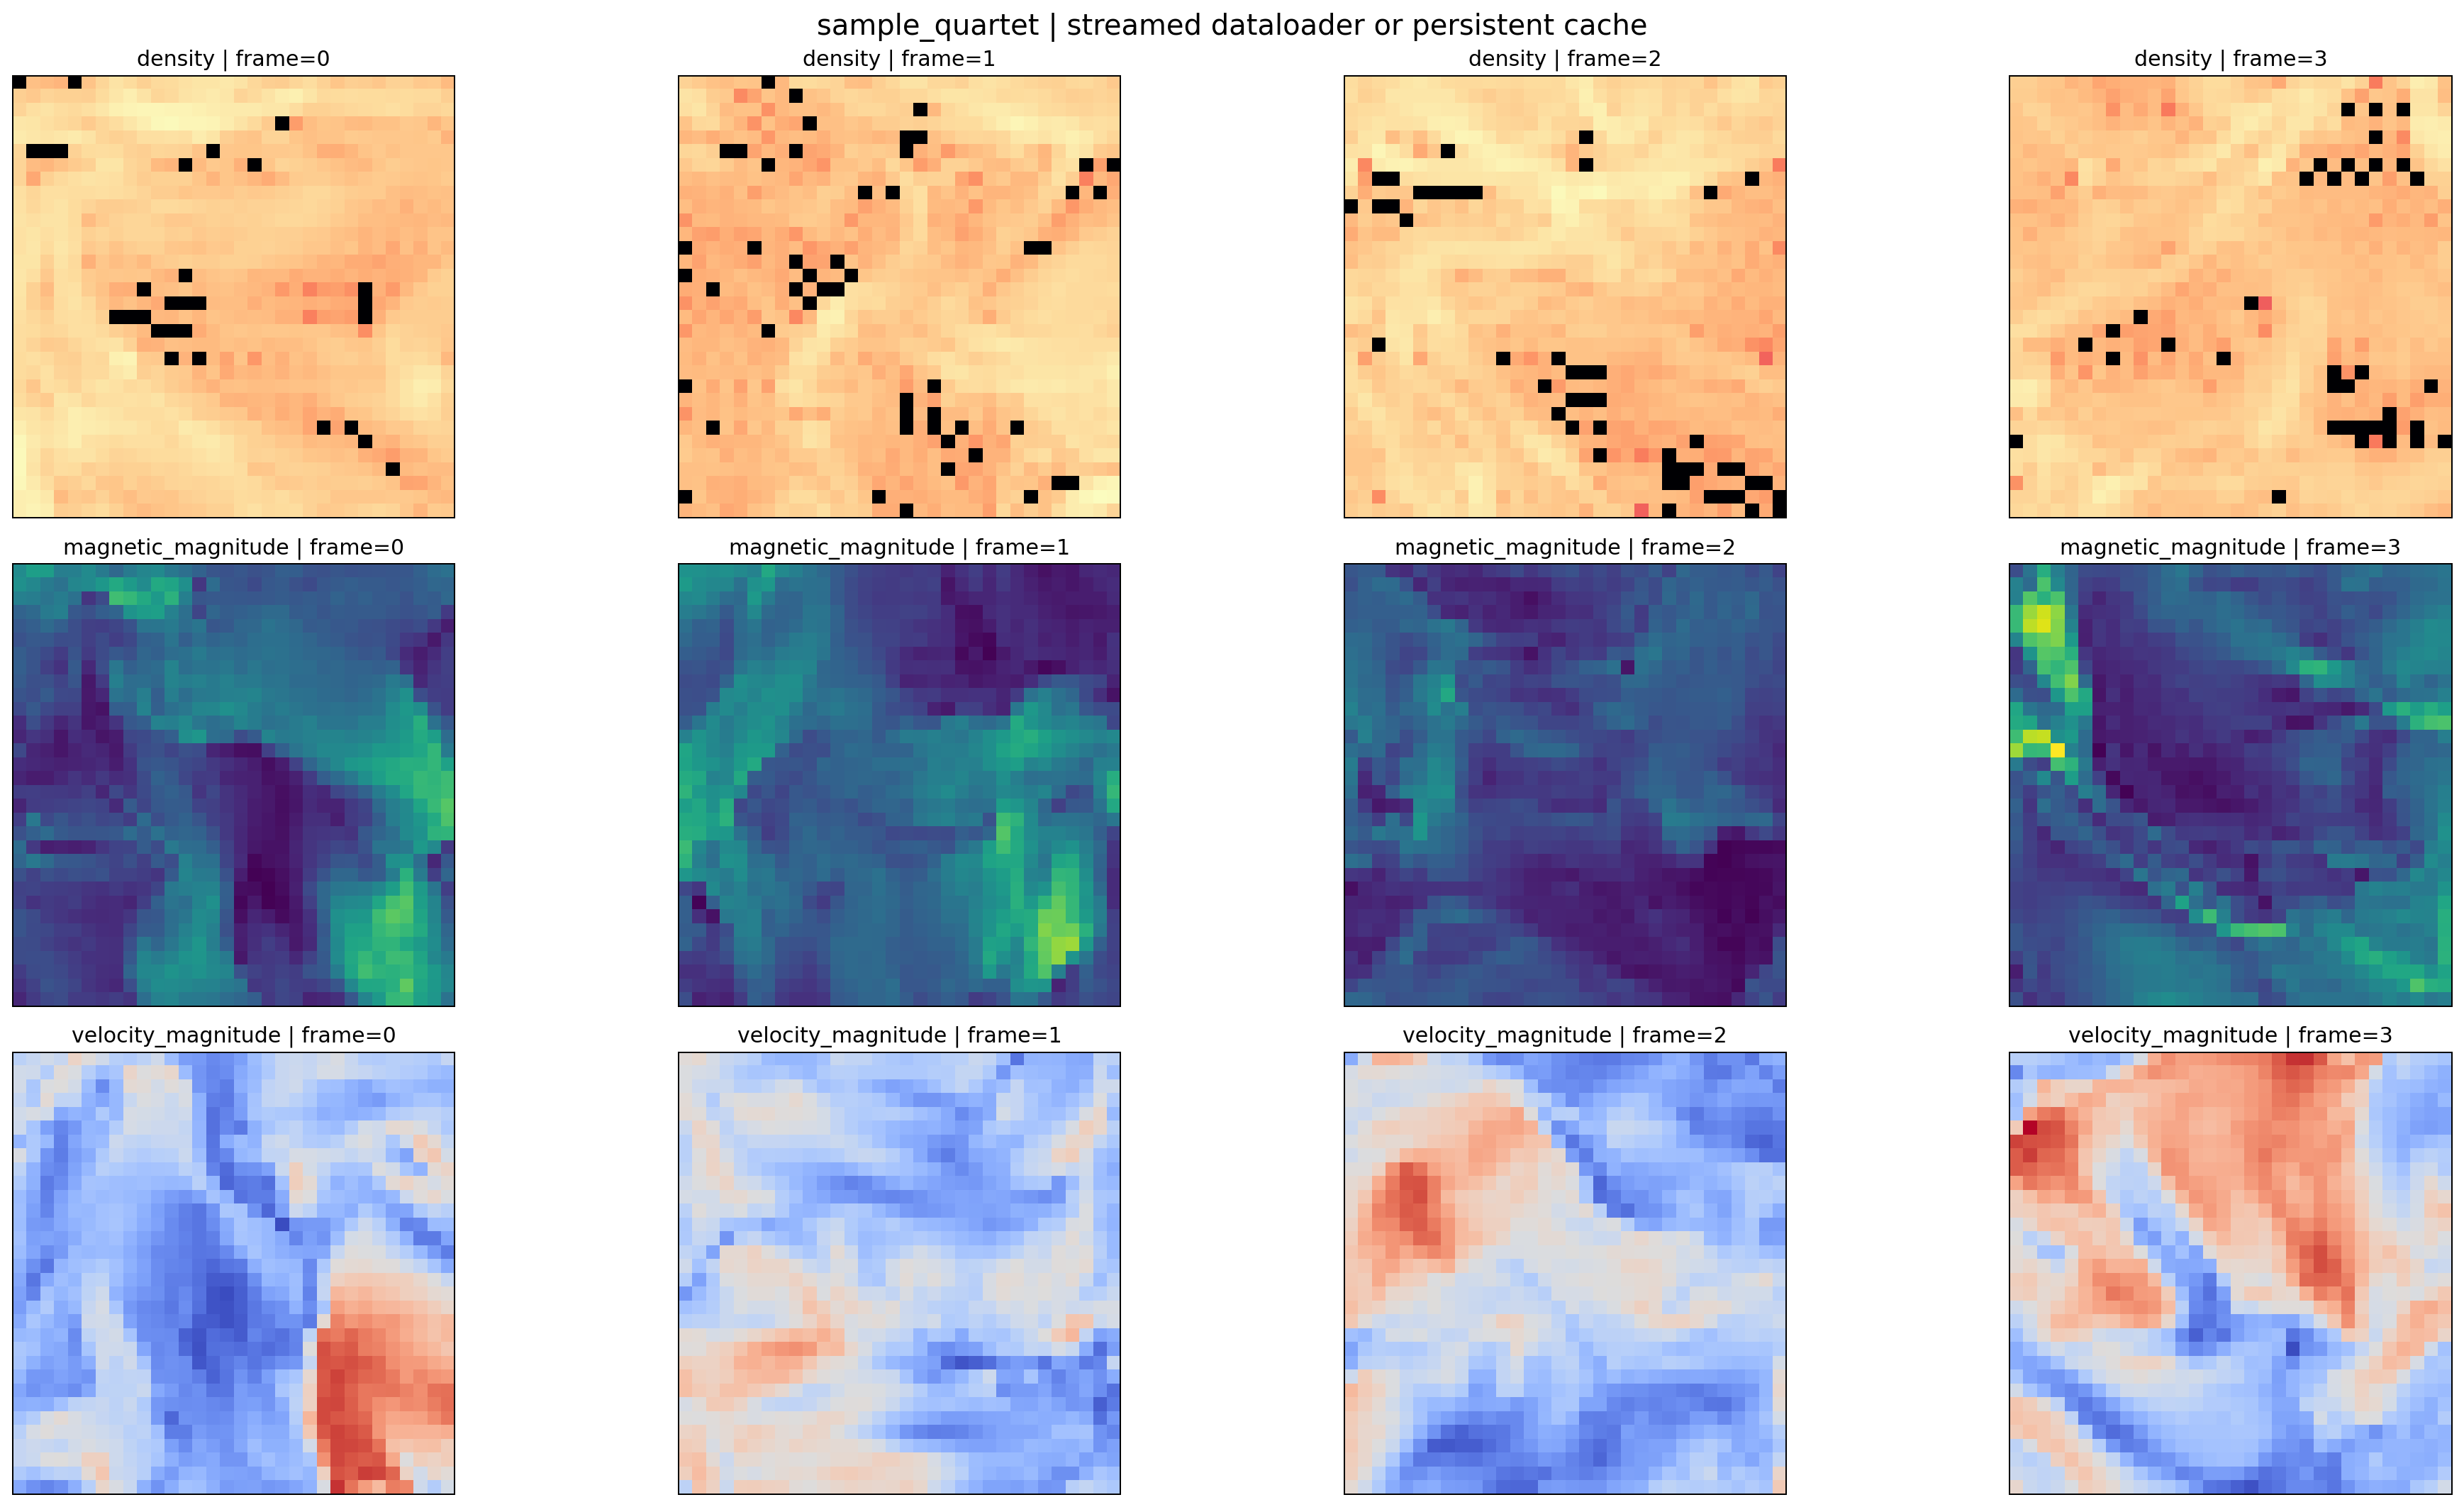

In [9]:
# [Cell 8 REPLACEMENT] — Higher-level summary visualization for density,
# magnetic structure, and velocity structure
# -----------------------------------------------------------------------------
# WHY THIS CELL CHANGES
# ---------------------
# The old summary grid was good as a quick look, but this version makes the
# system-level evolution more interpretable by:
#
#   1. using larger / clearer panels
#   2. keeping field-specific color conventions
#   3. emphasizing density, |B|, and |v| as the three most informative summary
#      quantities for this reduced MHD notebook
# -----------------------------------------------------------------------------

def plot_system_summary_grid(
    traj_idx: int = 0,
    z_slice: int = 16,
    times: Optional[List[int]] = None,
    figsize: Tuple[int, int] = (22, 12),
):
    fields = ["density", "magnetic_magnitude", "velocity_magnitude"]

    if len(RAW_FILES) > 0:
        data = {f: load_full_field_trajectory_from_h5(RAW_FILES[-1], f, traj_idx=traj_idx) for f in fields}
        source = f"true_trajectory | local_hdf5: {RAW_FILES[-1].name}"
    else:
        data = {}
        for f in fields:
            traj, _ = get_proxy_or_true_trajectory(
                field_name=f,
                anchor_sample=sample0,
                traj_idx=traj_idx,
                max_frames=4,
            )
            data[f] = traj
        source = "sample_quartet | streamed dataloader or persistent cache"

    T = next(iter(data.values())).shape[0]
    if times is None:
        times = [0, max(0, T // 3), max(0, (2 * T) // 3), T - 1]

    fig, axs = plt.subplots(len(fields), len(times), figsize=figsize)

    for r, field_name in enumerate(fields):
        field_stack = data[field_name]
        imgs = []

        for t in times:
            img = field_stack[t, z_slice]
            if field_name == "density":
                img = np.log(np.clip(img, 1e-12, None))
            imgs.append(img)

        vmin = np.min([im.min() for im in imgs])
        vmax = np.max([im.max() for im in imgs])

        for c, (t, img) in enumerate(zip(times, imgs)):
            if field_name == "density":
                cmap = "magma"
            elif field_name == "magnetic_magnitude":
                cmap = "viridis"
            else:
                cmap = "coolwarm"

            axs[r, c].imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
            axs[r, c].set_xticks([])
            axs[r, c].set_yticks([])
            axs[r, c].set_title(f"{field_name} | frame={t}")

    fig.suptitle(source, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_system_summary_grid(traj_idx=0, z_slice=16)

In [10]:
# [Cell 9] — Build a physically meaningful agent context pack
# -----------------------------------------------------------------------------

def make_mhd_context_pack(sample: Dict[str, Any]) -> Dict[str, Any]:
    x = sample["x"]
    field_stats = describe_named_fields(x)
    data_source_mode = "local_hdf5_or_stream_cache" if len(RAW_FILES) > 0 else "stream_cache_first"

    pack = {
        "task": "3d_mhd64_one_step_forecast",
        "dataset_name": "MHD_64",
        "grid_type": META["grid_type"],
        "spatial_resolution": META["spatial_resolution"],
        "boundary_conditions": META["boundary_condition_types"],
        "fields": FIELD_NAMES,
        "constant_scalars": {
            "Ma": sample["Ma"],
            "Ms": sample["Ms"],
        },
        "input_field_stats": field_stats,
        "time_info": {
            "input_time": sample["input_time"],
            "output_time": sample["output_time"],
            "dt": sample["dt"],
        },
        "notes": {
            "physics_regime": "compressible magnetohydrodynamic turbulence",
            "density_field_present": True,
            "magnetic_vector_present": True,
            "velocity_vector_present": True,
            "periodic_domain": True,
            "data_source_mode": data_source_mode,
        },
    }
    return pack

context_pack = make_mhd_context_pack(sample0)
display(Markdown("## Agent context pack"))
print(json.dumps(context_pack, indent=2))

## Agent context pack

{
  "task": "3d_mhd64_one_step_forecast",
  "dataset_name": "MHD_64",
  "grid_type": "cartesian",
  "spatial_resolution": [
    64,
    64,
    64
  ],
  "boundary_conditions": [
    "PERIODIC"
  ],
  "fields": [
    "density",
    "magnetic_field_x",
    "magnetic_field_y",
    "magnetic_field_z",
    "velocity_x",
    "velocity_y",
    "velocity_z"
  ],
  "constant_scalars": {
    "Ma": 2.0,
    "Ms": 7.0
  },
  "input_field_stats": {
    "density": {
      "mean": 0.8082742691040039,
      "std": 1.0093694925308228,
      "min": -0.9700464606285095,
      "max": 14.192984580993652
    },
    "magnetic_field_x": {
      "mean": 0.10851867496967316,
      "std": 0.20166845619678497,
      "min": -0.790117621421814,
      "max": 1.1033016443252563
    },
    "magnetic_field_y": {
      "mean": -0.02793707698583603,
      "std": 0.22324395179748535,
      "min": -1.3078504800796509,
      "max": 0.8879138231277466
    },
    "magnetic_field_z": {
      "mean": 0.038936492055654526,
    

In [11]:
# [Cell 10] — Lightweight 3D classical forecaster
# -----------------------------------------------------------------------------
# PURPOSE
# Use a practical residual 3D CNN as the classical baseline.
#
# MODEL
# -----
# Input:  [B, 7, D, H, W]
# Output: [B, 7, D, H, W]
#
# Residual forecasting:
#   y_hat = x + f_theta(x)
# -----------------------------------------------------------------------------

class ResBlock3D(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv1 = nn.Conv3d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv3d(channels, channels, kernel_size=3, padding=1)
        self.norm1 = nn.BatchNorm3d(channels)
        self.norm2 = nn.BatchNorm3d(channels)

    def forward(self, x):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.gelu(h)
        h = self.conv2(h)
        h = self.norm2(h)
        return F.gelu(x + h)

class MHDClassicalForecaster3D(nn.Module):
    def __init__(self, in_ch: int = 7, hidden: int = 32, depth: int = 4):
        super().__init__()
        self.in_proj = nn.Conv3d(in_ch, hidden, kernel_size=3, padding=1)
        self.blocks = nn.ModuleList([ResBlock3D(hidden) for _ in range(depth)])
        self.out_proj = nn.Conv3d(hidden, in_ch, kernel_size=3, padding=1)

    def forward(self, x):
        h = self.in_proj(x)
        h = F.gelu(h)
        for blk in self.blocks:
            h = blk(h)
        delta = self.out_proj(h)
        return x + delta

classical_model = MHDClassicalForecaster3D().to(DEVICE)
print(classical_model.__class__.__name__)
print(f"parameters = {sum(p.numel() for p in classical_model.parameters()):,}")

MHDClassicalForecaster3D
parameters = 234,087


In [12]:
# [Cell 11 REPLACEMENT] — Physics-aware helpers, discrete MHD-inspired losses,
# and shared metrics
# -----------------------------------------------------------------------------
# WHY THIS CELL CHANGES
# ---------------------
# The previous loss stack was useful but too weakly tied to the actual reduced
# MHD structure. This refactor makes the classical and hybrid training stacks
# share a more coherent mathematical language:
#
#   1. density transport
#   2. momentum transport proxy
#   3. induction
#   4. divergence-free magnetic field
#   5. structure / gradient preservation
#
# The classical model still remains a classical baseline. However, even its
# training loss now references the discrete timestep and stronger physically
# interpretable quantities.
#
# Important note:
# ---------------
# This notebook still uses a reduced MHD physics objective, not a full
# high-order production MHD solver. The goal is:
#
#   classical baseline
#   versus
#   structured hybrid physics-informed baseline
#
# on the same one-step forecasting task.
# -----------------------------------------------------------------------------

def channelwise_mse(y_hat: torch.Tensor, y: torch.Tensor) -> Dict[str, float]:
    out = {}
    for i, name in enumerate(FIELD_NAMES):
        out[name] = float(F.mse_loss(y_hat[:, i], y[:, i]).item())
    return out

def relative_l2(pred: torch.Tensor, truth: torch.Tensor, eps: float = 1e-12) -> float:
    num = torch.linalg.norm((pred - truth).reshape(-1))
    den = torch.linalg.norm(truth.reshape(-1)) + eps
    return float((num / den).item())

def evaluate_batch_metrics(y_hat: torch.Tensor, y: torch.Tensor) -> Dict[str, Any]:
    mse_by_field = channelwise_mse(y_hat, y)

    rel_by_field = {}
    for i, name in enumerate(FIELD_NAMES):
        rel_by_field[name] = relative_l2(y_hat[:, i], y[:, i])

    bmag_hat = magnetic_magnitude(y_hat)
    bmag_true = magnetic_magnitude(y)
    vmag_hat = velocity_magnitude(y_hat)
    vmag_true = velocity_magnitude(y)

    return {
        "mse_by_field": mse_by_field,
        "rel_l2_by_field": rel_by_field,
        "magnetic_magnitude_rel_l2": relative_l2(bmag_hat, bmag_true),
        "velocity_magnitude_rel_l2": relative_l2(vmag_hat, vmag_true),
        "global_mse": float(F.mse_loss(y_hat, y).item()),
    }

# -----------------------------------------------------------------------------
# Reduced-physics helpers
# -----------------------------------------------------------------------------
def density_structure_mask(x: torch.Tensor, quantile: float = 0.95) -> torch.Tensor:
    """
    Input:
      x: [B, C, D, H, W] or [C, D, H, W]
    Returns:
      boolean mask over density
    """
    if x.ndim == 4:
        density = x[FIELD_TO_INDEX["density"]]
        thresh = torch.quantile(density.reshape(-1), quantile)
        return density >= thresh

    density = x[:, FIELD_TO_INDEX["density"]]
    flat = density.reshape(density.shape[0], -1)
    thresh = torch.quantile(flat, quantile, dim=1, keepdim=True)
    thresh = thresh.view(-1, 1, 1, 1)
    return density >= thresh

def isothermal_cs2_from_constants(constants: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Very lightweight isothermal closure proxy.

    We use Ms to define a reduced pressure scale:
        p ~ c_s^2 * rho
    with
        c_s^2 ~ 1 / Ms^2

    This is not intended as a perfect physical normalization. It is a reduced
    closure that injects the sonic Mach number into the momentum residual in a
    mathematically interpretable way.
    """
    Ms = constants[:, 1]
    cs2 = 1.0 / (Ms**2 + eps)
    return cs2.view(-1, 1, 1, 1)

def primitive_to_momentum(
    rho: torch.Tensor,
    vx: torch.Tensor,
    vy: torch.Tensor,
    vz: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    return rho * vx, rho * vy, rho * vz

def momentum_to_velocity(
    rho: torch.Tensor,
    mx: torch.Tensor,
    my: torch.Tensor,
    mz: torch.Tensor,
    eps: float = 1e-8,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    denom = torch.clamp(rho, min=eps)
    return mx / denom, my / denom, mz / denom

def unpack_primitive_channels_batched(y: torch.Tensor) -> Dict[str, torch.Tensor]:
    return {
        "rho": y[:, FIELD_TO_INDEX["density"]],
        "bx": y[:, FIELD_TO_INDEX["magnetic_field_x"]],
        "by": y[:, FIELD_TO_INDEX["magnetic_field_y"]],
        "bz": y[:, FIELD_TO_INDEX["magnetic_field_z"]],
        "vx": y[:, FIELD_TO_INDEX["velocity_x"]],
        "vy": y[:, FIELD_TO_INDEX["velocity_y"]],
        "vz": y[:, FIELD_TO_INDEX["velocity_z"]],
    }

def momentum_residual_reduced(
    x: torch.Tensor,
    y_hat: torch.Tensor,
    constants: torch.Tensor,
    dt: torch.Tensor,
) -> torch.Tensor:
    """
    Reduced momentum residual for notebook-scale compressible isothermal MHD:
        d(rho v)/dt + div(rho v ⊗ v - B ⊗ B) + grad(p_iso) ~ 0

    with:
        p_iso = c_s^2 * rho
        c_s^2 inferred from Ms

    This is intentionally reduced. The goal is to capture the coupling between
    compressive transport and magnetic stresses better than a pure data loss.
    """
    dt = dt.view(-1, 1, 1, 1)

    xt = unpack_primitive_channels_batched(x)
    yp = unpack_primitive_channels_batched(y_hat)

    rho_t = xt["rho"]
    rho_p = yp["rho"]

    mx_t, my_t, mz_t = primitive_to_momentum(rho_t, xt["vx"], xt["vy"], xt["vz"])
    mx_p, my_p, mz_p = primitive_to_momentum(rho_p, yp["vx"], yp["vy"], yp["vz"])

    dmx_dt = (mx_p - mx_t) / dt
    dmy_dt = (my_p - my_t) / dt
    dmz_dt = (mz_p - mz_t) / dt

    # advective + magnetic stress divergence
    div_x = divergence_3d(
        mx_p * yp["vx"] - yp["bx"] * yp["bx"],
        mx_p * yp["vy"] - yp["bx"] * yp["by"],
        mx_p * yp["vz"] - yp["bx"] * yp["bz"],
    )
    div_y = divergence_3d(
        my_p * yp["vx"] - yp["by"] * yp["bx"],
        my_p * yp["vy"] - yp["by"] * yp["by"],
        my_p * yp["vz"] - yp["by"] * yp["bz"],
    )
    div_z = divergence_3d(
        mz_p * yp["vx"] - yp["bz"] * yp["bx"],
        mz_p * yp["vy"] - yp["bz"] * yp["by"],
        mz_p * yp["vz"] - yp["bz"] * yp["bz"],
    )

    cs2 = isothermal_cs2_from_constants(constants)
    p_iso = cs2 * rho_p

    gradp_x = spectral_derivative_3d(p_iso, axis=0)
    gradp_y = spectral_derivative_3d(p_iso, axis=1)
    gradp_z = spectral_derivative_3d(p_iso, axis=2)

    rx = dmx_dt + div_x + gradp_x
    ry = dmy_dt + div_y + gradp_y
    rz = dmz_dt + div_z + gradp_z

    return (torch.mean(rx**2) + torch.mean(ry**2) + torch.mean(rz**2)) / 3.0

def continuity_residual_discrete(
    x: torch.Tensor,
    y_hat: torch.Tensor,
    dt: torch.Tensor,
) -> torch.Tensor:
    dt = dt.view(-1, 1, 1, 1)

    xt = unpack_primitive_channels_batched(x)
    yp = unpack_primitive_channels_batched(y_hat)

    rho_t = xt["rho"]
    rho_p = yp["rho"]

    drho_dt = (rho_p - rho_t) / dt
    flux_x = rho_p * yp["vx"]
    flux_y = rho_p * yp["vy"]
    flux_z = rho_p * yp["vz"]

    resid = drho_dt + divergence_3d(flux_x, flux_y, flux_z)
    return torch.mean(resid**2)

# -----------------------------------------------------------------------------
# Classical loss terms
# -----------------------------------------------------------------------------
LOSS_WEIGHTS = {
    "global_mse": 1.0,
    "density_mse": 1.00,
    "structure_density": 1.25,
    "density_gradient": 0.40,
    "magnetic_magnitude": 0.45,
    "velocity_magnitude": 0.45,
    "divergence_b": 0.20,
    "continuity": 0.30,
    "momentum_reduced": 0.08,
}

def compute_loss_terms(
    x: torch.Tensor,
    y_hat: torch.Tensor,
    y: torch.Tensor,
    constants: torch.Tensor,
    dt: torch.Tensor,
    dense_quantile: float = 0.95,
) -> Dict[str, torch.Tensor]:
    density_idx = FIELD_TO_INDEX["density"]

    global_mse = F.mse_loss(y_hat, y)

    density_hat = y_hat[:, density_idx]
    density_true = y[:, density_idx]
    density_mse = F.mse_loss(density_hat, density_true)

    structure_mask = density_structure_mask(y, quantile=dense_quantile).float()
    structure_density = ((density_hat - density_true) ** 2 * structure_mask).sum() / (structure_mask.sum() + 1e-12)

    grad_hat = gradient_magnitude_3d(density_hat)
    grad_true = gradient_magnitude_3d(density_true)
    density_gradient = F.l1_loss(grad_hat, grad_true)

    bmag_hat = magnetic_magnitude(y_hat)
    bmag_true = magnetic_magnitude(y)
    magnetic_magnitude_term = F.mse_loss(bmag_hat, bmag_true)

    vmag_hat = velocity_magnitude(y_hat)
    vmag_true = velocity_magnitude(y)
    velocity_magnitude_term = F.mse_loss(vmag_hat, vmag_true)

    bx = y_hat[:, FIELD_TO_INDEX["magnetic_field_x"]]
    by = y_hat[:, FIELD_TO_INDEX["magnetic_field_y"]]
    bz = y_hat[:, FIELD_TO_INDEX["magnetic_field_z"]]
    div_b = divergence_3d(bx, by, bz)
    divergence_b = torch.mean(div_b ** 2)

    continuity = continuity_residual_discrete(x, y_hat, dt)
    momentum_reduced = momentum_residual_reduced(x, y_hat, constants, dt)

    return {
        "global_mse": global_mse,
        "density_mse": density_mse,
        "structure_density": structure_density,
        "density_gradient": density_gradient,
        "magnetic_magnitude": magnetic_magnitude_term,
        "velocity_magnitude": velocity_magnitude_term,
        "divergence_b": divergence_b,
        "continuity": continuity,
        "momentum_reduced": momentum_reduced,
    }

def compute_loss(
    x: torch.Tensor,
    y_hat: torch.Tensor,
    y: torch.Tensor,
    constants: torch.Tensor,
    dt: torch.Tensor,
) -> torch.Tensor:
    terms = compute_loss_terms(x, y_hat, y, constants, dt)
    total = 0.0
    for k, v in terms.items():
        total = total + LOSS_WEIGHTS[k] * v
    return total

def compute_loss_breakdown(
    x: torch.Tensor,
    y_hat: torch.Tensor,
    y: torch.Tensor,
    constants: torch.Tensor,
    dt: torch.Tensor,
) -> Dict[str, float]:
    terms = compute_loss_terms(x, y_hat, y, constants, dt)
    out = {k: float(v.detach().item()) for k, v in terms.items()}
    out["total"] = float(sum(LOSS_WEIGHTS[k] * terms[k] for k in terms).detach().item())
    return out

print("[PHYSICS-AWARE LOSS / METRICS READY]")

[PHYSICS-AWARE LOSS / METRICS READY]


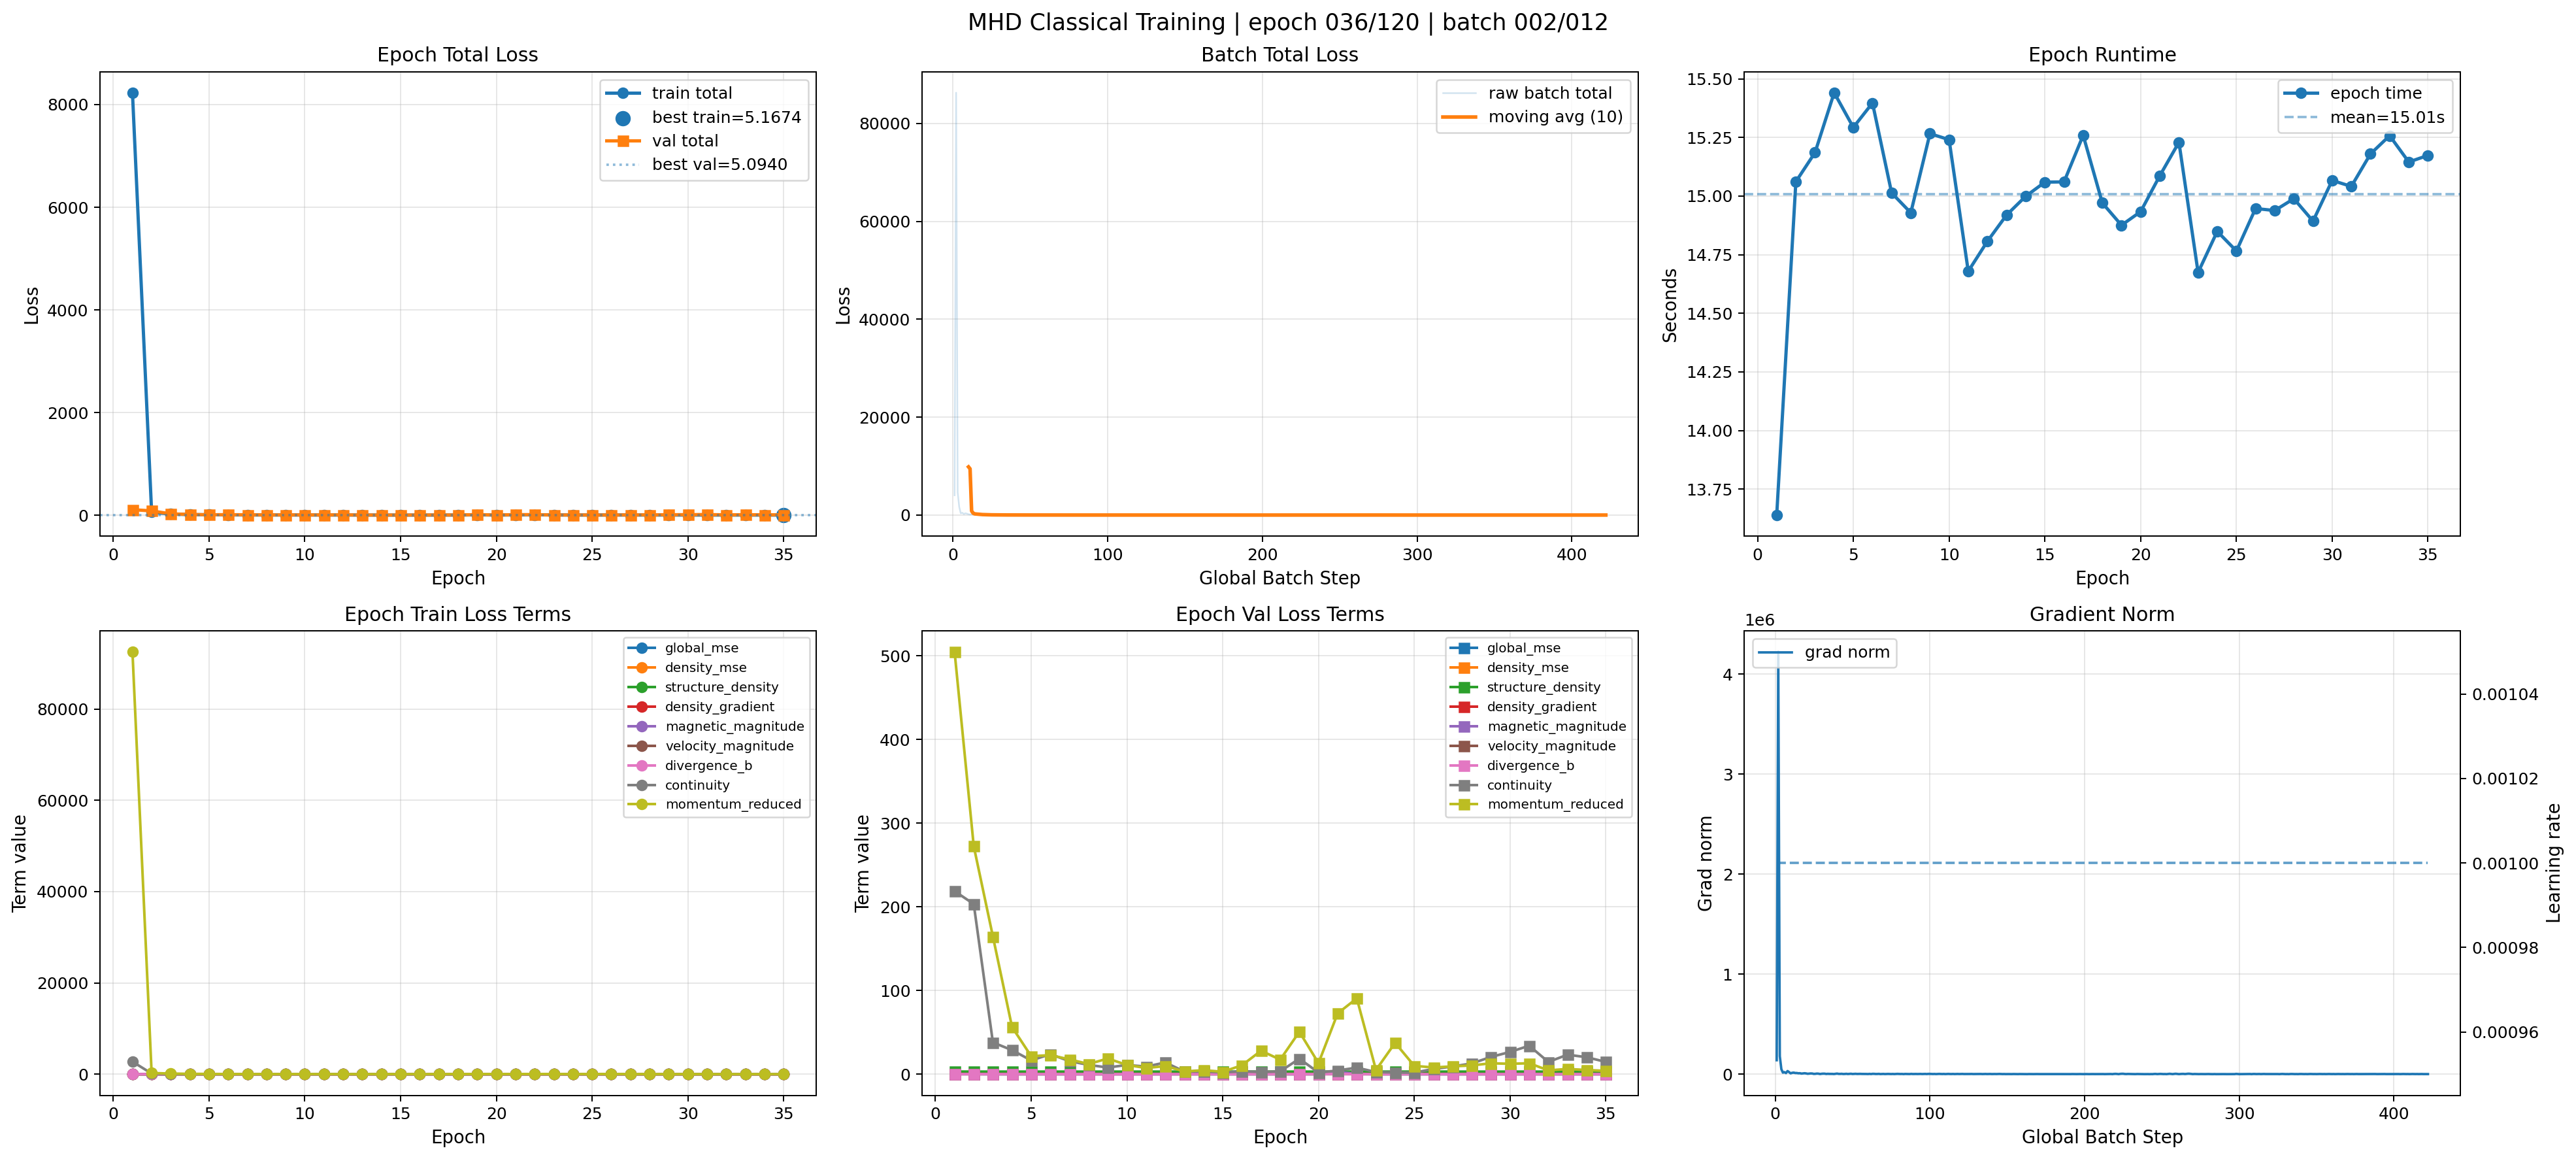

[CLASSICAL LIVE] epoch 036/120 | batch 002/012 | elapsed 1.28s | running total 2.210154


In [ ]:
# [Cell 12 REPLACEMENT] — Classical training loop with robust latest/best
# checkpointing and safe resume bookkeeping
# -----------------------------------------------------------------------------
# WHY THIS CELL CHANGES
# ---------------------
# The previous version could resume training, but the checkpoint bookkeeping was
# still slightly ambiguous:
#
#   - latest checkpoint stored a field called "best_metric", but that value was
#     sometimes the current epoch metric rather than the true best-so-far metric
#   - on resume, that could cause the trainer to forget the actual best metric
#
# This replacement fixes that by storing BOTH:
#
#   current_metric        = metric for the current epoch
#   best_metric_so_far    = best metric seen across all epochs so far
#
# It also stores history in a serialization-friendly way:
#
#   history_state = history.__dict__
#
# and reconstructs the dataclass on load.
# -----------------------------------------------------------------------------

def checkpoint_exists(path: Path) -> bool:
    return path.exists() and path.is_file()

def safe_torch_load(path: Path):
    return torch.load(path, map_location="cpu")

def history_to_state_dict(history_obj) -> Dict[str, Any]:
    return asdict(history_obj)

def history_from_state_dict(state: Optional[Dict[str, Any]]) -> "TrainHistory":
    if state is None:
        return TrainHistory()

    hist = TrainHistory()

    for k, v in state.items():
        if hasattr(hist, k):
            setattr(hist, k, v)

    return hist

def print_checkpoint_summary(path: Path):
    if not checkpoint_exists(path):
        print(f"[NO CHECKPOINT] {path}")
        return

    ckpt = safe_torch_load(path)
    print("=" * 100)
    print(f"[CHECKPOINT SUMMARY] {path}")
    print("=" * 100)
    print("keys:", list(ckpt.keys()))
    print("epoch:", ckpt.get("epoch", None))
    print("global_step:", ckpt.get("global_step", None))
    print("phase_name:", ckpt.get("phase_name", None))
    print("current_metric:", ckpt.get("current_metric", None))
    print("best_metric_so_far:", ckpt.get("best_metric_so_far", None))

    hist_state = ckpt.get("history_state", None)
    if hist_state is not None and isinstance(hist_state, dict):
        ttl = hist_state.get("train_total_loss", [])
        print("history epochs stored:", len(ttl))

def infer_last_global_step_from_history(history_obj) -> int:
    if history_obj is None:
        return 0
    if hasattr(history_obj, "batch_step") and len(history_obj.batch_step) > 0:
        return int(history_obj.batch_step[-1])
    return 0

def infer_last_epoch_from_history(history_obj) -> int:
    if history_obj is None:
        return 0
    if hasattr(history_obj, "train_total_loss"):
        return int(len(history_obj.train_total_loss))
    return 0

@dataclass
class TrainHistory:
    train_total_loss: List[float] = field(default_factory=list)
    val_total_loss: List[float] = field(default_factory=list)
    epoch_time_sec: List[float] = field(default_factory=list)

    batch_total_loss: List[float] = field(default_factory=list)
    batch_step: List[int] = field(default_factory=list)
    learning_rate: List[float] = field(default_factory=list)
    grad_norm: List[float] = field(default_factory=list)

    train_loss_terms: Dict[str, List[float]] = field(default_factory=lambda: {
        "global_mse": [],
        "density_mse": [],
        "structure_density": [],
        "density_gradient": [],
        "magnetic_magnitude": [],
        "velocity_magnitude": [],
        "divergence_b": [],
        "continuity": [],
        "momentum_reduced": [],
    })
    val_loss_terms: Dict[str, List[float]] = field(default_factory=lambda: {
        "global_mse": [],
        "density_mse": [],
        "structure_density": [],
        "density_gradient": [],
        "magnetic_magnitude": [],
        "velocity_magnitude": [],
        "divergence_b": [],
        "continuity": [],
        "momentum_reduced": [],
    })

    batch_loss_terms_last: Dict[str, float] = field(default_factory=dict)

def moving_average(x, window: int = 20):
    if len(x) == 0:
        return np.array([])
    x = np.asarray(x, dtype=float)
    window = max(1, min(window, len(x)))
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

def compute_grad_norm(model: nn.Module) -> float:
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            g = p.grad.detach()
            total += float(torch.sum(g * g).item())
    return math.sqrt(total) if total > 0 else 0.0

@torch.no_grad()
def evaluate_loader_loss_breakdown(
    model: nn.Module,
    loader: DataLoader,
    max_batches: Optional[int] = None,
) -> Dict[str, float]:
    model.eval()

    totals = []
    term_sums = {
        "global_mse": [],
        "density_mse": [],
        "structure_density": [],
        "density_gradient": [],
        "magnetic_magnitude": [],
        "velocity_magnitude": [],
        "divergence_b": [],
        "continuity": [],
        "momentum_reduced": [],
    }

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        x = ensure_float32(batch["x"]).to(DEVICE)
        y = ensure_float32(batch["y"]).to(DEVICE)
        constants = ensure_float32(batch["constants"]).to(DEVICE)
        dt = ensure_float32(batch["dt"]).to(DEVICE)

        y_hat = model(x)
        breakdown = compute_loss_breakdown(x, y_hat, y, constants, dt)

        totals.append(float(breakdown["total"]))
        for k in term_sums:
            term_sums[k].append(float(breakdown[k]))

    out = {}
    out["total"] = float(np.mean(totals)) if len(totals) > 0 else float("nan")
    for k, vals in term_sums.items():
        out[k] = float(np.mean(vals)) if len(vals) > 0 else float("nan")
    return out

def plot_training_history_live(
    history: TrainHistory,
    epoch: int,
    epochs: int,
    current_epoch_batch: int,
    total_batches: int,
    refresh_text: Optional[str] = None,
    batch_ma_window: int = 20,
):
    fig, axs = plt.subplots(2, 3, figsize=(22, 10))

    ax = axs[0, 0]
    if len(history.train_total_loss) > 0:
        x = np.arange(1, len(history.train_total_loss) + 1)
        y = np.asarray(history.train_total_loss, dtype=float)
        ax.plot(x, y, marker="o", linewidth=2, label="train total")
        finite = np.isfinite(y)
        if np.any(finite):
            xs = x[finite]
            ys = y[finite]
            best_idx = int(np.argmin(ys))
            ax.scatter(xs[best_idx], ys[best_idx], s=70, label=f"best train={ys[best_idx]:.4f}")

    if len(history.val_total_loss) > 0:
        x = np.arange(1, len(history.val_total_loss) + 1)
        y = np.asarray(history.val_total_loss, dtype=float)
        ax.plot(x, y, marker="s", linewidth=2, label="val total")
        finite = np.isfinite(y)
        if np.any(finite):
            best_val = float(np.min(y[finite]))
            ax.axhline(best_val, linestyle=":", alpha=0.5, label=f"best val={best_val:.4f}")

    ax.set_title("Epoch Total Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axs[0, 1]
    if len(history.batch_total_loss) > 0:
        ax.plot(history.batch_step, history.batch_total_loss, alpha=0.20, linewidth=1.0, label="raw batch total")
        ma = moving_average(history.batch_total_loss, window=batch_ma_window)
        if len(ma) > 0:
            ma_steps = history.batch_step[len(history.batch_step) - len(ma):]
            ax.plot(ma_steps, ma, linewidth=2.2, label=f"moving avg ({batch_ma_window})")
    ax.set_title("Batch Total Loss")
    ax.set_xlabel("Global Batch Step")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axs[0, 2]
    if len(history.epoch_time_sec) > 0:
        x = np.arange(1, len(history.epoch_time_sec) + 1)
        y = np.asarray(history.epoch_time_sec, dtype=float)
        ax.plot(x, y, marker="o", linewidth=2, label="epoch time")
        ax.axhline(np.mean(y), linestyle="--", alpha=0.5, label=f"mean={np.mean(y):.2f}s")
    ax.set_title("Epoch Runtime")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Seconds")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axs[1, 0]
    for k, vals in history.train_loss_terms.items():
        if len(vals) > 0:
            ax.plot(np.arange(1, len(vals) + 1), vals, marker="o", linewidth=1.6, label=k)
    ax.set_title("Epoch Train Loss Terms")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Term value")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axs[1, 1]
    for k, vals in history.val_loss_terms.items():
        vals_np = np.asarray(vals, dtype=float)
        if np.any(np.isfinite(vals_np)):
            ax.plot(np.arange(1, len(vals) + 1), vals, marker="s", linewidth=1.6, label=k)
    ax.set_title("Epoch Val Loss Terms")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Term value")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axs[1, 2]
    if len(history.grad_norm) > 0:
        ax.plot(history.batch_step, history.grad_norm, linewidth=1.5, label="grad norm")
    ax.set_title("Gradient Norm")
    ax.set_xlabel("Global Batch Step")
    ax.set_ylabel("Grad norm")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

    ax2 = ax.twinx()
    if len(history.learning_rate) > 0:
        ax2.plot(history.batch_step, history.learning_rate, linestyle="--", alpha=0.7, label="lr")
    ax2.set_ylabel("Learning rate")

    fig.suptitle(
        f"MHD Classical Training | epoch {epoch:03d}/{epochs:03d} | "
        f"batch {current_epoch_batch:03d}/{total_batches:03d}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

    if refresh_text is not None:
        print(refresh_text)

def train_model(
    model: nn.Module,
    loader: DataLoader,
    epochs: int,
    lr: float = 1e-3,
    val_loader: Optional[DataLoader] = None,
    validate_every: int = 1,
    val_max_batches: Optional[int] = 3,
    live_plot_every_batches: int = 1,
    batch_ma_window: int = 20,
    checkpoint_best: bool = True,
    best_ckpt_path: Optional[Path] = None,
    latest_ckpt_path: Optional[Path] = None,
    resume: bool = False,
    resume_ckpt_path: Optional[Path] = None,
) -> TrainHistory:
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = TrainHistory()
    global_step = 0
    total_batches = len(loader)

    if best_ckpt_path is None:
        best_ckpt_path = CLASSICAL_BEST_CKPT_PATH
    if latest_ckpt_path is None:
        latest_ckpt_path = CLASSICAL_LATEST_CKPT_PATH
    if resume_ckpt_path is None:
        resume_ckpt_path = latest_ckpt_path

    best_val = float("inf")
    best_train = float("inf")
    best_state = None
    start_epoch = 0

    if resume and checkpoint_exists(resume_ckpt_path):
        ckpt = safe_torch_load(resume_ckpt_path)

        model.load_state_dict(ckpt["model_state_dict"])
        opt.load_state_dict(ckpt["optimizer_state_dict"])

        history = history_from_state_dict(ckpt.get("history_state", None))
        start_epoch = int(ckpt.get("epoch", infer_last_epoch_from_history(history)))
        global_step = int(ckpt.get("global_step", infer_last_global_step_from_history(history)))

        saved_best_metric = ckpt.get("best_metric_so_far", None)
        if saved_best_metric is not None and math.isfinite(float(saved_best_metric)):
            if val_loader is not None:
                best_val = float(saved_best_metric)
            else:
                best_train = float(saved_best_metric)

        best_state = deepcopy(model.state_dict())

        print(f"[RESUME] Loaded classical checkpoint from {resume_ckpt_path}")
        print(f"[RESUME] start_epoch={start_epoch}, global_step={global_step}, best_metric_so_far={saved_best_metric}")
    elif resume:
        print(f"[RESUME REQUESTED BUT NO CHECKPOINT FOUND] {resume_ckpt_path}")
        print("[RESUME] Starting fresh.")

    for epoch in range(start_epoch, epochs):
        t0 = time.time()
        model.train()

        running_total = 0.0
        running_terms = {
            "global_mse": 0.0,
            "density_mse": 0.0,
            "structure_density": 0.0,
            "density_gradient": 0.0,
            "magnetic_magnitude": 0.0,
            "velocity_magnitude": 0.0,
            "divergence_b": 0.0,
            "continuity": 0.0,
            "momentum_reduced": 0.0,
        }
        n_batches = 0

        for bi, batch in enumerate(loader, start=1):
            x = ensure_float32(batch["x"]).to(DEVICE)
            y = ensure_float32(batch["y"]).to(DEVICE)
            constants = ensure_float32(batch["constants"]).to(DEVICE)
            dt = ensure_float32(batch["dt"]).to(DEVICE)

            y_hat = model(x)
            loss = compute_loss(x, y_hat, y, constants, dt)
            breakdown = compute_loss_breakdown(x, y_hat, y, constants, dt)

            opt.zero_grad()
            loss.backward()
            grad_norm_val = compute_grad_norm(model)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            batch_total = float(loss.item())

            running_total += batch_total
            for k in running_terms:
                running_terms[k] += float(breakdown[k])
            n_batches += 1
            global_step += 1

            history.batch_total_loss.append(batch_total)
            history.batch_step.append(global_step)
            history.learning_rate.append(opt.param_groups[0]["lr"])
            history.grad_norm.append(grad_norm_val)
            history.batch_loss_terms_last = {k: float(breakdown[k]) for k in running_terms}

            if bi % live_plot_every_batches == 0 or bi == total_batches:
                elapsed = time.time() - t0
                mean_so_far = running_total / max(1, n_batches)
                msg = (
                    f"[CLASSICAL LIVE] epoch {epoch+1:03d}/{epochs:03d} | "
                    f"batch {bi:03d}/{total_batches:03d} | elapsed {elapsed:.2f}s | "
                    f"running total {mean_so_far:.6f}"
                )
                clear_output(wait=True)
                plot_training_history_live(
                    history=history,
                    epoch=epoch + 1,
                    epochs=epochs,
                    current_epoch_batch=bi,
                    total_batches=total_batches,
                    refresh_text=msg,
                    batch_ma_window=batch_ma_window,
                )

        epoch_total = running_total / max(1, n_batches)
        epoch_time = time.time() - t0

        history.train_total_loss.append(epoch_total)
        history.epoch_time_sec.append(epoch_time)

        for k in running_terms:
            history.train_loss_terms[k].append(running_terms[k] / max(1, n_batches))

        val_breakdown = None
        if val_loader is not None and ((epoch + 1) % validate_every == 0):
            val_breakdown = evaluate_loader_loss_breakdown(
                model=model,
                loader=val_loader,
                max_batches=val_max_batches,
            )
            history.val_total_loss.append(float(val_breakdown["total"]))
            for k in history.val_loss_terms:
                history.val_loss_terms[k].append(float(val_breakdown[k]))
        elif val_loader is not None:
            history.val_total_loss.append(history.val_total_loss[-1] if len(history.val_total_loss) > 0 else float("nan"))
            for k in history.val_loss_terms:
                prev = history.val_loss_terms[k][-1] if len(history.val_loss_terms[k]) > 0 else float("nan")
                history.val_loss_terms[k].append(prev)

        current_metric = float(epoch_total)
        if val_loader is not None and val_breakdown is not None and math.isfinite(val_breakdown["total"]):
            current_metric = float(val_breakdown["total"])

        improved = False
        if val_loader is not None:
            if current_metric < best_val:
                best_val = current_metric
                improved = True
        else:
            if current_metric < best_train:
                best_train = current_metric
                improved = True

        best_metric_so_far = best_val if val_loader is not None else best_train

        torch.save(
            {
                "epoch": epoch + 1,
                "global_step": global_step,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": opt.state_dict(),
                "current_metric": current_metric,
                "best_metric_so_far": best_metric_so_far,
                "history_state": history_to_state_dict(history),
                "loss_weights": LOSS_WEIGHTS,
            },
            latest_ckpt_path,
        )

        if improved:
            best_state = deepcopy(model.state_dict())
            if checkpoint_best:
                torch.save(
                    {
                        "epoch": epoch + 1,
                        "global_step": global_step,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": opt.state_dict(),
                        "current_metric": current_metric,
                        "best_metric_so_far": best_metric_so_far,
                        "history_state": history_to_state_dict(history),
                        "loss_weights": LOSS_WEIGHTS,
                    },
                    best_ckpt_path,
                )

        clear_output(wait=True)
        plot_training_history_live(
            history=history,
            epoch=epoch + 1,
            epochs=epochs,
            current_epoch_batch=total_batches,
            total_batches=total_batches,
            refresh_text=f"[CLASSICAL EPOCH DONE] {epoch+1:03d}/{epochs:03d} | epoch time {epoch_time:.2f}s",
            batch_ma_window=batch_ma_window,
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

# -----------------------------------------------------------------------------
# Run classical training
# -----------------------------------------------------------------------------
print_checkpoint_summary(CLASSICAL_LATEST_CKPT_PATH)
print_checkpoint_summary(CLASSICAL_BEST_CKPT_PATH)

epochs = EPOCHS_FAST if FAST_MODE else EPOCHS_FULL

if RUN_CLASSICAL:
    classical_history = train_model(
        classical_model,
        canonical_train_loader,
        epochs=epochs,
        lr=LR,
        val_loader=canonical_eval_loader,
        validate_every=1,
        val_max_batches=3,
        live_plot_every_batches=1,
        batch_ma_window=10,
        checkpoint_best=True,
        best_ckpt_path=CLASSICAL_BEST_CKPT_PATH,
        latest_ckpt_path=CLASSICAL_LATEST_CKPT_PATH,
        resume=RESUME_CLASSICAL,
        resume_ckpt_path=CLASSICAL_LATEST_CKPT_PATH,
    )

In [ ]:
# [Cell 13 REPLACEMENT] — High-resolution qualitative diagnostics for the
# classical solver
# -----------------------------------------------------------------------------
# WHY THIS CELL CHANGES
# ---------------------
# The old diagnostics mainly showed raw channels and magnitudes. For MHD we also
# need:
#
#   - divergence(B)
#   - current density magnitude |curl(B)|
#   - vorticity magnitude |curl(v)|
#   - stronger shared color scaling
#
# These diagnostics help reveal whether a model is merely matching appearance or
# actually preserving important field structure.
# -----------------------------------------------------------------------------

@torch.no_grad()
def get_model_prediction(model: nn.Module, sample: Dict[str, Any]) -> torch.Tensor:
    model.eval()
    x = sample["x"].unsqueeze(0).to(DEVICE)
    y_hat = model(x)
    return y_hat.squeeze(0).cpu()

def sample_signature(s):
    return {
        "Ma": float(s["Ma"]),
        "Ms": float(s["Ms"]),
        "input_time": float(s["input_time"]),
        "output_time": float(s["output_time"]),
    }

def density_gradient_magnitude_4d(x: torch.Tensor) -> torch.Tensor:
    gx = spectral_derivative_3d(x, axis=0)
    gy = spectral_derivative_3d(x, axis=1)
    gz = spectral_derivative_3d(x, axis=2)
    return torch.sqrt(gx**2 + gy**2 + gz**2 + 1e-12)

def density_structure_mask_single(x: torch.Tensor, quantile: float = 0.95) -> torch.Tensor:
    density = x[FIELD_TO_INDEX["density"]]
    thresh = torch.quantile(density.reshape(-1), quantile)
    return density >= thresh

def div_b_map_single(x: torch.Tensor) -> torch.Tensor:
    bx = x[FIELD_TO_INDEX["magnetic_field_x"]]
    by = x[FIELD_TO_INDEX["magnetic_field_y"]]
    bz = x[FIELD_TO_INDEX["magnetic_field_z"]]
    return divergence_3d(bx, by, bz)

def current_mag_single(x: torch.Tensor) -> torch.Tensor:
    return current_density_magnitude(x)

def vorticity_mag_single(x: torch.Tensor) -> torch.Tensor:
    return vorticity_magnitude(x)

def plot_prediction_triplets(
    x: torch.Tensor,
    y: torch.Tensor,
    y_hat: torch.Tensor,
    z_slice: Optional[int] = None,
    fields: Optional[List[str]] = None,
    figsize: Tuple[int, int] = (24, 18),
):
    x = x.cpu()
    y = y.cpu()
    y_hat = y_hat.cpu()

    if fields is None:
        fields = FIELD_NAMES

    z_slice = x.shape[1] // 2 if z_slice is None else z_slice
    idxs = [FIELD_TO_INDEX[f] for f in fields]

    fig, axs = plt.subplots(len(fields), 4, figsize=figsize)
    if len(fields) == 1:
        axs = np.expand_dims(axs, axis=0)

    for r, (idx, name) in enumerate(zip(idxs, fields)):
        xin = x[idx, z_slice].numpy()
        ytrue = y[idx, z_slice].numpy()
        ypred = y_hat[idx, z_slice].numpy()
        err = np.abs(ypred - ytrue)

        cmap = "magma" if name == "density" else "coolwarm"

        vmin = min(xin.min(), ytrue.min(), ypred.min())
        vmax = max(xin.max(), ytrue.max(), ypred.max())

        axs[r, 0].imshow(xin, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[r, 0].set_title(f"input: {name}")
        axs[r, 0].set_xticks([])
        axs[r, 0].set_yticks([])

        axs[r, 1].imshow(ytrue, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[r, 1].set_title(f"target: {name}")
        axs[r, 1].set_xticks([])
        axs[r, 1].set_yticks([])

        axs[r, 2].imshow(ypred, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[r, 2].set_title(f"prediction: {name}")
        axs[r, 2].set_xticks([])
        axs[r, 2].set_yticks([])

        axs[r, 3].imshow(err, cmap="inferno")
        axs[r, 3].set_title(f"|error|: {name}")
        axs[r, 3].set_xticks([])
        axs[r, 3].set_yticks([])

    plt.tight_layout()
    plt.show()

def plot_density_structure_diagnostics(
    y: torch.Tensor,
    y_hat: torch.Tensor,
    z_slice: Optional[int] = None,
    dense_quantile: float = 0.95,
    figsize: Tuple[int, int] = (18, 10),
):
    y = y.cpu()
    y_hat = y_hat.cpu()

    density_true = y[FIELD_TO_INDEX["density"]]
    density_pred = y_hat[FIELD_TO_INDEX["density"]]
    z_slice = density_true.shape[0] // 2 if z_slice is None else z_slice

    grad_true = density_gradient_magnitude_4d(density_true)
    grad_pred = density_gradient_magnitude_4d(density_pred)

    mask_true = density_structure_mask_single(y, quantile=dense_quantile).float()
    mask_pred = density_structure_mask_single(y_hat, quantile=dense_quantile).float()

    fig, axs = plt.subplots(2, 3, figsize=figsize)

    axs[0, 0].imshow(density_true[z_slice].numpy(), cmap="magma")
    axs[0, 0].set_title("density target")
    axs[0, 0].set_xticks([])
    axs[0, 0].set_yticks([])

    axs[0, 1].imshow(density_pred[z_slice].numpy(), cmap="magma")
    axs[0, 1].set_title("density prediction")
    axs[0, 1].set_xticks([])
    axs[0, 1].set_yticks([])

    axs[0, 2].imshow(torch.abs(density_pred[z_slice] - density_true[z_slice]).numpy(), cmap="inferno")
    axs[0, 2].set_title("density |error|")
    axs[0, 2].set_xticks([])
    axs[0, 2].set_yticks([])

    axs[1, 0].imshow(grad_true[z_slice].numpy(), cmap="viridis")
    axs[1, 0].set_title("density grad target")
    axs[1, 0].set_xticks([])
    axs[1, 0].set_yticks([])

    axs[1, 1].imshow(grad_pred[z_slice].numpy(), cmap="viridis")
    axs[1, 1].set_title("density grad prediction")
    axs[1, 1].set_xticks([])
    axs[1, 1].set_yticks([])

    overlap = 0.5 * mask_true[z_slice].numpy() + 0.5 * mask_pred[z_slice].numpy()
    axs[1, 2].imshow(overlap, cmap="coolwarm", vmin=0.0, vmax=1.0)
    axs[1, 2].set_title("density-structure overlap")
    axs[1, 2].set_xticks([])
    axs[1, 2].set_yticks([])

    plt.tight_layout()
    plt.show()

def plot_vector_magnitude_diagnostics(
    y: torch.Tensor,
    y_hat: torch.Tensor,
    mode: str = "magnetic",
    z_slice: Optional[int] = None,
    figsize: Tuple[int, int] = (15, 4),
):
    y = y.cpu()
    y_hat = y_hat.cpu()

    if mode == "magnetic":
        mag_true = magnetic_magnitude(y)
        mag_pred = magnetic_magnitude(y_hat)
        title = "magnetic magnitude"
        cmap = "viridis"
    else:
        mag_true = velocity_magnitude(y)
        mag_pred = velocity_magnitude(y_hat)
        title = "velocity magnitude"
        cmap = "coolwarm"

    z_slice = mag_true.shape[0] // 2 if z_slice is None else z_slice

    fig, axs = plt.subplots(1, 3, figsize=figsize)

    vmin = min(float(mag_true.min()), float(mag_pred.min()))
    vmax = max(float(mag_true.max()), float(mag_pred.max()))

    axs[0].imshow(mag_true[z_slice].numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
    axs[0].set_title(f"{title} target")
    axs[0].set_xticks([])
    axs[0].set_yticks([])

    axs[1].imshow(mag_pred[z_slice].numpy(), cmap=cmap, vmin=vmin, vmax=vmax)
    axs[1].set_title(f"{title} prediction")
    axs[1].set_xticks([])
    axs[1].set_yticks([])

    axs[2].imshow(torch.abs(mag_pred[z_slice] - mag_true[z_slice]).numpy(), cmap="inferno")
    axs[2].set_title(f"{title} |error|")
    axs[2].set_xticks([])
    axs[2].set_yticks([])

    plt.tight_layout()
    plt.show()

def plot_mhd_constraint_diagnostics(
    y: torch.Tensor,
    y_hat: torch.Tensor,
    z_slice: Optional[int] = None,
    figsize: Tuple[int, int] = (18, 10),
):
    y = y.cpu()
    y_hat = y_hat.cpu()

    divb_true = div_b_map_single(y)
    divb_pred = div_b_map_single(y_hat)

    j_true = current_mag_single(y)
    j_pred = current_mag_single(y_hat)

    w_true = vorticity_mag_single(y)
    w_pred = vorticity_mag_single(y_hat)

    z_slice = divb_true.shape[0] // 2 if z_slice is None else z_slice

    fig, axs = plt.subplots(2, 3, figsize=figsize)

    axs[0, 0].imshow(divb_true[z_slice].numpy(), cmap="coolwarm")
    axs[0, 0].set_title("div(B) target")
    axs[0, 0].set_xticks([])
    axs[0, 0].set_yticks([])

    axs[0, 1].imshow(divb_pred[z_slice].numpy(), cmap="coolwarm")
    axs[0, 1].set_title("div(B) prediction")
    axs[0, 1].set_xticks([])
    axs[0, 1].set_yticks([])

    axs[0, 2].imshow(torch.abs(divb_pred[z_slice] - divb_true[z_slice]).numpy(), cmap="inferno")
    axs[0, 2].set_title("|div(B) error|")
    axs[0, 2].set_xticks([])
    axs[0, 2].set_yticks([])

    axs[1, 0].imshow(j_true[z_slice].numpy(), cmap="viridis")
    axs[1, 0].set_title("|curl(B)| target")
    axs[1, 0].set_xticks([])
    axs[1, 0].set_yticks([])

    axs[1, 1].imshow(j_pred[z_slice].numpy(), cmap="viridis")
    axs[1, 1].set_title("|curl(B)| prediction")
    axs[1, 1].set_xticks([])
    axs[1, 1].set_yticks([])

    axs[1, 2].imshow(torch.abs(w_pred[z_slice] - w_true[z_slice]).numpy(), cmap="inferno")
    axs[1, 2].set_title("|vorticity mag error|")
    axs[1, 2].set_xticks([])
    axs[1, 2].set_yticks([])

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def print_sample_prediction_summary(sample: Dict[str, Any], pred: torch.Tensor):
    breakdown = compute_loss_breakdown(
        sample["x"].unsqueeze(0).to(DEVICE),
        pred.unsqueeze(0).to(DEVICE),
        sample["y"].unsqueeze(0).to(DEVICE),
        sample["constants"].unsqueeze(0).to(DEVICE),
        torch.tensor([sample["dt"]], dtype=torch.float32, device=DEVICE),
    )

    metrics = evaluate_batch_metrics(
        pred.unsqueeze(0).to(DEVICE),
        sample["y"].unsqueeze(0).to(DEVICE),
    )

    divb_abs = float(torch.mean(torch.abs(div_b_map_single(pred))).item())
    current_rel = relative_l2(current_mag_single(pred), current_mag_single(sample["y"]))
    vort_rel = relative_l2(vorticity_mag_single(pred), vorticity_mag_single(sample["y"]))

    print("=" * 100)
    print("Prediction sample signature")
    print("=" * 100)
    print(json.dumps(sample_signature(sample), indent=2))

    print("\n" + "=" * 100)
    print("Loss breakdown on displayed sample")
    print("=" * 100)
    print(json.dumps({k: float(v) for k, v in breakdown.items()}, indent=2))

    print("\n" + "=" * 100)
    print("Evaluation metrics on displayed sample")
    print("=" * 100)
    print(json.dumps(metrics, indent=2))

    print("\n" + "=" * 100)
    print("Additional MHD diagnostics on displayed sample")
    print("=" * 100)
    print(json.dumps({
        "abs_divergence_b_mean": divb_abs,
        "current_density_magnitude_rel_l2": current_rel,
        "vorticity_magnitude_rel_l2": vort_rel,
    }, indent=2))

display_sample = sample0
classical_pred = get_model_prediction(classical_model, display_sample)

plot_prediction_triplets(
    display_sample["x"],
    display_sample["y"],
    classical_pred,
    fields=["density", "magnetic_field_x", "magnetic_field_y", "velocity_x"],
    figsize=(22, 16),
)

plot_density_structure_diagnostics(display_sample["y"], classical_pred, dense_quantile=0.95)
plot_vector_magnitude_diagnostics(display_sample["y"], classical_pred, mode="magnetic")
plot_vector_magnitude_diagnostics(display_sample["y"], classical_pred, mode="velocity")
plot_mhd_constraint_diagnostics(display_sample["y"], classical_pred)

print_sample_prediction_summary(display_sample, classical_pred)

In [ ]:
# [Cell 14] — Quantitative evaluation for the classical solver
# -----------------------------------------------------------------------------

@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, max_batches: int = 5) -> Dict[str, Any]:
    model.eval()

    global_mse_vals = []
    bmag_rel_vals = []
    vmag_rel_vals = []

    mse_acc = {name: [] for name in FIELD_NAMES}
    rel_acc = {name: [] for name in FIELD_NAMES}

    for bi, batch in enumerate(loader):
        if bi >= max_batches:
            break

        x = ensure_float32(batch["x"]).to(DEVICE)
        y = ensure_float32(batch["y"]).to(DEVICE)
        y_hat = model(x)

        metrics = evaluate_batch_metrics(y_hat, y)
        global_mse_vals.append(metrics["global_mse"])
        bmag_rel_vals.append(metrics["magnetic_magnitude_rel_l2"])
        vmag_rel_vals.append(metrics["velocity_magnitude_rel_l2"])

        for name in FIELD_NAMES:
            mse_acc[name].append(metrics["mse_by_field"][name])
            rel_acc[name].append(metrics["rel_l2_by_field"][name])

    out = {
        "global_mse_mean": float(np.mean(global_mse_vals)),
        "magnetic_magnitude_rel_l2_mean": float(np.mean(bmag_rel_vals)),
        "velocity_magnitude_rel_l2_mean": float(np.mean(vmag_rel_vals)),
        "mse_by_field_mean": {k: float(np.mean(v)) for k, v in mse_acc.items()},
        "rel_l2_by_field_mean": {k: float(np.mean(v)) for k, v in rel_acc.items()},
    }
    return out

classical_eval_metrics = evaluate_model(classical_model, canonical_eval_loader, max_batches=3)
display(Markdown("## Classical evaluation metrics"))
print(json.dumps(classical_eval_metrics, indent=2))

In [ ]:
# [Cell 15 REPLACEMENT] — Structure-region, divergence(B), and spectral audits
# -----------------------------------------------------------------------------
# WHY THIS CELL CHANGES
# ---------------------
# Slice plots alone can miss an important failure mode in turbulence forecasting:
# a model can look visually plausible while getting the scale distribution wrong.
#
# This refactor adds:
#   1. structure-region IoU
#   2. mean |div(B)|
#   3. spectrum mismatch proxies for density, |B|, and |v|
# -----------------------------------------------------------------------------

def density_structure_mask(x: torch.Tensor, quantile: float = 0.95) -> torch.Tensor:
    if x.ndim == 4:
        density = x[FIELD_TO_INDEX["density"]]
        thresh = torch.quantile(density.reshape(-1), quantile)
        return density >= thresh

    density = x[:, FIELD_TO_INDEX["density"]]
    flat = density.reshape(density.shape[0], -1)
    thresh = torch.quantile(flat, quantile, dim=1, keepdim=True)
    thresh = thresh.view(-1, 1, 1, 1)
    return density >= thresh

@torch.no_grad()
def structure_region_iou(pred: torch.Tensor, truth: torch.Tensor, quantile: float = 0.95) -> float:
    pm = density_structure_mask(pred, quantile=quantile)
    tm = density_structure_mask(truth, quantile=quantile)
    inter = (pm & tm).float().sum()
    union = (pm | tm).float().sum() + 1e-12
    return float((inter / union).item())

@torch.no_grad()
def divergence_b_mean(pred: torch.Tensor) -> float:
    bx = pred[:, FIELD_TO_INDEX["magnetic_field_x"]]
    by = pred[:, FIELD_TO_INDEX["magnetic_field_y"]]
    bz = pred[:, FIELD_TO_INDEX["magnetic_field_z"]]
    div_b = divergence_3d(bx, by, bz)
    return float(torch.mean(torch.abs(div_b)).item())

@torch.no_grad()
def mean_spectrum_rel_error_single_field(pred_field: torch.Tensor, true_field: torch.Tensor, eps: float = 1e-8) -> float:
    """
    pred_field, true_field: [D,H,W]
    """
    k_pred, p_pred = power_spectrum_3d(pred_field)
    k_true, p_true = power_spectrum_3d(true_field)

    n = min(len(p_pred), len(p_true))
    p_pred = p_pred[:n]
    p_true = p_true[:n]

    num = np.linalg.norm(p_pred - p_true)
    den = np.linalg.norm(p_true) + eps
    return float(num / den)

@torch.no_grad()
def audit_structure_divb_and_spectra(model: nn.Module, loader: DataLoader, max_batches: int = 3) -> Dict[str, float]:
    model.eval()

    iou_vals = []
    divb_vals = []
    density_spec_err = []
    bmag_spec_err = []
    vmag_spec_err = []

    for i, batch in enumerate(loader):
        if i >= max_batches:
            break

        x = batch["x"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        y_hat = model(x)

        iou_vals.append(structure_region_iou(y_hat, y, quantile=0.95))
        divb_vals.append(divergence_b_mean(y_hat))

        # Use the first sample in the batch for shell-spectrum audit
        y0 = y[0].detach().cpu()
        p0 = y_hat[0].detach().cpu()

        density_spec_err.append(
            mean_spectrum_rel_error_single_field(
                p0[FIELD_TO_INDEX["density"]],
                y0[FIELD_TO_INDEX["density"]],
            )
        )

        bmag_spec_err.append(
            mean_spectrum_rel_error_single_field(
                magnetic_magnitude(p0),
                magnetic_magnitude(y0),
            )
        )

        vmag_spec_err.append(
            mean_spectrum_rel_error_single_field(
                velocity_magnitude(p0),
                velocity_magnitude(y0),
            )
        )

    return {
        "structure_region_iou_mean": float(np.mean(iou_vals)),
        "abs_divergence_b_mean": float(np.mean(divb_vals)),
        "density_spectrum_rel_error_mean": float(np.mean(density_spec_err)),
        "magnetic_magnitude_spectrum_rel_error_mean": float(np.mean(bmag_spec_err)),
        "velocity_magnitude_spectrum_rel_error_mean": float(np.mean(vmag_spec_err)),
    }

classical_structure_audit = audit_structure_divb_and_spectra(classical_model, canonical_eval_loader, max_batches=3)
display(Markdown("## Classical structure / divB / spectrum audit"))
print(json.dumps(classical_structure_audit, indent=2))

In [ ]:
# [Cell 16] — Agent-facing summary object
# -----------------------------------------------------------------------------

def build_agent_environment_summary(
    sample: Dict[str, Any],
    eval_metrics: Dict[str, Any],
    structure_audit: Dict[str, float],
) -> Dict[str, Any]:
    pack = make_mhd_context_pack(sample)

    summary = {
        "environment_name": "MHD_64",
        "task_type": "3D one-step physical field forecasting",
        "field_schema": FIELD_NAMES,
        "constant_scalars": pack["constant_scalars"],
        "boundary_conditions": pack["boundary_conditions"],
        "input_stats": pack["input_field_stats"],
        "model_eval": eval_metrics,
        "physics_audits": structure_audit,
        "scientific_interpretation": {
            "important_outputs": [
                "density",
                "magnetic structure",
                "velocity structure",
                "divergence-free magnetic behavior",
                "compressible transport trends",
            ],
            "agent_relevance": [
                "can reason over named MHD variables",
                "can compare density, magnetic field, and velocity field behavior",
                "can audit structure preservation and magnetic divergence instead of only global error",
            ],
        },
    }
    return summary

agent_env_summary = build_agent_environment_summary(sample0, classical_eval_metrics, classical_structure_audit)
display(Markdown("## Agent environment summary"))
print(json.dumps(agent_env_summary, indent=2))

print("summary sample:", sample_signature(sample0))

In [ ]:
# [Cell 17] — Optional raw-file browser for quick scientific inspection
# -----------------------------------------------------------------------------

def inspect_raw_file(path: Path):
    with h5py.File(path, "r") as f:
        print("=" * 100)
        print(f"[RAW FILE] {path.name}")
        print("=" * 100)
        print("top-level keys:", list(f.keys()))
        print()

        if "boundary_conditions" in f:
            print("boundary_conditions:", list(f["boundary_conditions"].keys()))

        if "t0_fields" in f:
            print("\nt0_fields:", list(f["t0_fields"].keys()))
            for k in f["t0_fields"].keys():
                print(f"  {k}: shape={f['t0_fields'][k].shape}")

        if "t1_fields" in f:
            print("\nt1_fields:", list(f["t1_fields"].keys()))
            for k in f["t1_fields"].keys():
                print(f"  {k}: shape={f['t1_fields'][k].shape}")

        if "scalars" in f:
            print("\nscalars:", list(f["scalars"].keys()))

if len(RAW_FILES) > 0:
    inspect_raw_file(RAW_FILES[0])
else:
    print("[INFO] No local raw HDF5 files available. Skipping raw-file inspection.")

In [ ]:
# [Cell 18 REPLACEMENT] — Save a richer notebook report snapshot
# -----------------------------------------------------------------------------

report = {
    "metadata": META,
    "example_context_pack": context_pack,
    "classical_evaluation": classical_eval_metrics,
    "classical_structure_audit": classical_structure_audit,
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "device": str(DEVICE),
    "config": {
        "fast_mode": FAST_MODE,
        "batch_size": BATCH_SIZE,
        "crop_size": CROP_SIZE if USE_RANDOM_CROP else None,
        "epochs_fast": EPOCHS_FAST,
        "epochs_full": EPOCHS_FULL,
        "lr": LR,
        "phase_a_epochs": PHASE_A_EPOCHS,
        "phase_b_epochs": PHASE_B_EPOCHS,
        "phase_c_epochs": PHASE_C_EPOCHS,
    },
    "checkpoint_info": {
        "classical_best": str(CLASSICAL_BEST_CKPT_PATH.resolve()),
        "classical_latest": str(CLASSICAL_LATEST_CKPT_PATH.resolve()),
        "hybrid_best": str(HYBRID_BEST_CKPT_PATH.resolve()),
        "hybrid_latest": str(HYBRID_LATEST_CKPT_PATH.resolve()),
    },
    "cache_info": {
        "cache_dir": str(CACHE_DIR.resolve()),
        "raw_h5_count": len(RAW_FILES),
        "first_batch_cache_exists": first_batch_cache_path().exists(),
        "sample0_cache_exists": sample0_cache_path().exists(),
        "canonical_dataset_cache_exists": canonical_dataset_cache_path().exists(),
    },
}

report_path = LOG_DIR / "mhd64_notebook_report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print(f"[REPORT SAVED] {report_path}")

In [ ]:
# [Cell 19 REPLACEMENT] — Composite hybrid MHD model:
# transport backbone + induction head + divergence-cleaning projection
# -----------------------------------------------------------------------------
# WHY THIS CELL CHANGES
# ---------------------
# This is the main conceptual refactor.
#
# The old hybrid model predicted all primitive channels symmetrically:
#   (rho, B, v) -> (rho, B, v)
#
# That is mathematically convenient but physically suboptimal.
#
# This new model instead factors the one-step map into:
#
#   Phase A / transport backbone:
#       predicts density and momentum
#
#   Phase B / induction head:
#       predicts magnetic field update
#
#   Projection:
#       enforces periodic divergence-cleaning on B
#
# This follows the physics more closely:
#
#   - density and momentum govern compressive transport
#   - magnetic field evolves through the induction equation
#   - div(B)=0 is better respected by structure than by penalty alone
# -----------------------------------------------------------------------------

def pack_primitive_state(
    rho: torch.Tensor,
    bx: torch.Tensor,
    by: torch.Tensor,
    bz: torch.Tensor,
    vx: torch.Tensor,
    vy: torch.Tensor,
    vz: torch.Tensor,
) -> torch.Tensor:
    return torch.stack([rho, bx, by, bz, vx, vy, vz], dim=1)

def unpack_primitive_state(x: torch.Tensor) -> Dict[str, torch.Tensor]:
    return {
        "rho": x[:, FIELD_TO_INDEX["density"]],
        "bx": x[:, FIELD_TO_INDEX["magnetic_field_x"]],
        "by": x[:, FIELD_TO_INDEX["magnetic_field_y"]],
        "bz": x[:, FIELD_TO_INDEX["magnetic_field_z"]],
        "vx": x[:, FIELD_TO_INDEX["velocity_x"]],
        "vy": x[:, FIELD_TO_INDEX["velocity_y"]],
        "vz": x[:, FIELD_TO_INDEX["velocity_z"]],
    }

def build_conservative_transport_state(x: torch.Tensor, eps: float = 1e-8) -> Dict[str, torch.Tensor]:
    """
    Convert primitive input channels into a conservative-like reduced state:
      rho, m=(rho*v), B
    """
    p = unpack_primitive_state(x)
    rho = torch.clamp(p["rho"], min=eps)
    mx, my, mz = primitive_to_momentum(rho, p["vx"], p["vy"], p["vz"])

    return {
        "rho": rho,
        "mx": mx,
        "my": my,
        "mz": mz,
        "bx": p["bx"],
        "by": p["by"],
        "bz": p["bz"],
    }

class ResidualConvBlock3D(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(channels),
            nn.GELU(),
            nn.Conv3d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.gelu(x + self.block(x))

class TransportBackbone3D(nn.Module):
    """
    Predicts:
      rho_{n+1}, m_{n+1}
    from:
      primitive state x_n and constants
    """
    def __init__(self, in_ch: int = 7, cond_ch: int = 2, hidden: int = 48, depth: int = 5):
        super().__init__()
        self.in_proj = nn.Conv3d(in_ch + cond_ch, hidden, kernel_size=3, padding=1)
        self.blocks = nn.ModuleList([ResidualConvBlock3D(hidden) for _ in range(depth)])
        self.out_proj = nn.Conv3d(hidden, 4, kernel_size=3, padding=1)  # d(log rho), dmx, dmy, dmz

    def forward(self, x: torch.Tensor, constants: torch.Tensor) -> Dict[str, torch.Tensor]:
        B, _, D, H, W = x.shape
        c = constants[:, :, None, None, None].expand(B, 2, D, H, W)

        base = build_conservative_transport_state(x)
        rho_t = base["rho"]
        mx_t = base["mx"]
        my_t = base["my"]
        mz_t = base["mz"]

        h = torch.cat([x, c], dim=1)
        h = F.gelu(self.in_proj(h))
        for blk in self.blocks:
            h = blk(h)

        delta = self.out_proj(h)

        # Density update in log-space to preserve positivity
        log_rho_t = torch.log(torch.clamp(rho_t, min=1e-8))
        log_rho_next = log_rho_t + 0.10 * torch.tanh(delta[:, 0])
        rho_next = torch.exp(log_rho_next)

        mx_next = mx_t + delta[:, 1]
        my_next = my_t + delta[:, 2]
        mz_next = mz_t + delta[:, 3]

        vx_next, vy_next, vz_next = momentum_to_velocity(rho_next, mx_next, my_next, mz_next)

        return {
            "rho": rho_next,
            "mx": mx_next,
            "my": my_next,
            "mz": mz_next,
            "vx": vx_next,
            "vy": vy_next,
            "vz": vz_next,
        }

class InductionHead3D(nn.Module):
    """
    Predicts raw magnetic-field update from:
      - primitive input x_n
      - transported state from the backbone
      - constants
    """
    def __init__(self, x_in_ch: int = 7, trans_ch: int = 7, cond_ch: int = 2, hidden: int = 40, depth: int = 4):
        super().__init__()
        total_in = x_in_ch + trans_ch + cond_ch
        self.in_proj = nn.Conv3d(total_in, hidden, kernel_size=3, padding=1)
        self.blocks = nn.ModuleList([ResidualConvBlock3D(hidden) for _ in range(depth)])
        self.out_proj = nn.Conv3d(hidden, 3, kernel_size=3, padding=1)  # dBx, dBy, dBz

    def forward(
        self,
        x: torch.Tensor,
        transported: Dict[str, torch.Tensor],
        constants: torch.Tensor,
    ) -> Dict[str, torch.Tensor]:
        B, _, D, H, W = x.shape
        c = constants[:, :, None, None, None].expand(B, 2, D, H, W)

        x_prim = unpack_primitive_state(x)
        bx_t = x_prim["bx"]
        by_t = x_prim["by"]
        bz_t = x_prim["bz"]

        transported_stack = torch.stack([
            transported["rho"],
            x_prim["bx"],
            x_prim["by"],
            x_prim["bz"],
            transported["vx"],
            transported["vy"],
            transported["vz"],
        ], dim=1)

        h = torch.cat([x, transported_stack, c], dim=1)
        h = F.gelu(self.in_proj(h))
        for blk in self.blocks:
            h = blk(h)

        delta_b = self.out_proj(h)

        bx_raw = bx_t + delta_b[:, 0]
        by_raw = by_t + delta_b[:, 1]
        bz_raw = bz_t + delta_b[:, 2]

        bx_proj, by_proj, bz_proj = spectral_divergence_free_projection(bx_raw, by_raw, bz_raw)

        return {
            "bx_raw": bx_raw,
            "by_raw": by_raw,
            "bz_raw": bz_raw,
            "bx": bx_proj,
            "by": by_proj,
            "bz": bz_proj,
        }

class JointCorrector3D(nn.Module):
    """
    Small residual corrector applied after transport + induction.
    This is intentionally mild. It helps joint fine-tuning without letting the
    model destroy the decomposition learned in earlier phases.
    """
    def __init__(self, in_ch: int = 7, cond_ch: int = 2, hidden: int = 24, depth: int = 2, scale: float = 0.05):
        super().__init__()
        self.scale = float(scale)
        self.in_proj = nn.Conv3d(in_ch + cond_ch, hidden, kernel_size=3, padding=1)
        self.blocks = nn.ModuleList([ResidualConvBlock3D(hidden) for _ in range(depth)])
        self.out_proj = nn.Conv3d(hidden, 7, kernel_size=3, padding=1)

    def forward(self, y_hat: torch.Tensor, constants: torch.Tensor) -> torch.Tensor:
        B, _, D, H, W = y_hat.shape
        c = constants[:, :, None, None, None].expand(B, 2, D, H, W)
        h = torch.cat([y_hat, c], dim=1)
        h = F.gelu(self.in_proj(h))
        for blk in self.blocks:
            h = blk(h)
        delta = self.out_proj(h)
        return y_hat + self.scale * torch.tanh(delta)

class CompositeHybridMHDPINN3D(nn.Module):
    """
    Composite hybrid MHD model:
      1. transport backbone -> rho and momentum
      2. induction head -> magnetic field
      3. divergence-cleaning projection
      4. small joint corrector

    Forward returns a dictionary so we can inspect intermediate states and build
    stage-specific losses.
    """
    def __init__(
        self,
        transport_hidden: int = 48,
        transport_depth: int = 5,
        induction_hidden: int = 40,
        induction_depth: int = 4,
        corrector_hidden: int = 24,
        corrector_depth: int = 2,
    ):
        super().__init__()
        self.transport_backbone = TransportBackbone3D(
            hidden=transport_hidden,
            depth=transport_depth,
        )
        self.induction_head = InductionHead3D(
            hidden=induction_hidden,
            depth=induction_depth,
        )
        self.joint_corrector = JointCorrector3D(
            hidden=corrector_hidden,
            depth=corrector_depth,
            scale=0.05,
        )

    def forward(self, x: torch.Tensor, constants: torch.Tensor, apply_corrector: bool = True) -> Dict[str, torch.Tensor]:
        transported = self.transport_backbone(x, constants)
        magnetic = self.induction_head(x, transported, constants)

        y_hat = pack_primitive_state(
            transported["rho"],
            magnetic["bx"],
            magnetic["by"],
            magnetic["bz"],
            transported["vx"],
            transported["vy"],
            transported["vz"],
        )

        if apply_corrector:
            y_hat = self.joint_corrector(y_hat, constants)

            # Re-project B after correction because the corrector can reintroduce div(B)
            bx = y_hat[:, FIELD_TO_INDEX["magnetic_field_x"]]
            by = y_hat[:, FIELD_TO_INDEX["magnetic_field_y"]]
            bz = y_hat[:, FIELD_TO_INDEX["magnetic_field_z"]]
            bx_proj, by_proj, bz_proj = spectral_divergence_free_projection(bx, by, bz)

            y_hat = pack_primitive_state(
                y_hat[:, FIELD_TO_INDEX["density"]],
                bx_proj, by_proj, bz_proj,
                y_hat[:, FIELD_TO_INDEX["velocity_x"]],
                y_hat[:, FIELD_TO_INDEX["velocity_y"]],
                y_hat[:, FIELD_TO_INDEX["velocity_z"]],
            )

        out = {
            "transported_rho": transported["rho"],
            "transported_mx": transported["mx"],
            "transported_my": transported["my"],
            "transported_mz": transported["mz"],
            "transported_vx": transported["vx"],
            "transported_vy": transported["vy"],
            "transported_vz": transported["vz"],
            "bx_raw": magnetic["bx_raw"],
            "by_raw": magnetic["by_raw"],
            "bz_raw": magnetic["bz_raw"],
            "bx_proj": magnetic["bx"],
            "by_proj": magnetic["by"],
            "bz_proj": magnetic["bz"],
            "y_hat": y_hat,
        }
        return out

def set_hybrid_phase_trainability(model: CompositeHybridMHDPINN3D, phase_name: str):
    """
    Phase A:
      train transport only
    Phase B:
      freeze transport, train induction head
    Phase C:
      train everything jointly
    """
    if phase_name == "A_transport":
        for p in model.transport_backbone.parameters():
            p.requires_grad = True
        for p in model.induction_head.parameters():
            p.requires_grad = False
        for p in model.joint_corrector.parameters():
            p.requires_grad = False

    elif phase_name == "B_induction":
        for p in model.transport_backbone.parameters():
            p.requires_grad = False
        for p in model.induction_head.parameters():
            p.requires_grad = True
        for p in model.joint_corrector.parameters():
            p.requires_grad = False

    elif phase_name == "C_joint":
        for p in model.transport_backbone.parameters():
            p.requires_grad = True
        for p in model.induction_head.parameters():
            p.requires_grad = True
        for p in model.joint_corrector.parameters():
            p.requires_grad = True
    else:
        raise ValueError(f"Unknown phase_name: {phase_name}")

print("[COMPOSITE HYBRID MHD MODEL READY]")

In [ ]:
# [Cell 20 REPLACEMENT] — Hybrid MHD loss terms for staged training
# -----------------------------------------------------------------------------
# WHY THIS CELL CHANGES
# ---------------------
# The old hybrid loss treated all primitive channels together and added a few
# generic penalties. This replacement instead builds losses around the model's
# actual decomposition:
#
#   A. transport phase
#      - density transport
#      - momentum / velocity consistency
#      - continuity residual
#      - reduced momentum residual
#
#   B. induction phase
#      - magnetic field data fit
#      - induction residual
#      - divergence(B) control
#
#   C. joint phase
#      - final corrected primitive-state supervision
#      - coupled transport + induction physics
#      - mild projected div(B) enforcement
#
# MATHEMATICAL VIEW
# -----------------
# We are working with a reduced compressible ideal-MHD structure:
#
#   ∂ρ/∂t + ∇·(ρv) = 0
#
#   ∂(ρv)/∂t + ∇·(ρ v⊗v - B⊗B + p*I) = 0
#
#   ∂B/∂t - ∇×(v×B) = 0
#
# together with the constraint
#
#   ∇·B = 0
#
# We are not solving the full exact MHD system with a pressure closure and full
# stress tensor. Instead, we use discrete residual penalties that match the
# notebook-scale hybrid model architecture.
# -----------------------------------------------------------------------------

def curl_of_cross_v_b(
    vx: torch.Tensor,
    vy: torch.Tensor,
    vz: torch.Tensor,
    bx: torch.Tensor,
    by: torch.Tensor,
    bz: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Compute curl(v x B) for batched 3D fields.

    All inputs have shape:
        [B, D, H, W]

    Spatial-axis convention used throughout this notebook:
        dim=1 -> x-like / D axis
        dim=2 -> y-like / H axis
        dim=3 -> z-like / W axis

    Let:
        c = v x B = (cx, cy, cz)

    Then:
        curl(c)_x = ∂cz/∂y - ∂cy/∂z
        curl(c)_y = ∂cx/∂z - ∂cz/∂x
        curl(c)_z = ∂cy/∂x - ∂cx/∂y

    Because spectral_derivative_3d expects axis indices in {0,1,2}
    corresponding to spatial coordinates {D,H,W}, we use:
        axis=0 -> D
        axis=1 -> H
        axis=2 -> W
    """
    # v x B
    cx = vy * bz - vz * by
    cy = vz * bx - vx * bz
    cz = vx * by - vy * bx

    # curl(v x B)
    curl_x = spectral_derivative_3d(cz, axis=1) - spectral_derivative_3d(cy, axis=2)  # dcz/dy - dcy/dz
    curl_y = spectral_derivative_3d(cx, axis=2) - spectral_derivative_3d(cz, axis=0)  # dcx/dz - dcz/dx
    curl_z = spectral_derivative_3d(cy, axis=0) - spectral_derivative_3d(cx, axis=1)  # dcy/dx - dcx/dy

    return curl_x, curl_y, curl_z


# -----------------------------------------------------------------------------
# Stage weights
# -----------------------------------------------------------------------------
HYBRID_PHASE_A_WEIGHTS = {
    "density_data": 1.50,
    "momentum_data": 0.75,
    "velocity_data": 0.35,
    "structure_density": 1.50,
    "density_gradient": 0.45,
    "velocity_magnitude": 0.40,
    "continuity": 0.60,
    "momentum_reduced": 0.15,
}

HYBRID_PHASE_B_WEIGHTS = {
    "magnetic_data": 1.25,
    "magnetic_magnitude": 0.50,
    "induction": 0.80,
    "divergence_b_raw": 0.50,
}

HYBRID_PHASE_C_WEIGHTS = {
    "global_mse": 0.80,
    "density_data": 1.25,
    "momentum_data": 0.60,
    "velocity_data": 0.25,
    "magnetic_data": 1.00,
    "structure_density": 1.25,
    "density_gradient": 0.40,
    "magnetic_magnitude": 0.45,
    "velocity_magnitude": 0.35,
    "continuity": 0.45,
    "momentum_reduced": 0.10,
    "induction": 0.50,
    "divergence_b_raw": 0.25,
    "divergence_b_proj": 0.10,
}


# -----------------------------------------------------------------------------
# Phase A: transport-focused terms
# -----------------------------------------------------------------------------
def compute_transport_terms(
    x: torch.Tensor,
    y: torch.Tensor,
    model_out: Dict[str, torch.Tensor],
    constants: torch.Tensor,
    dt: torch.Tensor,
    dense_quantile: float = 0.95,
) -> Dict[str, torch.Tensor]:
    """
    Terms focused on compressible transport.

    These are computed from the transport module outputs:
        transported_rho
        transported_mx, transported_my, transported_mz
        transported_vx, transported_vy, transported_vz

    Physics intuition:
    - density_data: direct supervision on transported density
    - momentum_data: transport module should move momentum correctly
    - velocity_data: keep primitive velocity behavior stable
    - structure_density: preserve high-density structures / shocks / compressive regions
    - density_gradient: preserve morphology, not just average values
    - continuity: enforce discrete mass conservation trend
    - momentum_reduced: reduced momentum residual using the notebook's proxy operator
    """
    y_true = unpack_primitive_state(y)
    x_prim = unpack_primitive_state(x)

    rho_pred = model_out["transported_rho"]
    mx_pred = model_out["transported_mx"]
    my_pred = model_out["transported_my"]
    mz_pred = model_out["transported_mz"]
    vx_pred = model_out["transported_vx"]
    vy_pred = model_out["transported_vy"]
    vz_pred = model_out["transported_vz"]

    rho_true = y_true["rho"]
    mx_true, my_true, mz_true = primitive_to_momentum(
        rho_true, y_true["vx"], y_true["vy"], y_true["vz"]
    )

    density_data = F.mse_loss(rho_pred, rho_true)

    momentum_data = (
        F.mse_loss(mx_pred, mx_true)
        + F.mse_loss(my_pred, my_true)
        + F.mse_loss(mz_pred, mz_true)
    ) / 3.0

    velocity_data = (
        F.mse_loss(vx_pred, y_true["vx"])
        + F.mse_loss(vy_pred, y_true["vy"])
        + F.mse_loss(vz_pred, y_true["vz"])
    ) / 3.0

    structure_mask = density_structure_mask(y, quantile=dense_quantile).float()
    structure_density = ((rho_pred - rho_true) ** 2 * structure_mask).sum() / (structure_mask.sum() + 1e-12)

    density_gradient = F.l1_loss(
        gradient_magnitude_3d(rho_pred),
        gradient_magnitude_3d(rho_true),
    )

    velmag_pred = torch.sqrt(vx_pred**2 + vy_pred**2 + vz_pred**2 + 1e-12)
    velmag_true = torch.sqrt(y_true["vx"]**2 + y_true["vy"]**2 + y_true["vz"]**2 + 1e-12)
    velocity_magnitude_term = F.mse_loss(velmag_pred, velmag_true)

    # Build a reduced primitive prediction using:
    #   transported density
    #   input magnetic field
    #   transported velocity
    #
    # This isolates transport quality before the induction module is optimized.
    y_transport_pred = pack_primitive_state(
        rho_pred,
        x_prim["bx"],
        x_prim["by"],
        x_prim["bz"],
        vx_pred,
        vy_pred,
        vz_pred,
    )

    continuity = continuity_residual_discrete(x, y_transport_pred, dt)
    momentum_reduced = momentum_residual_reduced(x, y_transport_pred, constants, dt)

    return {
        "density_data": density_data,
        "momentum_data": momentum_data,
        "velocity_data": velocity_data,
        "structure_density": structure_density,
        "density_gradient": density_gradient,
        "velocity_magnitude": velocity_magnitude_term,
        "continuity": continuity,
        "momentum_reduced": momentum_reduced,
    }


# -----------------------------------------------------------------------------
# Phase B: induction-focused terms
# -----------------------------------------------------------------------------
def compute_induction_terms(
    x: torch.Tensor,
    y: torch.Tensor,
    model_out: Dict[str, torch.Tensor],
    dt: torch.Tensor,
) -> Dict[str, torch.Tensor]:
    """
    Terms focused on the magnetic field update.

    We distinguish between:
      - raw magnetic prediction  : (bx_raw, by_raw, bz_raw)
      - projected magnetic field : (bx_proj, by_proj, bz_proj)

    Physics intuition:
    - magnetic_data: supervise the projected magnetic field against truth
    - magnetic_magnitude: preserve magnetic amplitude structure
    - induction: enforce dB/dt = curl(v x B)
    - divergence_b_raw: encourage the pre-projection field to already be close
      to divergence-free, so the model does not rely entirely on projection
    - divergence_b_proj: diagnostic / mild joint-stage regularizer on the
      post-projection field
    """
    x_prim = unpack_primitive_state(x)
    y_true = unpack_primitive_state(y)

    bx_raw = model_out["bx_raw"]
    by_raw = model_out["by_raw"]
    bz_raw = model_out["bz_raw"]

    bx_proj = model_out["bx_proj"]
    by_proj = model_out["by_proj"]
    bz_proj = model_out["bz_proj"]

    vx = model_out["transported_vx"]
    vy = model_out["transported_vy"]
    vz = model_out["transported_vz"]

    magnetic_data = (
        F.mse_loss(bx_proj, y_true["bx"])
        + F.mse_loss(by_proj, y_true["by"])
        + F.mse_loss(bz_proj, y_true["bz"])
    ) / 3.0

    bmag_pred = torch.sqrt(bx_proj**2 + by_proj**2 + bz_proj**2 + 1e-12)
    bmag_true = torch.sqrt(y_true["bx"]**2 + y_true["by"]**2 + y_true["bz"]**2 + 1e-12)
    magnetic_magnitude_term = F.mse_loss(bmag_pred, bmag_true)

    dt = dt.view(-1, 1, 1, 1)

    dbx_dt = (bx_proj - x_prim["bx"]) / dt
    dby_dt = (by_proj - x_prim["by"]) / dt
    dbz_dt = (bz_proj - x_prim["bz"]) / dt

    curlx, curly, curlz = curl_of_cross_v_b(
        vx, vy, vz,
        bx_proj, by_proj, bz_proj,
    )

    induction = (
        torch.mean((dbx_dt - curlx) ** 2)
        + torch.mean((dby_dt - curly) ** 2)
        + torch.mean((dbz_dt - curlz) ** 2)
    ) / 3.0

    div_b_raw = divergence_3d(bx_raw, by_raw, bz_raw)
    divergence_b_raw = torch.mean(div_b_raw ** 2)

    div_b_proj = divergence_3d(bx_proj, by_proj, bz_proj)
    divergence_b_proj = torch.mean(div_b_proj ** 2)

    return {
        "magnetic_data": magnetic_data,
        "magnetic_magnitude": magnetic_magnitude_term,
        "induction": induction,
        "divergence_b_raw": divergence_b_raw,
        "divergence_b_proj": divergence_b_proj,
    }


# -----------------------------------------------------------------------------
# Phase C: joint coupled terms on the final corrected state
# -----------------------------------------------------------------------------
def compute_joint_terms(
    x: torch.Tensor,
    y: torch.Tensor,
    model_out: Dict[str, torch.Tensor],
    constants: torch.Tensor,
    dt: torch.Tensor,
    dense_quantile: float = 0.95,
) -> Dict[str, torch.Tensor]:
    """
    Terms computed on the final corrected primitive prediction y_hat.

    This is the stage where the full model is optimized together:
      transport backbone + induction head + mild corrector

    The final prediction should satisfy:
      - data fidelity
      - density structure preservation
      - magnetic and velocity magnitude preservation
      - continuity trend
      - reduced momentum consistency
      - induction consistency
      - low divergence(B), both raw and projected
    """
    y_hat = model_out["y_hat"]

    y_true = unpack_primitive_state(y)
    y_pred = unpack_primitive_state(y_hat)

    global_mse = F.mse_loss(y_hat, y)

    density_data = F.mse_loss(y_pred["rho"], y_true["rho"])

    mx_pred, my_pred, mz_pred = primitive_to_momentum(
        y_pred["rho"], y_pred["vx"], y_pred["vy"], y_pred["vz"]
    )
    mx_true, my_true, mz_true = primitive_to_momentum(
        y_true["rho"], y_true["vx"], y_true["vy"], y_true["vz"]
    )

    momentum_data = (
        F.mse_loss(mx_pred, mx_true)
        + F.mse_loss(my_pred, my_true)
        + F.mse_loss(mz_pred, mz_true)
    ) / 3.0

    velocity_data = (
        F.mse_loss(y_pred["vx"], y_true["vx"])
        + F.mse_loss(y_pred["vy"], y_true["vy"])
        + F.mse_loss(y_pred["vz"], y_true["vz"])
    ) / 3.0

    magnetic_data = (
        F.mse_loss(y_pred["bx"], y_true["bx"])
        + F.mse_loss(y_pred["by"], y_true["by"])
        + F.mse_loss(y_pred["bz"], y_true["bz"])
    ) / 3.0

    structure_mask = density_structure_mask(y, quantile=dense_quantile).float()
    structure_density = ((y_pred["rho"] - y_true["rho"]) ** 2 * structure_mask).sum() / (structure_mask.sum() + 1e-12)

    density_gradient = F.l1_loss(
        gradient_magnitude_3d(y_pred["rho"]),
        gradient_magnitude_3d(y_true["rho"]),
    )

    magnetic_magnitude_term = F.mse_loss(
        magnetic_magnitude(y_hat),
        magnetic_magnitude(y),
    )

    velocity_magnitude_term = F.mse_loss(
        velocity_magnitude(y_hat),
        velocity_magnitude(y),
    )

    continuity = continuity_residual_discrete(x, y_hat, dt)
    momentum_reduced = momentum_residual_reduced(x, y_hat, constants, dt)

    # Reuse induction / div(B) terms computed from the magnetic branch outputs.
    induction_terms = compute_induction_terms(x, y, model_out, dt)

    return {
        "global_mse": global_mse,
        "density_data": density_data,
        "momentum_data": momentum_data,
        "velocity_data": velocity_data,
        "magnetic_data": magnetic_data,
        "structure_density": structure_density,
        "density_gradient": density_gradient,
        "magnetic_magnitude": magnetic_magnitude_term,
        "velocity_magnitude": velocity_magnitude_term,
        "continuity": continuity,
        "momentum_reduced": momentum_reduced,
        "induction": induction_terms["induction"],
        "divergence_b_raw": induction_terms["divergence_b_raw"],
        "divergence_b_proj": induction_terms["divergence_b_proj"],
    }


# -----------------------------------------------------------------------------
# Stage-specific total loss assembly
# -----------------------------------------------------------------------------
def compute_hybrid_phase_loss(
    phase_name: str,
    x: torch.Tensor,
    y: torch.Tensor,
    model_out: Dict[str, torch.Tensor],
    constants: torch.Tensor,
    dt: torch.Tensor,
) -> Tuple[torch.Tensor, Dict[str, float]]:
    """
    Assemble the stage-specific loss.

    Returns
    -------
    total : torch.Tensor
        Total scalar loss used for backpropagation.

    breakdown : Dict[str, float]
        Python-float breakdown for logging / live plots.
    """
    transport_terms = compute_transport_terms(
        x=x,
        y=y,
        model_out=model_out,
        constants=constants,
        dt=dt,
    )

    induction_terms = compute_induction_terms(
        x=x,
        y=y,
        model_out=model_out,
        dt=dt,
    )

    joint_terms = compute_joint_terms(
        x=x,
        y=y,
        model_out=model_out,
        constants=constants,
        dt=dt,
    )

    if phase_name == "A_transport":
        total = 0.0
        for k, w in HYBRID_PHASE_A_WEIGHTS.items():
            total = total + w * transport_terms[k]
        used_terms = {**transport_terms}

    elif phase_name == "B_induction":
        total = 0.0
        for k, w in HYBRID_PHASE_B_WEIGHTS.items():
            total = total + w * induction_terms[k]
        used_terms = {**induction_terms}

    elif phase_name == "C_joint":
        total = 0.0
        for k, w in HYBRID_PHASE_C_WEIGHTS.items():
            total = total + w * joint_terms[k]
        used_terms = {**joint_terms}

    else:
        raise ValueError(f"Unknown phase_name: {phase_name}")

    breakdown = {k: float(v.detach().item()) for k, v in used_terms.items()}
    breakdown["total"] = float(total.detach().item())
    return total, breakdown


print("[STAGED HYBRID LOSS READY]")

In [ ]:
# [Cell 21 REPLACEMENT] — Hybrid staged training loop with robust latest/best
# checkpointing and safe resume bookkeeping
# -----------------------------------------------------------------------------
# WHY THIS CELL CHANGES
# ---------------------
# This fixes the same bookkeeping issue on the hybrid side:
#
#   - latest checkpoint now stores both current_metric and best_metric_so_far
#   - resume restores the true best-so-far metric
#   - history is saved as a plain state dict for safer reload
#
# It also preserves phase-aware resume:
#   A_transport -> B_induction -> C_joint
# -----------------------------------------------------------------------------

@dataclass
class HybridTrainHistory:
    phase_names: List[str] = field(default_factory=list)
    epoch_index_global: List[int] = field(default_factory=list)

    train_total_loss: List[float] = field(default_factory=list)
    val_total_loss: List[float] = field(default_factory=list)
    epoch_time_sec: List[float] = field(default_factory=list)

    batch_total_loss: List[float] = field(default_factory=list)
    batch_step: List[int] = field(default_factory=list)
    learning_rate: List[float] = field(default_factory=list)
    grad_norm: List[float] = field(default_factory=list)

    epoch_terms: Dict[str, List[float]] = field(default_factory=lambda: {
        "global_mse": [],
        "density_data": [],
        "momentum_data": [],
        "velocity_data": [],
        "magnetic_data": [],
        "structure_density": [],
        "density_gradient": [],
        "magnetic_magnitude": [],
        "velocity_magnitude": [],
        "continuity": [],
        "momentum_reduced": [],
        "induction": [],
        "divergence_b_raw": [],
        "divergence_b_proj": [],
    })

    batch_loss_terms_last: Dict[str, float] = field(default_factory=dict)

def hybrid_history_to_state_dict(history_obj) -> Dict[str, Any]:
    return asdict(history_obj)

def hybrid_history_from_state_dict(state: Optional[Dict[str, Any]]) -> "HybridTrainHistory":
    if state is None:
        return HybridTrainHistory()

    hist = HybridTrainHistory()
    for k, v in state.items():
        if hasattr(hist, k):
            setattr(hist, k, v)
    return hist

def build_optimizer_for_hybrid_phase(
    model: CompositeHybridMHDPINN3D,
    phase_name: str,
    lr_transport: float = 1e-3,
    lr_induction: float = 8e-4,
    lr_joint: float = 3e-4,
) -> torch.optim.Optimizer:
    params = [p for p in model.parameters() if p.requires_grad]

    if phase_name == "A_transport":
        return torch.optim.Adam(params, lr=lr_transport)
    if phase_name == "B_induction":
        return torch.optim.Adam(params, lr=lr_induction)
    if phase_name == "C_joint":
        return torch.optim.Adam(params, lr=lr_joint)

    raise ValueError(f"Unknown phase_name: {phase_name}")

@torch.no_grad()
def evaluate_hybrid_loader_loss_breakdown(
    model: CompositeHybridMHDPINN3D,
    loader: DataLoader,
    phase_name: str,
    max_batches: Optional[int] = None,
) -> Dict[str, float]:
    model.eval()

    totals = []
    term_sums = {
        "global_mse": [],
        "density_data": [],
        "momentum_data": [],
        "velocity_data": [],
        "magnetic_data": [],
        "structure_density": [],
        "density_gradient": [],
        "magnetic_magnitude": [],
        "velocity_magnitude": [],
        "continuity": [],
        "momentum_reduced": [],
        "induction": [],
        "divergence_b_raw": [],
        "divergence_b_proj": [],
    }

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        x = ensure_float32(batch["x"]).to(DEVICE)
        y = ensure_float32(batch["y"]).to(DEVICE)
        constants = ensure_float32(batch["constants"]).to(DEVICE)
        dt = ensure_float32(batch["dt"]).to(DEVICE)

        model_out = model(x, constants, apply_corrector=(phase_name == "C_joint"))
        _, breakdown = compute_hybrid_phase_loss(
            phase_name=phase_name,
            x=x,
            y=y,
            model_out=model_out,
            constants=constants,
            dt=dt,
        )

        totals.append(float(breakdown["total"]))
        for k in term_sums:
            if k in breakdown:
                term_sums[k].append(float(breakdown[k]))

    out = {}
    out["total"] = float(np.mean(totals)) if len(totals) > 0 else float("nan")
    for k, vals in term_sums.items():
        out[k] = float(np.mean(vals)) if len(vals) > 0 else float("nan")
    return out

def plot_hybrid_training_history_live(
    history: HybridTrainHistory,
    phase_name: str,
    epoch_global: int,
    epochs_total: int,
    current_epoch_batch: int,
    total_batches: int,
    refresh_text: Optional[str] = None,
    batch_ma_window: int = 20,
):
    fig, axs = plt.subplots(2, 3, figsize=(22, 10))

    ax = axs[0, 0]
    if len(history.train_total_loss) > 0:
        x = np.arange(1, len(history.train_total_loss) + 1)
        y = np.asarray(history.train_total_loss, dtype=float)
        ax.plot(x, y, marker="o", linewidth=2, label="train total")
        finite = np.isfinite(y)
        if np.any(finite):
            xs = x[finite]
            ys = y[finite]
            best_idx = int(np.argmin(ys))
            ax.scatter(xs[best_idx], ys[best_idx], s=70, label=f"best train={ys[best_idx]:.4f}")

    if len(history.val_total_loss) > 0:
        x = np.arange(1, len(history.val_total_loss) + 1)
        ax.plot(x, history.val_total_loss, marker="s", linewidth=2, label="val total")

    ax.set_title("Epoch Total Loss")
    ax.set_xlabel("Global Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axs[0, 1]
    if len(history.batch_total_loss) > 0:
        ax.plot(history.batch_step, history.batch_total_loss, alpha=0.20, linewidth=1.0, label="raw batch total")
        ma = moving_average(history.batch_total_loss, window=batch_ma_window)
        if len(ma) > 0:
            ma_steps = history.batch_step[len(history.batch_step) - len(ma):]
            ax.plot(ma_steps, ma, linewidth=2.2, label=f"moving avg ({batch_ma_window})")
    ax.set_title("Batch Total Loss")
    ax.set_xlabel("Global Batch Step")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axs[0, 2]
    if len(history.epoch_time_sec) > 0:
        x = np.arange(1, len(history.epoch_time_sec) + 1)
        y = np.asarray(history.epoch_time_sec, dtype=float)
        ax.plot(x, y, marker="o", linewidth=2, label="epoch time")
        ax.axhline(np.mean(y), linestyle="--", alpha=0.5, label=f"mean={np.mean(y):.2f}s")
    ax.set_title("Epoch Runtime")
    ax.set_xlabel("Global Epoch")
    ax.set_ylabel("Seconds")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axs[1, 0]
    for k in ["density_data", "momentum_data", "velocity_data", "magnetic_data", "global_mse"]:
        vals = history.epoch_terms.get(k, [])
        if len(vals) > 0:
            ax.plot(np.arange(1, len(vals) + 1), vals, marker="o", linewidth=1.5, label=k)
    ax.set_title("Data Terms")
    ax.set_xlabel("Global Epoch")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axs[1, 1]
    for k in ["structure_density", "density_gradient", "magnetic_magnitude", "velocity_magnitude"]:
        vals = history.epoch_terms.get(k, [])
        if len(vals) > 0:
            ax.plot(np.arange(1, len(vals) + 1), vals, marker="o", linewidth=1.5, label=k)
    ax.set_title("Structure Terms")
    ax.set_xlabel("Global Epoch")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axs[1, 2]
    for k in ["continuity", "momentum_reduced", "induction", "divergence_b_raw", "divergence_b_proj"]:
        vals = history.epoch_terms.get(k, [])
        if len(vals) > 0:
            ax.plot(np.arange(1, len(vals) + 1), vals, marker="o", linewidth=1.5, label=k)
    ax.set_title("Physics Terms")
    ax.set_xlabel("Global Epoch")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    fig.suptitle(
        f"Hybrid MHD Composite Training | phase={phase_name} | epoch {epoch_global:03d}/{epochs_total:03d} | "
        f"batch {current_epoch_batch:03d}/{total_batches:03d}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

    if refresh_text is not None:
        print(refresh_text)

def train_hybrid_model(
    model: CompositeHybridMHDPINN3D,
    loader: DataLoader,
    phase_a_epochs: int,
    phase_b_epochs: int,
    phase_c_epochs: int,
    val_loader: Optional[DataLoader] = None,
    validate_every: int = 1,
    val_max_batches: Optional[int] = 3,
    live_plot_every_batches: int = 1,
    batch_ma_window: int = 20,
    best_ckpt_path: Optional[Path] = None,
    latest_ckpt_path: Optional[Path] = None,
    resume: bool = False,
    resume_ckpt_path: Optional[Path] = None,
) -> HybridTrainHistory:
    if best_ckpt_path is None:
        best_ckpt_path = HYBRID_BEST_CKPT_PATH
    if latest_ckpt_path is None:
        latest_ckpt_path = HYBRID_LATEST_CKPT_PATH
    if resume_ckpt_path is None:
        resume_ckpt_path = latest_ckpt_path

    phase_plan = [
        ("A_transport", phase_a_epochs),
        ("B_induction", phase_b_epochs),
        ("C_joint", phase_c_epochs),
    ]

    total_epochs = sum(n for _, n in phase_plan)
    total_batches = len(loader)

    history = HybridTrainHistory()
    best_metric = float("inf")
    best_state = None
    global_step = 0

    resume_phase_name = None
    resume_epoch_in_phase = 0
    resume_global_epoch = 0
    resume_optimizer_state = None

    if resume and checkpoint_exists(resume_ckpt_path):
        ckpt = safe_torch_load(resume_ckpt_path)

        model.load_state_dict(ckpt["model_state_dict"])
        history = hybrid_history_from_state_dict(ckpt.get("history_state", None))

        best_metric = float(ckpt.get("best_metric_so_far", best_metric))
        best_state = deepcopy(model.state_dict())

        global_step = int(ckpt.get("global_step", infer_last_global_step_from_history(history)))
        resume_phase_name = ckpt.get("phase_name", None)
        resume_epoch_in_phase = int(ckpt.get("epoch_in_phase", 0))
        resume_global_epoch = int(ckpt.get("global_epoch", infer_last_epoch_from_history(history)))
        resume_optimizer_state = ckpt.get("optimizer_state_dict", None)

        print(f"[RESUME] Loaded hybrid checkpoint from {resume_ckpt_path}")
        print(f"[RESUME] phase={resume_phase_name}, epoch_in_phase={resume_epoch_in_phase}, global_epoch={resume_global_epoch}, global_step={global_step}, best_metric_so_far={best_metric}")
    elif resume:
        print(f"[RESUME REQUESTED BUT NO CHECKPOINT FOUND] {resume_ckpt_path}")
        print("[RESUME] Starting fresh.")

    global_epoch_counter = resume_global_epoch
    phase_started = (resume_phase_name is None)

    for phase_name, phase_epochs in phase_plan:
        if phase_epochs <= 0:
            continue

        if not phase_started:
            if phase_name == resume_phase_name:
                phase_started = True
            else:
                continue

        set_hybrid_phase_trainability(model, phase_name)
        optimizer = build_optimizer_for_hybrid_phase(model, phase_name)

        start_epoch_in_phase = 0
        if resume_phase_name == phase_name and resume_optimizer_state is not None:
            optimizer.load_state_dict(resume_optimizer_state)
            start_epoch_in_phase = resume_epoch_in_phase

        for epoch_in_phase in range(start_epoch_in_phase, phase_epochs):
            global_epoch_counter += 1
            t0 = time.time()
            model.train()

            running_total = 0.0
            running_terms = {k: 0.0 for k in history.epoch_terms.keys()}
            n_batches = 0

            for bi, batch in enumerate(loader, start=1):
                x = ensure_float32(batch["x"]).to(DEVICE)
                y = ensure_float32(batch["y"]).to(DEVICE)
                constants = ensure_float32(batch["constants"]).to(DEVICE)
                dt = ensure_float32(batch["dt"]).to(DEVICE)

                model_out = model(x, constants, apply_corrector=(phase_name == "C_joint"))
                total, breakdown = compute_hybrid_phase_loss(
                    phase_name=phase_name,
                    x=x,
                    y=y,
                    model_out=model_out,
                    constants=constants,
                    dt=dt,
                )

                optimizer.zero_grad()
                total.backward()
                grad_norm_val = compute_grad_norm(model)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

                batch_total = float(total.item())
                running_total += batch_total

                for k in running_terms:
                    running_terms[k] += float(breakdown.get(k, 0.0))

                n_batches += 1
                global_step += 1

                history.batch_total_loss.append(batch_total)
                history.batch_step.append(global_step)
                history.learning_rate.append(optimizer.param_groups[0]["lr"])
                history.grad_norm.append(grad_norm_val)
                history.batch_loss_terms_last = breakdown

                if bi % live_plot_every_batches == 0 or bi == total_batches:
                    elapsed = time.time() - t0
                    mean_so_far = running_total / max(1, n_batches)
                    msg = (
                        f"[HYBRID LIVE] phase={phase_name} | epoch {global_epoch_counter:03d}/{total_epochs:03d} | "
                        f"batch {bi:03d}/{total_batches:03d} | elapsed {elapsed:.2f}s | "
                        f"running total {mean_so_far:.6f}"
                    )
                    clear_output(wait=True)
                    plot_hybrid_training_history_live(
                        history=history,
                        phase_name=phase_name,
                        epoch_global=global_epoch_counter,
                        epochs_total=total_epochs,
                        current_epoch_batch=bi,
                        total_batches=total_batches,
                        refresh_text=msg,
                        batch_ma_window=batch_ma_window,
                    )

            epoch_total = running_total / max(1, n_batches)
            epoch_time = time.time() - t0

            history.phase_names.append(phase_name)
            history.epoch_index_global.append(global_epoch_counter)
            history.train_total_loss.append(epoch_total)
            history.epoch_time_sec.append(epoch_time)

            for k in history.epoch_terms.keys():
                history.epoch_terms[k].append(running_terms[k] / max(1, n_batches) if n_batches > 0 else float("nan"))

            val_breakdown = None
            if val_loader is not None and ((epoch_in_phase + 1) % validate_every == 0):
                val_breakdown = evaluate_hybrid_loader_loss_breakdown(
                    model=model,
                    loader=val_loader,
                    phase_name=phase_name,
                    max_batches=val_max_batches,
                )
                history.val_total_loss.append(float(val_breakdown["total"]))
            elif val_loader is not None:
                history.val_total_loss.append(history.val_total_loss[-1] if len(history.val_total_loss) > 0 else float("nan"))

            current_metric = float(epoch_total)
            if val_breakdown is not None and math.isfinite(val_breakdown["total"]):
                current_metric = float(val_breakdown["total"])

            if current_metric < best_metric:
                best_metric = current_metric
                best_state = deepcopy(model.state_dict())

                torch.save(
                    {
                        "phase_name": phase_name,
                        "epoch_in_phase": epoch_in_phase + 1,
                        "global_epoch": global_epoch_counter,
                        "global_step": global_step,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "current_metric": current_metric,
                        "best_metric_so_far": best_metric,
                        "history_state": hybrid_history_to_state_dict(history),
                        "phase_a_weights": HYBRID_PHASE_A_WEIGHTS,
                        "phase_b_weights": HYBRID_PHASE_B_WEIGHTS,
                        "phase_c_weights": HYBRID_PHASE_C_WEIGHTS,
                    },
                    best_ckpt_path,
                )

            torch.save(
                {
                    "phase_name": phase_name,
                    "epoch_in_phase": epoch_in_phase + 1,
                    "global_epoch": global_epoch_counter,
                    "global_step": global_step,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "current_metric": current_metric,
                    "best_metric_so_far": best_metric,
                    "history_state": hybrid_history_to_state_dict(history),
                    "phase_a_weights": HYBRID_PHASE_A_WEIGHTS,
                    "phase_b_weights": HYBRID_PHASE_B_WEIGHTS,
                    "phase_c_weights": HYBRID_PHASE_C_WEIGHTS,
                },
                latest_ckpt_path,
            )

            clear_output(wait=True)
            plot_hybrid_training_history_live(
                history=history,
                phase_name=phase_name,
                epoch_global=global_epoch_counter,
                epochs_total=total_epochs,
                current_epoch_batch=total_batches,
                total_batches=total_batches,
                refresh_text=f"[HYBRID EPOCH DONE] phase={phase_name} | epoch {global_epoch_counter:03d}/{total_epochs:03d} | epoch time {epoch_time:.2f}s",
                batch_ma_window=batch_ma_window,
            )

        resume_phase_name = None
        resume_optimizer_state = None

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [ ]:
# [NEW CELL AFTER CELL 21] — Hybrid model instantiation and staged training run
# -----------------------------------------------------------------------------

hybrid_model = CompositeHybridMHDPINN3D(
    transport_hidden=48,
    transport_depth=5,
    induction_hidden=40,
    induction_depth=4,
    corrector_hidden=24,
    corrector_depth=2,
).to(DEVICE)

print(hybrid_model.__class__.__name__)
print(f"parameters = {sum(p.numel() for p in hybrid_model.parameters()):,}")

print_checkpoint_summary(HYBRID_LATEST_CKPT_PATH)
print_checkpoint_summary(HYBRID_BEST_CKPT_PATH)

if RUN_HYBRID:
    hybrid_history = train_hybrid_model(
        model=hybrid_model,
        loader=canonical_train_loader,
        phase_a_epochs=PHASE_A_EPOCHS,
        phase_b_epochs=PHASE_B_EPOCHS,
        phase_c_epochs=PHASE_C_EPOCHS,
        val_loader=canonical_eval_loader,
        validate_every=1,
        val_max_batches=3,
        live_plot_every_batches=1,
        batch_ma_window=10,
        best_ckpt_path=HYBRID_BEST_CKPT_PATH,
        latest_ckpt_path=HYBRID_LATEST_CKPT_PATH,
        resume=RESUME_HYBRID,
        resume_ckpt_path=HYBRID_LATEST_CKPT_PATH,
    )

In [ ]:
# [Cell 22 REPLACEMENT] — Hybrid qualitative evaluation
# -----------------------------------------------------------------------------

@torch.no_grad()
def predict_hybrid_sample(model: CompositeHybridMHDPINN3D, sample: Dict[str, Any]) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    model.eval()
    x = sample["x"].unsqueeze(0).to(DEVICE)
    constants = sample["constants"].unsqueeze(0).to(DEVICE)
    model_out = model(x, constants, apply_corrector=True)
    y_hat = model_out["y_hat"].squeeze(0).cpu()
    model_out_cpu = {
        k: (v.squeeze(0).cpu() if torch.is_tensor(v) else v)
        for k, v in model_out.items()
    }
    return y_hat, model_out_cpu

hybrid_pred, hybrid_model_out = predict_hybrid_sample(hybrid_model, display_sample)

plot_prediction_triplets(
    display_sample["x"],
    display_sample["y"],
    hybrid_pred,
    fields=["density", "magnetic_field_x", "magnetic_field_y", "velocity_x"],
    figsize=(22, 16),
)

plot_density_structure_diagnostics(display_sample["y"], hybrid_pred, dense_quantile=0.95)
plot_vector_magnitude_diagnostics(display_sample["y"], hybrid_pred, mode="magnetic")
plot_vector_magnitude_diagnostics(display_sample["y"], hybrid_pred, mode="velocity")
plot_mhd_constraint_diagnostics(display_sample["y"], hybrid_pred)

hybrid_breakdown = compute_hybrid_phase_loss(
    phase_name="C_joint",
    x=display_sample["x"].unsqueeze(0).to(DEVICE),
    y=display_sample["y"].unsqueeze(0).to(DEVICE),
    model_out=hybrid_model(
        display_sample["x"].unsqueeze(0).to(DEVICE),
        display_sample["constants"].unsqueeze(0).to(DEVICE),
        apply_corrector=True,
    ),
    constants=display_sample["constants"].unsqueeze(0).to(DEVICE),
    dt=torch.tensor([display_sample["dt"]], dtype=torch.float32, device=DEVICE),
)[1]

hybrid_metrics = evaluate_batch_metrics(
    hybrid_pred.unsqueeze(0).to(DEVICE),
    display_sample["y"].unsqueeze(0).to(DEVICE),
)

print("=" * 100)
print("Hybrid MHD composite model displayed sample signature")
print("=" * 100)
print(json.dumps(sample_signature(display_sample), indent=2))

print("\n" + "=" * 100)
print("Hybrid MHD composite loss breakdown on displayed sample")
print("=" * 100)
print(json.dumps(hybrid_breakdown, indent=2))

print("\n" + "=" * 100)
print("Hybrid MHD composite evaluation metrics on displayed sample")
print("=" * 100)
print(json.dumps(hybrid_metrics, indent=2))

In [ ]:
# [Cell 23 REPLACEMENT] — Hybrid quantitative evaluation
# -----------------------------------------------------------------------------

@torch.no_grad()
def evaluate_hybrid_model(model: CompositeHybridMHDPINN3D, loader: DataLoader, max_batches: int = 5) -> Dict[str, Any]:
    model.eval()

    global_mse_vals = []
    bmag_rel_vals = []
    vmag_rel_vals = []

    mse_acc = {name: [] for name in FIELD_NAMES}
    rel_acc = {name: [] for name in FIELD_NAMES}

    for bi, batch in enumerate(loader):
        if bi >= max_batches:
            break

        x = ensure_float32(batch["x"]).to(DEVICE)
        y = ensure_float32(batch["y"]).to(DEVICE)
        constants = ensure_float32(batch["constants"]).to(DEVICE)

        model_out = model(x, constants, apply_corrector=True)
        y_hat = model_out["y_hat"]

        metrics = evaluate_batch_metrics(y_hat, y)
        global_mse_vals.append(metrics["global_mse"])
        bmag_rel_vals.append(metrics["magnetic_magnitude_rel_l2"])
        vmag_rel_vals.append(metrics["velocity_magnitude_rel_l2"])

        for name in FIELD_NAMES:
            mse_acc[name].append(metrics["mse_by_field"][name])
            rel_acc[name].append(metrics["rel_l2_by_field"][name])

    out = {
        "global_mse_mean": float(np.mean(global_mse_vals)),
        "magnetic_magnitude_rel_l2_mean": float(np.mean(bmag_rel_vals)),
        "velocity_magnitude_rel_l2_mean": float(np.mean(vmag_rel_vals)),
        "mse_by_field_mean": {k: float(np.mean(v)) for k, v in mse_acc.items()},
        "rel_l2_by_field_mean": {k: float(np.mean(v)) for k, v in rel_acc.items()},
    }
    return out

@torch.no_grad()
def audit_hybrid_structure_divb_and_spectra(model: CompositeHybridMHDPINN3D, loader: DataLoader, max_batches: int = 3) -> Dict[str, float]:
    model.eval()

    iou_vals = []
    divb_vals = []
    density_spec_err = []
    bmag_spec_err = []
    vmag_spec_err = []

    for i, batch in enumerate(loader):
        if i >= max_batches:
            break

        x = batch["x"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        constants = batch["constants"].to(DEVICE)

        model_out = model(x, constants, apply_corrector=True)
        y_hat = model_out["y_hat"]

        iou_vals.append(structure_region_iou(y_hat, y, quantile=0.95))
        divb_vals.append(divergence_b_mean(y_hat))

        y0 = y[0].detach().cpu()
        p0 = y_hat[0].detach().cpu()

        density_spec_err.append(
            mean_spectrum_rel_error_single_field(
                p0[FIELD_TO_INDEX["density"]],
                y0[FIELD_TO_INDEX["density"]],
            )
        )
        bmag_spec_err.append(
            mean_spectrum_rel_error_single_field(
                magnetic_magnitude(p0),
                magnetic_magnitude(y0),
            )
        )
        vmag_spec_err.append(
            mean_spectrum_rel_error_single_field(
                velocity_magnitude(p0),
                velocity_magnitude(y0),
            )
        )

    return {
        "structure_region_iou_mean": float(np.mean(iou_vals)),
        "abs_divergence_b_mean": float(np.mean(divb_vals)),
        "density_spectrum_rel_error_mean": float(np.mean(density_spec_err)),
        "magnetic_magnitude_spectrum_rel_error_mean": float(np.mean(bmag_spec_err)),
        "velocity_magnitude_spectrum_rel_error_mean": float(np.mean(vmag_spec_err)),
    }

hybrid_eval_metrics = evaluate_hybrid_model(hybrid_model, canonical_eval_loader, max_batches=3)
hybrid_structure_audit = audit_hybrid_structure_divb_and_spectra(hybrid_model, canonical_eval_loader, max_batches=3)

display(Markdown("## Hybrid MHD composite evaluation metrics"))
print(json.dumps(hybrid_eval_metrics, indent=2))

display(Markdown("## Hybrid MHD composite structure / divB / spectrum audit"))
print(json.dumps(hybrid_structure_audit, indent=2))

In [ ]:
# [Cell 24 REPLACEMENT] — Classical vs Hybrid comparison
# -----------------------------------------------------------------------------

@torch.no_grad()
def predict_classical_sample(model: nn.Module, sample: Dict[str, Any]) -> torch.Tensor:
    model.eval()
    x = sample["x"].unsqueeze(0).to(DEVICE)
    y_hat = model(x)
    return y_hat.squeeze(0).cpu()

@torch.no_grad()
def predict_hybrid_sample_only(model: CompositeHybridMHDPINN3D, sample: Dict[str, Any]) -> torch.Tensor:
    model.eval()
    x = sample["x"].unsqueeze(0).to(DEVICE)
    constants = sample["constants"].unsqueeze(0).to(DEVICE)
    y_hat = model(x, constants, apply_corrector=True)["y_hat"]
    return y_hat.squeeze(0).cpu()

def plot_model_comparison_triplets(
    sample: Dict[str, Any],
    classical_pred: torch.Tensor,
    hybrid_pred: torch.Tensor,
    fields: Optional[List[str]] = None,
    z_slice: Optional[int] = None,
    figsize: Tuple[int, int] = (26, 18),
):
    if fields is None:
        fields = ["density", "magnetic_field_x", "magnetic_field_y", "velocity_x"]

    x = sample["x"].cpu()
    y = sample["y"].cpu()
    classical_pred = classical_pred.cpu()
    hybrid_pred = hybrid_pred.cpu()

    z_slice = x.shape[1] // 2 if z_slice is None else z_slice
    idxs = [FIELD_TO_INDEX[f] for f in fields]

    fig, axs = plt.subplots(len(fields), 5, figsize=figsize)
    if len(fields) == 1:
        axs = np.expand_dims(axs, axis=0)

    for r, (idx, name) in enumerate(zip(idxs, fields)):
        xin = x[idx, z_slice].numpy()
        ytrue = y[idx, z_slice].numpy()
        yclass = classical_pred[idx, z_slice].numpy()
        yhyb = hybrid_pred[idx, z_slice].numpy()
        err_hyb = np.abs(yhyb - ytrue)

        cmap = "magma" if name == "density" else "coolwarm"
        vmin = min(xin.min(), ytrue.min(), yclass.min(), yhyb.min())
        vmax = max(xin.max(), ytrue.max(), yclass.max(), yhyb.max())

        axs[r, 0].imshow(xin, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[r, 0].set_title(f"input: {name}")
        axs[r, 0].set_xticks([])
        axs[r, 0].set_yticks([])

        axs[r, 1].imshow(ytrue, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[r, 1].set_title(f"target: {name}")
        axs[r, 1].set_xticks([])
        axs[r, 1].set_yticks([])

        axs[r, 2].imshow(yclass, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[r, 2].set_title(f"classical: {name}")
        axs[r, 2].set_xticks([])
        axs[r, 2].set_yticks([])

        axs[r, 3].imshow(yhyb, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[r, 3].set_title(f"hybrid: {name}")
        axs[r, 3].set_xticks([])
        axs[r, 3].set_yticks([])

        axs[r, 4].imshow(err_hyb, cmap="inferno")
        axs[r, 4].set_title(f"|hybrid error|: {name}")
        axs[r, 4].set_xticks([])
        axs[r, 4].set_yticks([])

    plt.tight_layout()
    plt.show()

def plot_structure_overlap_comparison(
    sample: Dict[str, Any],
    classical_pred: torch.Tensor,
    hybrid_pred: torch.Tensor,
    dense_quantile: float = 0.95,
    z_slice: Optional[int] = None,
    figsize: Tuple[int, int] = (18, 10),
):
    y = sample["y"].cpu()
    classical_pred = classical_pred.cpu()
    hybrid_pred = hybrid_pred.cpu()

    density_true = y[FIELD_TO_INDEX["density"]]
    density_classical = classical_pred[FIELD_TO_INDEX["density"]]
    density_hybrid = hybrid_pred[FIELD_TO_INDEX["density"]]

    z_slice = density_true.shape[0] // 2 if z_slice is None else z_slice

    mask_true = density_structure_mask_single(y, quantile=dense_quantile).float()
    mask_classical = density_structure_mask_single(classical_pred, quantile=dense_quantile).float()
    mask_hybrid = density_structure_mask_single(hybrid_pred, quantile=dense_quantile).float()

    grad_true = density_gradient_magnitude_4d(density_true)
    grad_classical = density_gradient_magnitude_4d(density_classical)
    grad_hybrid = density_gradient_magnitude_4d(density_hybrid)

    fig, axs = plt.subplots(2, 3, figsize=figsize)

    axs[0, 0].imshow(density_true[z_slice].numpy(), cmap="magma")
    axs[0, 0].set_title("density target")
    axs[0, 0].set_xticks([])
    axs[0, 0].set_yticks([])

    axs[0, 1].imshow(density_classical[z_slice].numpy(), cmap="magma")
    axs[0, 1].set_title("density classical")
    axs[0, 1].set_xticks([])
    axs[0, 1].set_yticks([])

    axs[0, 2].imshow(density_hybrid[z_slice].numpy(), cmap="magma")
    axs[0, 2].set_title("density hybrid")
    axs[0, 2].set_xticks([])
    axs[0, 2].set_yticks([])

    axs[1, 0].imshow(grad_true[z_slice].numpy(), cmap="viridis")
    axs[1, 0].set_title("density grad target")
    axs[1, 0].set_xticks([])
    axs[1, 0].set_yticks([])

    overlap_classical = 0.5 * mask_true[z_slice].numpy() + 0.5 * mask_classical[z_slice].numpy()
    axs[1, 1].imshow(overlap_classical, cmap="coolwarm", vmin=0.0, vmax=1.0)
    axs[1, 1].set_title("structure overlap: classical")
    axs[1, 1].set_xticks([])
    axs[1, 1].set_yticks([])

    overlap_hybrid = 0.5 * mask_true[z_slice].numpy() + 0.5 * mask_hybrid[z_slice].numpy()
    axs[1, 2].imshow(overlap_hybrid, cmap="coolwarm", vmin=0.0, vmax=1.0)
    axs[1, 2].set_title("structure overlap: hybrid")
    axs[1, 2].set_xticks([])
    axs[1, 2].set_yticks([])

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def print_model_comparison_metrics(
    sample: Dict[str, Any],
    classical_pred: torch.Tensor,
    hybrid_pred: torch.Tensor,
):
    y = sample["y"].unsqueeze(0).to(DEVICE)

    classical_metrics = evaluate_batch_metrics(
        classical_pred.unsqueeze(0).to(DEVICE),
        y,
    )
    hybrid_metrics = evaluate_batch_metrics(
        hybrid_pred.unsqueeze(0).to(DEVICE),
        y,
    )

    classical_divb = float(torch.mean(torch.abs(div_b_map_single(classical_pred))).item())
    hybrid_divb = float(torch.mean(torch.abs(div_b_map_single(hybrid_pred))).item())

    print("=" * 100)
    print("Displayed sample signature")
    print("=" * 100)
    print(json.dumps(sample_signature(sample), indent=2))

    print("\n" + "=" * 100)
    print("Classical model metrics on displayed sample")
    print("=" * 100)
    print(json.dumps(classical_metrics, indent=2))

    print("\n" + "=" * 100)
    print("Hybrid MHD composite metrics on displayed sample")
    print("=" * 100)
    print(json.dumps(hybrid_metrics, indent=2))

    print("\n" + "=" * 100)
    print("Constraint comparison on displayed sample")
    print("=" * 100)
    print(json.dumps({
        "classical_abs_divergence_b_mean": classical_divb,
        "hybrid_abs_divergence_b_mean": hybrid_divb,
        "classical_structure_iou": structure_region_iou(classical_pred.unsqueeze(0), sample["y"].unsqueeze(0)),
        "hybrid_structure_iou": structure_region_iou(hybrid_pred.unsqueeze(0), sample["y"].unsqueeze(0)),
    }, indent=2))

comparison_sample = sample0

classical_pred = predict_classical_sample(classical_model, comparison_sample)
hybrid_pred = predict_hybrid_sample_only(hybrid_model, comparison_sample)

plot_model_comparison_triplets(
    comparison_sample,
    classical_pred,
    hybrid_pred,
    fields=["density", "magnetic_field_x", "magnetic_field_y", "velocity_x"],
)

plot_structure_overlap_comparison(
    comparison_sample,
    classical_pred,
    hybrid_pred,
    dense_quantile=0.95,
)

plot_vector_magnitude_diagnostics(comparison_sample["y"], classical_pred, mode="magnetic")
plot_vector_magnitude_diagnostics(comparison_sample["y"], hybrid_pred, mode="magnetic")
plot_vector_magnitude_diagnostics(comparison_sample["y"], classical_pred, mode="velocity")
plot_vector_magnitude_diagnostics(comparison_sample["y"], hybrid_pred, mode="velocity")

plot_mhd_constraint_diagnostics(comparison_sample["y"], classical_pred)
plot_mhd_constraint_diagnostics(comparison_sample["y"], hybrid_pred)

print_model_comparison_metrics(
    comparison_sample,
    classical_pred,
    hybrid_pred,
)

In [ ]:
# [Cell 25 REPLACEMENT] — Append both solver results to the report
# -----------------------------------------------------------------------------

classical_report_block = {
    "model_name": "MHDClassicalForecaster3D",
    "description": (
        "Residual 3D CNN classical forecaster for one-step MHD state prediction. "
        "Trained with a reduced discrete-MHD loss including density transport, "
        "magnitude preservation, div(B), continuity, and a light momentum proxy."
    ),
    "loss_weights": LOSS_WEIGHTS,
    "evaluation": classical_eval_metrics,
    "structure_audit": classical_structure_audit,
    "display_sample_signature": sample_signature(display_sample),
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "device": str(DEVICE),
    "best_checkpoint_path": str(CLASSICAL_BEST_CKPT_PATH.resolve()),
    "latest_checkpoint_path": str(CLASSICAL_LATEST_CKPT_PATH.resolve()),
}

hybrid_report_block = {
    "model_name": "CompositeHybridMHDPINN3D",
    "description": (
        "Composite hybrid MHD model with transport backbone, induction head, "
        "periodic divergence-cleaning projection, and mild joint corrector. "
        "Trained in three stages: transport -> induction -> joint."
    ),
    "phase_epochs": {
        "phase_a_transport": PHASE_A_EPOCHS,
        "phase_b_induction": PHASE_B_EPOCHS,
        "phase_c_joint": PHASE_C_EPOCHS,
    },
    "phase_a_weights": HYBRID_PHASE_A_WEIGHTS,
    "phase_b_weights": HYBRID_PHASE_B_WEIGHTS,
    "phase_c_weights": HYBRID_PHASE_C_WEIGHTS,
    "evaluation": hybrid_eval_metrics,
    "structure_audit": hybrid_structure_audit,
    "display_sample_signature": sample_signature(display_sample),
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "device": str(DEVICE),
    "best_checkpoint_path": str(HYBRID_BEST_CKPT_PATH.resolve()),
    "latest_checkpoint_path": str(HYBRID_LATEST_CKPT_PATH.resolve()),
}

if report_path.exists():
    with open(report_path, "r") as f:
        appended_report = json.load(f)
else:
    appended_report = {}

appended_report["classical_solver"] = classical_report_block
appended_report["hybrid_mhd_solver"] = hybrid_report_block

with open(report_path, "w") as f:
    json.dump(appended_report, f, indent=2)

print(f"[APPENDED CLASSICAL + HYBRID RESULTS TO REPORT] {report_path}")